In [2]:
import os
current_path  = os.getcwd()
if current_path == "c:\\Users\\bryan\\OneDrive - Université Libre de Bruxelles\\Master 2 Ingénieur Civile\\Master Thesis\\Master-Thesis-Bryan-ML\\MSc_Bryan_Rincon":
    os.chdir("..")
    print(os.getcwd())
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fasteda import fast_eda
from openTSNE import TSNE
import random
import scipy.signal as signal
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
import math
from itertools import groupby
import ruptures as rpt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import OneClassSVM
import pickle
from tsfresh.feature_selection.relevance import calculate_relevance_table
from collections import Counter




c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML
c:\Users\bryan\OneDrive - Université Libre de Bruxelles\Master 2 Ingénieur Civile\Master Thesis\Master-Thesis-Bryan-ML


# Datasets (detailed in the “Data and Features Exploration” Notebook)

In [3]:
# File path to CSV file
VRBA_eruptions_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_discrete_2019-01-01_2025-01-01_AcousticVRBA.csv"
Rincon_de_la_Vieja_path = "MSc_Bryan_Rincon/Datasets/Rincon_de_la_Vieja_continuous_2019-01-01_2025-01-01.csv"
Rincon_path = "MSc_Bryan_Rincon/Datasets/Rincon 2014-2024.xlsx"
Lahares_path = "MSc_Bryan_Rincon/Datasets/Lahares_updated.csv"
RainChirps_path = "MSc_Bryan_Rincon/Datasets/RainChirps4km.csv"
Rain2019_2024_path = "MSc_Bryan_Rincon/Datasets/Rain2019_2024.csv"
Rincon_filtered_path = "MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv"
# rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_0.8_4Hz_VORI.csv"
# dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI.csv"
rsam_VORI_path = "Msc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv"
dsar_VORI_path = "MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv"


# # Load the CSV file into a DataFrame
VRBA_eruptions_df = pd.read_csv(VRBA_eruptions_path)
Rincon_de_la_Vieja_df = pd.read_csv(Rincon_de_la_Vieja_path)
Rincon_original_df = pd.read_excel(Rincon_path)
Rincon_df = pd.read_csv(Rincon_filtered_path)
Lahares_df = pd.read_csv(Lahares_path, sep=';')
#RainChirps_df = pd.read_csv(RainChirps_path)
Rain2019_2024_df = pd.read_csv(Rain2019_2024_path)
rsam_VORI_df = pd.read_csv(rsam_VORI_path)
dsar_VORI_df = pd.read_csv(dsar_VORI_path)


## Delete path variables
del current_path, VRBA_eruptions_path, Rincon_de_la_Vieja_path, Rincon_path, Lahares_path, RainChirps_path, Rain2019_2024_path, Rincon_filtered_path, rsam_VORI_path, dsar_VORI_path 


# Data preparation (detailed in the “Data and Features Exploration” notebook)

### Dataset Overview

In [4]:
## Overview of the datasets

# #Convert relevant columns to datetime
VRBA_eruptions_df[['t1', 't2']] = VRBA_eruptions_df[['t1', 't2']].apply(pd.to_datetime, format='mixed')
Rincon_de_la_Vieja_df['time'] = pd.to_datetime(Rincon_de_la_Vieja_df['time'], format='mixed')
Rincon_original_df['Fecha'] = pd.to_datetime(Rincon_original_df['Fecha'], format='mixed')
Rincon_df['time'] = pd.to_datetime(Rincon_df['time'], format='mixed')
# RainChirps_df['Unnamed: 0'] = pd.to_datetime(RainChirps_df['Unnamed: 0'], format='mixed')
Rain2019_2024_df['Time'] = pd.to_datetime(Rain2019_2024_df['Time'], format='mixed')
Lahares_df[['Eruption time', 'Lahar time']] = Lahares_df[['Eruption time', 'Lahar time']].apply(pd.to_datetime, format='mixed')
rsam_VORI_df['timestamp'] = pd.to_datetime(rsam_VORI_df['timestamp'], format='mixed')
dsar_VORI_df['timestamp'] = pd.to_datetime(dsar_VORI_df['timestamp'], format='mixed')

# # Set the right index
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.set_index('time')
Rincon_df = Rincon_df.set_index('time').sort_index()
Rain2019_2024_df = Rain2019_2024_df.set_index('Time')
rsam_VORI_df = rsam_VORI_df.set_index('timestamp')
dsar_VORI_df =  dsar_VORI_df.set_index('timestamp')


# # The basic info and descriptive statistics of the DataFrames are shown below:
print("VRBA Eruptions DataFrame:")
print(VRBA_eruptions_df.info())
print(VRBA_eruptions_df.describe())


print("\nRincon de la Vieja Continuous DataFrame:")
print(Rincon_de_la_Vieja_df.info())
print(Rincon_de_la_Vieja_df.describe())

print("\nRincon DataFrame:")
print(Rincon_df.info())
print(Rincon_df.describe())

print("\nRain 2019-2024 DataFrame:")
print(Rain2019_2024_df.info())
print(Rain2019_2024_df.describe())

print("\nrsam_VORI Dataframe")
print(rsam_VORI_df.info())
print(rsam_VORI_df.describe())

print("\ndsar_VORI Dataframe")
print(dsar_VORI_df.info())
print(dsar_VORI_df.describe())



VRBA Eruptions DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       967 non-null    int64         
 1   label          967 non-null    object        
 2   station        967 non-null    object        
 3   sensor_type    967 non-null    object        
 4   t1             967 non-null    datetime64[ns]
 5   t2             967 non-null    datetime64[ns]
 6   amplitude_max  967 non-null    float64       
 7   amplitude_rms  967 non-null    float64       
 8   amplitude_p2p  967 non-null    float64       
 9   energy         967 non-null    float64       
 10  duration       967 non-null    float64       
 11  magnitude      967 non-null    float64       
dtypes: datetime64[ns](2), float64(6), int64(1), object(3)
memory usage: 90.8+ KB
None
            event_id                             t1  \
count     967

c:\Users\bryan\anaconda3\envs\MASTER_THESIS\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


       channel_id          dsar          rsam       trigger  freq_bands_mean  \
count   2501485.0  2.501484e+06  2.501485e+06  2.501482e+06     2.501463e+06   
mean          4.0  8.952695e-01  1.083555e+02  2.524579e-01     3.915977e+00   
std           0.0  7.107066e-01  4.359005e+03  6.272270e-01     7.259706e-01   
min           4.0  6.506897e-03  7.330034e-10  0.000000e+00     1.298668e+00   
25%           4.0  5.365507e-01  2.834283e+01  0.000000e+00     3.429077e+00   
50%           4.0  7.610639e-01  4.177987e+01  0.000000e+00     4.043785e+00   
75%           4.0  1.002964e+00  7.173440e+01  0.000000e+00     4.449928e+00   
max           4.0  2.484838e+02  2.822957e+06  1.200000e+01     7.871830e+00   

         freq_top_k    freq_index  spectral_kurtosis      tonality  
count  2.501472e+06  2.501483e+06       2.501483e+06  2.501479e+06  
mean   2.078415e+00           inf       1.878347e+01  2.039374e+01  
std    1.073341e+00           NaN       1.751674e+01  6.872862e+00  
min

In [5]:
# # Drop irrelevant columns
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df.drop(columns=['station', 'channel'])
VRBA_eruptions_df = VRBA_eruptions_df.drop(columns=['event_id', 'label', 'sensor_type', 'station'])

# dsar_VORI_df = dsar_VORI_df.drop(columns=['Unnamed: 0'])
# rsam_VORI_df = rsam_VORI_df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

### Lahares Data

In [6]:
## Add Lahares to the VRBA DataFrame
print("\nLahares DataFrame:")
Lahares_df.info()

# Drop rows + Dates in the same format
Lahares_df = Lahares_df[Lahares_df['Eruption time'].dt.year >= 2019]
vrba_minutes = VRBA_eruptions_df["t1"].dt.floor('min')
lahar_minutes = Lahares_df["Eruption time"]

# Add new column to VRBA_eruptions_df to indicate if lahar occurred
VRBA_eruptions_df["Lahares"] = vrba_minutes.isin(lahar_minutes)

# Add new eruptions where Lahares occurred but not registered
lahares_dates_not_in_VRBA = lahar_minutes[~lahar_minutes.isin(vrba_minutes)]

mag_map = Lahares_df.set_index("Eruption time")["Eruption infrasound magnitude"]

new_rows = pd.DataFrame({
    "t1": lahares_dates_not_in_VRBA,
    "Lahares": True,
    "magnitude": lahares_dates_not_in_VRBA.map(mag_map).str.replace(',', '.').astype(float)
})

VRBA_eruptions_df = pd.concat(
    [VRBA_eruptions_df, new_rows],
    ignore_index=True
)

# Add the time difference before the lahar occurred

VRBA_eruptions_df = pd.merge_asof(
    VRBA_eruptions_df.sort_values('t1'),
    Lahares_df[['Eruption time', 'Time difference (min)']].sort_values('Eruption time'),
    left_on='t1',
    right_on='Eruption time',
    direction='backward',
    tolerance=pd.Timedelta('1Min')
).rename(
    columns={'Time difference (min)': 'Time before Lahar (min)'}
).drop(columns=['Eruption time'])

print(VRBA_eruptions_df[VRBA_eruptions_df["Lahares"] == True])



Lahares DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Event                          22 non-null     int64         
 1   Eruption time                  22 non-null     datetime64[ns]
 2   Lahar time                     15 non-null     datetime64[ns]
 3   Time difference (min)          15 non-null     float64       
 4   Eruption infrasound magnitude  15 non-null     object        
dtypes: datetime64[ns](2), float64(1), int64(1), object(1)
memory usage: 1012.0+ bytes
                         t1                      t2  amplitude_max  \
0   2019-01-20 07:27:05.050 2019-01-20 07:29:11.950          5.916   
37  2020-01-30 18:13:42.427 2020-01-30 18:14:33.666          5.284   
94  2020-05-25 09:25:52.157 2020-05-25 09:26:35.065          2.599   
208 2021-06-28 11:42:04.132 2021-06-28 11:

### Eruptions Data 

In [7]:
# Order the VRBA_eruptions_df by 't1' to ensure chronological order
VRBA_eruptions_df = VRBA_eruptions_df.sort_values(by='t1')


### Continuous Measurements Data

Let's see how the Rincon de la Vieja and Rincon data is distributed over time.

####  Continuous Data

In [8]:
# rsam_VORI_df = rsam_VORI_df[(rsam_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(rsam_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]
# dsar_VORI_df = dsar_VORI_df[(dsar_VORI_df['timestamp'] >= pd.to_datetime('2019-01-01'))&(dsar_VORI_df['timestamp'] < pd.to_datetime('2025-01-01'))]

# rsam_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/rsam_VORI_2019-2025.csv', index=False)
# dsar_VORI_df.to_csv('MSc_Bryan_Rincon/Datasets/dsar_VORI_2019-2025.csv', index= False)


In [9]:
# Filter the potential outliers of the RSAM signal
Rincon_de_la_Vieja_df = Rincon_de_la_Vieja_df[(20 < Rincon_de_la_Vieja_df['rsam']) & (Rincon_de_la_Vieja_df['rsam'] < 1e5)]
rsam_VORI_df = rsam_VORI_df[(20 < rsam_VORI_df['value']) & (rsam_VORI_df['value'] < 1e5)]


#### Seismic and Geophysical Data

In [10]:
Rincon_original_df = Rincon_original_df.rename(columns={'Fecha':'time'})
Rincon_original_df = Rincon_original_df[(Rincon_original_df['time'] >= pd.to_datetime('2019-01-01')) & (Rincon_original_df['time'] < pd.to_datetime('2025-01-01')) ]
print("\nRincon DataFrame after filtering 2019-2024:")
Rincon_original_df.info()


Rincon DataFrame after filtering 2019-2024:
<class 'pandas.core.frame.DataFrame'>
Index: 2191 entries, 1826 to 4016
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   time           2191 non-null   datetime64[ns]
 1   VT             2191 non-null   float64       
 2   LP             2191 non-null   float64       
 3   Tcorto         2155 non-null   float64       
 4   Tremor         1812 non-null   float64       
 5   tfreq          992 non-null    float64       
 6   Erupcion       1588 non-null   float64       
 7   efreq          170 non-null    float64       
 8   dpresion       549 non-null    float64       
 9   Amplitud       777 non-null    float64       
 10  Damplitud      466 non-null    object        
 11  sene           187 non-null    float64       
 12  iene           181 non-null    float64       
 13  VASR           185 non-null    float64       
 14  tornillo       2191 non-null 

In [11]:
# ## Keep only features having less than 5% missing data
# Rincon_df = Rincon_df[['time','VT', 'LP', 'tornillo']]
# Rincon_df.to_csv('MSc_Bryan_Rincon/Datasets/Rincon_2019_2024_filtered.csv', index=False)

# Features Extraction Functions (detailed in the “Data and Features Exploration” notebook)

### Temporal Features

In [12]:
def add_temporal_features(df):
    # 0 = Dry Season (Dec–Apr), 1 = Rainy Season (May–Nov)
    dry_months = {12, 1, 2, 3, 4}
    df = df.copy()
    df['season'] = np.where(df['t1'].dt.month.isin(dry_months), 0, 1).astype(int)

    # month feature
    df['month'] = df['t1'].dt.month
    # Cyclical month feature
    df['month norm'] = np.sin((df['t1'].dt.month - 1) * (2 * np.pi / 12))

    # time-of-day feature
    df['Time of the Day'] = df['t1'].dt.hour + df['t1'].dt.minute / 60
    # Cyclical time-of-day feature
    tod = df['t1'].dt.hour + df['t1'].dt.minute / 60
    df['Time of the Day norm'] = np.sin(tod * (2 * np.pi / 24))
    return df



### Continuous Measurements Features Extraction

#### Eruption chains

In [13]:
## Find sequences of following eruptions
def find_eruption_chains(df, window_size):
    chains = []
    # Check if dataframe is empty
    if df.empty:
        return chains
    # Ensure data is sorted by time 
    df_sorted = df.sort_values('t1')
    # Initialize the first chain with the first eruption
    # current_chain stores the indices of the eruptions
    first_id = df_sorted.index[0] 
    current_chain = [int(first_id)]
    # Keep track of the 'last seen' time to compare against
    last_time = df_sorted.loc[first_id, 't1']
    # Iterate through the rest of the eruptions
    for i in range(1, len(df_sorted)):
        curr_id = df_sorted.index[i]
        curr_time = df_sorted.loc[curr_id, 't1']
        # Current Time vs. LAST ADDED Time 
        if curr_time - last_time <= window_size:
            # In the window of the previous eruption, add to chain
            current_chain.append(int(curr_id))
            last_time = curr_time 
        else:
            # Time gap is too big
            # Store the finished chain
            chains.append(current_chain)
            # Start a new chain with the current eruption
            current_chain = [int(curr_id)]
            last_time = curr_time
    # Append the final chain after the loop finishes
    chains.append(current_chain)
    head_chains = [chain[0] for chain in chains]
    return chains, head_chains


In [14]:
def find_days_of_low_magnitude_eruptions(chain, df,  window_size,magnitude_threshold=2.0):
    erup_time = pd.to_datetime(df.loc[chain, 't1']) 
    erup_magnitude = df.loc[chain, 'magnitude']
    
    low_magnitude_sequences = []
    low_magnitude_sequences_times = []
    
    low_mag_seq = []
    low_mag_seq_times = []
    
    # We keep track of the last strong eruption time to calculate the "true" gap duration when we encounter a new strong eruption
    last_strong_erup_time = erup_time.iloc[0] # Init with the time of the first eruption in the chain, but it will be updated as we go through the chain
    
    for i in range(len(chain)):
        current_time = erup_time.iloc[i]
        current_mag = erup_magnitude.iloc[i]
        
        if current_mag < magnitude_threshold:
            low_mag_seq.append(chain[i])
            low_mag_seq_times.append(current_time)
        else:
            # Find a strong eruption, we check if we had a sequence of low magnitude eruptions before
            if low_mag_seq:
                # Calculate the "true" gap duration from the last strong eruption to the current time (which is the time of the new strong eruption)
                true_gap_duration = current_time - last_strong_erup_time
                # Keep the sequence if the true gap duration is greater than or equal to the window size, otherwise ignore it
                if true_gap_duration >= window_size:
                    print(f"Low mag seq: {low_mag_seq_times[0].strftime('%Y-%m-%d')} to {low_mag_seq_times[-1].strftime('%Y-%m-%d')} | Gap Duration: {true_gap_duration} | Dropped: {len(low_mag_seq)}")
                    low_magnitude_sequences.append(low_mag_seq)
                    
                    low_magnitude_sequences_times.append(low_mag_seq_times)

                low_mag_seq = []
                low_mag_seq_times = []
            
            last_strong_erup_time = current_time
    # After the loop, we check if there is an ongoing sequence of low magnitude eruptions that we need to evaluate
    if low_mag_seq:
        # Calculate the "true" gap duration from the last strong eruption to the last low magnitude eruption time
        true_gap_duration = low_mag_seq_times[-1] - last_strong_erup_time
        
        if true_gap_duration >= window_size:
            print(f"Final Low mag seq: {low_mag_seq_times[0].strftime('%Y-%m-%d')} to {low_mag_seq_times[-1].strftime('%Y-%m-%d')} | Gap Duration: {true_gap_duration} | Dropped: {len(low_mag_seq)}")
            low_magnitude_sequences.append(low_mag_seq)
            low_magnitude_sequences_times.append(low_mag_seq_times)

    return erup_time, erup_magnitude, low_magnitude_sequences, low_magnitude_sequences_times

In [15]:
def apply_purged_grouping(df, window_size, time_col='t1', cut_dates=['2022-05-22', '2023-05-15', '2023-06-25', '2023-09-01', '2023-10-15']):
    """
    Forces hard cuts in time-series data to break up massive sequences.
    Drops data within the purge window and re-calculates isolated sequence IDs.
    """
    # Work on a copy to keep original data safe
    df_clean = df.copy()

    # Deleted Eruptions
    deleted_eruptions = []

    # Identify rows to drop (The Purge Zone)
    rows_to_drop = pd.Series(False, index=df_clean.index)
    
    for date_str in cut_dates:
        start_purge = pd.to_datetime(date_str)
        end_purge = start_purge + window_size
        
        # Find eruptions that fall inside our dead zone
        in_purge_zone = (df_clean[time_col] >= start_purge) & (df_clean[time_col] <= end_purge)
        rows_to_drop = rows_to_drop | in_purge_zone
        deleted_eruptions.extend(df_clean[in_purge_zone].index.tolist())
        
    # Drop the rows
    df_clean = df_clean[~rows_to_drop].copy()
    
    # Automatically generate the new Safe_Group_IDs
    # Any gap > purge_window_days automatically starts a new group.
    time_diffs = df_clean[time_col].diff()
    
    # The first row is always the start of Group 0. Every gap > 5 days adds +1 to the ID.
    new_sequence_starts = time_diffs > window_size
    df_clean['Erup_Group_ID'] = new_sequence_starts.cumsum()
    
    return df_clean, deleted_eruptions

#### Seismic Data 

##### Eruption Windows 

In [16]:
def get_eruptions_windows_data(continuous_df, reference_df, window_size, maximum_observation_time_before_eruption,time_type = 'min'):

    # Security check
    increasing_index = continuous_df.index.is_monotonic_increasing
    datetime_index = isinstance(continuous_df.index, pd.DatetimeIndex)
    if not datetime_index :
        raise ValueError("The continuous DataFrame index must be a DatetimeIndex.")
    if not increasing_index:
        #print("Sorting continuous DataFrame by index...")
        continuous_df = continuous_df.sort_index()
     
    # Dictionaries to store results
    eruptions_windows_indices = {}

    max_obs_bfr_eruption = maximum_observation_time_before_eruption
    
    for index, row in reference_df.items():
        
        eruption_time = row.floor(time_type)

        start_time = eruption_time - window_size
        end_time = eruption_time - max_obs_bfr_eruption

        # Create a mask for the time window
        mask = (continuous_df.index >= start_time) & (continuous_df.index <= end_time)
        window_data = continuous_df.loc[mask]
        # Store indices 
        eruptions_windows_indices[index] = window_data.index.tolist()

    # Return both dictionaries
    return eruptions_windows_indices

In [17]:
def build_or_load_eruptions_windows_indices(
    datasets,
    eruption_times,
    window_size,
    output_dir='MSc_Bryan_Rincon/Eruptions indices',
    mode='load',
    max_obs_minutes=7,
    max_obs_days=1,
):
    """
    Automated extraction, computation, and loading of eruption windows for multiple datasets.
    
    Parameters:
    -----------
    datasets : dict
        Configuration dictionary mapping dataset names to their config.
        Example:
        {
            'eruptions_windows_indices_VRBA': {
                'df': Rincon_de_la_Vieja_df,
                'file_name': 'eruptions_windows_indices_VRBA.npy',
                'time_type': None,  # optional
            },
            'sei_geo_eruptions_windows_indices': {
                'df': Rincon_df,
                'file_name': 'sei_geo_eruptions_windows_indices.npy',
                'time_type': 'D',  # optional, for daily granularity
            }
        }
    
    eruption_times : pd.Series
        Series containing eruption time points (e.g., VRBA_eruptions_df['t1'])
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    output_dir : str, default 'MSc_Bryan_Rincon/Eruptions indices'
        Directory where numpy files are saved/loaded
    
    mode : str, default 'load'
        - 'load': Load pre-computed data from numpy files (fastest)
        - 'save': Compute and save to numpy files
        - 'compute': Compute without saving
    
    max_obs_minutes : int, default 7
        Minutes before eruption for standard observation window
    
    max_obs_days : int, default 1
        Days before eruption for daily-granularity datasets
    
    Returns:
    --------
    dict : Dictionary mapping dataset names to their eruptions_windows_indices
    
    Example Usage:
    --------------
    # First time: compute and save all datasets
    all_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_WINDOWS_CONFIG,
        eruption_times=VRBA_eruptions_df['t1'],
        window_size=WINDOW_SIZE,
        mode='save'
    )
    
    # Subsequent runs: load from disk (fast)
    all_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_WINDOWS_CONFIG,
        eruption_times=VRBA_eruptions_df['t1'],
        window_size=WINDOW_SIZE,
        mode='load'
    )
    
    # Extract individual results
    vrba_data = all_windows['eruptions_windows_indices_VRBA']
    rsam_data = all_windows['eruptions_windows_indices_rsam_VORI']
    dsar_data = all_windows['eruptions_windows_indices_dsar_VORI']
    sei_data = all_windows['sei_geo_eruptions_windows_indices']
    """
    
    results = {}
    max_obs_minutes_td = pd.Timedelta(minutes=max_obs_minutes)
    max_obs_days_td = pd.Timedelta(days=max_obs_days)

    for result_name, cfg in datasets.items():
        file_path = f"{output_dir}/{cfg['file_name']}"

        # Load mode: retrieve pre-computed data from disk
        if mode == 'load':
            results[result_name] = np.load(file_path, allow_pickle=True).item()
            continue

        # Compute or Save mode: determine which observation window to use
        time_type = cfg.get('time_type', None)
        max_obs = max_obs_days_td if time_type == 'D' else max_obs_minutes_td

        # Build kwargs for get_eruptions_windows_data
        kwargs = {
            'maximum_observation_time_before_eruption': max_obs,
        }
        if time_type == 'D':
            kwargs['time_type'] = 'D'

        # Call the extraction function
        windows = get_eruptions_windows_data(
            cfg['df'],
            eruption_times,
            window_size,
            **kwargs,
        )

        results[result_name] = windows

        # Save mode: persist to disk
        if mode == 'save':
            np.save(file_path, windows)
    return results

In [18]:
ERUPTION_WINDOWS_CONFIG = {
    'eruptions_windows_indices_VRBA': {
        'df': Rincon_de_la_Vieja_df,
        'file_name': 'eruptions_windows_indices_VRBA.npy',
    },
    'eruptions_windows_indices_rsam_VORI': {
        'df': rsam_VORI_df,
        'file_name': 'eruptions_windows_indices_rsam_VORI.npy',
    },
    'eruptions_windows_indices_dsar_VORI': {
        'df': dsar_VORI_df,
        'file_name': 'eruptions_windows_indices_dsar_VORI.npy',
    },
    'sei_geo_eruptions_windows_indices': {
        'df': Rincon_df,
        'file_name': 'sei_geo_eruptions_windows_indices.npy',
        'time_type': 'D',  # Use 1-day observation window
    },
}

##### No Eruption Windows

In [19]:
# Exclude data points that are too close to eruptions
def get_surrounding_eruption_indices(continuous_df, eruption_df, neighbour_limit):

    surrounding_indices = {}
    
    for index, row in eruption_df.iterrows():
        eruption_time = row['t1'] 
     
        start_exclusion = eruption_time - neighbour_limit[0]
        end_exclusion = eruption_time + neighbour_limit[1]
        
        mask = (continuous_df.index >= start_exclusion) & (continuous_df.index <= end_exclusion)
        indices_to_exclude = continuous_df.index[mask].tolist()
        
        if indices_to_exclude:
            surrounding_indices[index] = indices_to_exclude
            
    return surrounding_indices

In [20]:
# List all data points left unused after excluding eruption windows
def get_unused_data_indices(df, eruptions_windows_indices):
    # Collect all indices currently used in eruption windows
    all_used_indices = set()
    for indices in eruptions_windows_indices.values():
        all_used_indices.update(indices)
    
    # Get all available indices from the DataFrame
    all_data_indices = set(df.index.tolist())
    
    # Find the difference (available - used) and sort them
    unused_indices = sorted(list(all_data_indices - all_used_indices))
    
    #print(f"Number of unused data points: {len(unused_indices)}")
    
    return unused_indices

In [21]:
# Group close non eruptions points together

def create_group_non_eruption_points(unused_indices, window_duration):

    if len(unused_indices) == 0:
        print("No unused data points to group.")
        return []

    sorted_indices = sorted(unused_indices)

    groups = []
    current_group = [sorted_indices[0]]


    for i in range(1, len(sorted_indices)):
        time_diff = sorted_indices[i] - sorted_indices[i-1]

        if time_diff > window_duration:
            groups.append(current_group)
            current_group = [sorted_indices[i]]
        else:
            current_group.append(sorted_indices[i])

    if current_group:
        groups.append(current_group)

    return groups

In [22]:
## Create Window of maximum WINDOW SIZE days of no-eruption data
def create_no_eruption_windows(groups, window_duration, offset, maximum_observation_time_before_eruption, max_chain_length=36, return_chains=False):

    no_eruptions_windows_indices = {}
    virtual_no_eruption_times = []
    
    # id for each window
    window_id = 0 

    # Security gap before virtual no-eruption time
    max_obs_bfr_eruption = maximum_observation_time_before_eruption

    # Store the chains of no-eruption windows for each group
    no_eruption_chains = []
    

    for group_id, group in enumerate(groups):
        # Skip empty groups
        if not group:
            continue 

        start_time = group[0]
        max_time = group[-1]

        current_start = start_time

        # window in the same group
        if current_start + window_duration > max_time:
            continue
        chain = []

        while current_start + window_duration <= max_time:
            # Virtual no-eruption 
            virtual_no_eruption_time = current_start + window_duration
        
            # Security end time
            security_end_time = virtual_no_eruption_time - max_obs_bfr_eruption
            
            # Get indices within the current window
            window_indices = [t for t in group if current_start <= t <= security_end_time]

            number_of_points = len(window_indices)

            # Skip empty windows
            if number_of_points == 0:
                current_start += offset
                continue

            # Store in dictionary with its window id
            no_eruptions_windows_indices[window_id] = window_indices

            # Store the virtual no-eruption time
            virtual_no_eruption_times.append(virtual_no_eruption_time)

            # Increment for next window
            chain.append(window_id)
            window_id += 1

            if len(chain) >= max_chain_length and  offset < window_duration:

                no_eruption_chains.append(chain)
                chain = []
                current_start += window_duration
            else :
                current_start += offset
        if chain:  # Check if there's an unfinished chain at the end of the group
            no_eruption_chains.append(chain)

    return no_eruptions_windows_indices, np.array(virtual_no_eruption_times), no_eruption_chains
  


In [23]:
def chain_stratified_undersampling(no_eruption_chains, no_erup_dict, target_nb):
    """
    Samples no-eruption windows while respecting isolated chains.
    The number of windows drawn from each chain is proportional to its length.
    """
    total_available_windows = sum(len(chain) for chain in no_eruption_chains)
    
    selected_keys = []
    
    if target_nb >= total_available_windows:
        print(f"Not enough total windows available. There are only {total_available_windows} available, keeping all.")
        return list(no_erup_dict.keys())

    
    # Iterate through each isolated chain
    for chain in no_eruption_chains:
        
        # Calculate the quota: How many windows should this chain provide?
        # (Chain size / Total available) * Target requirement
        proportion = len(chain) / total_available_windows
        quota = max(1, int(round(proportion * target_nb)))
        
        # If the chain is supposed to provide windows, extract them
        if quota > 0:
            # Safety check: Cannot extract more windows than the chain contains
            quota = min(quota, len(chain))
            
            # Systematic sampling WITHIN the chain (to maximize the gap between windows)
            indices = np.linspace(0, len(chain) - 1, quota, dtype=int)
            for idx in indices:
                selected_keys.append(chain[idx])

    # Final adjustment (due to rounding, we might end up with 398 or 402 instead of 400)
    # If there are slightly too many, randomly remove the excess
    if len(selected_keys) > target_nb:
        selected_keys = random.sample(selected_keys, target_nb)
    # If there are slightly too few, we could compensate (usually negligible)
        
    # Reconstruct the final dictionary
    # balanced_no_eruptions = {k: no_erup_dict[k] for k in selected_keys}
    
    print(f"Extraction complete: {len(selected_keys)} windows extracted from {len(no_eruption_chains)} chains.")
    return selected_keys  #balanced_no_eruptions

In [24]:

def build_or_load_no_eruption_windows_indices(
    datasets,
    eruptions_df,
    window_size,
    neighbour_limits,
    continuous_offset,
    max_obs_minutes=7,
    output_dir='MSc_Bryan_Rincon/Eruptions indices',
    mode='load',
    time_type= 'min',
):
    """
    Automated extraction, computation, and loading of non-eruption windows for multiple datasets.
    
    Parameters:
    -----------
    datasets : dict
        Configuration dictionary mapping dataset names to their config.
        Must include reference dataset (typically VRBA) for creating non-eruption groups.
        Example:
        {
            'no_eruption_windows_indices_VRBA': {
                'df': Rincon_de_la_Vieja_df,
                'file_name': 'no_eruption_windows_indices_VRBA.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
                'is_reference': True,  # Only one dataset should be True
            },
            'no_eruption_windows_indices_rsam_VORI': {
                'df': rsam_VORI_df,
                'file_name': 'no_eruption_windows_indices_rsam_VORI.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
            },
            'no_eruption_windows_indices_dsar_VORI': {
                'df': dsar_VORI_df,
                'file_name': 'no_eruption_windows_indices_dsar_VORI.npy',
                'virtual_file_name': 'virtual_no_eruption_times.npy',
            }
        }
    
    eruptions_df : pd.DataFrame
        DataFrame containing eruption information (typically VRBA_eruptions_df)
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    neighbour_limits : list of pd.Timedelta
        Time limits to exclude around eruptions [before_limit, after_limit]
        Example: [pd.Timedelta(days=14), pd.Timedelta(days=2)]
    
    continuous_offset : pd.Timedelta
        Offset for creating virtual non-eruption times
        Example: pd.Timedelta(days=4)
    
    max_obs_minutes : int, default 7
        Minutes before non-eruption times for observation window
    
    output_dir : str, default 'MSc_Bryan_Rincon/Eruptions indices'
        Directory where numpy files are saved/loaded
    
    mode : str, default 'load'
        - 'load': Load pre-computed data from numpy files (fastest)
        - 'save': Compute and save to numpy files
        - 'compute': Compute without saving
    
    Returns:
    --------
    dict : Dictionary mapping dataset names to their no_eruption_windows_indices
    dict : Dictionary of virtual non-eruption times used for computation
    """
    
    results = {}
    max_obs_td = pd.Timedelta(minutes=max_obs_minutes)
    virtual_no_eruption_times = None
    no_eruption_chains = None
    reference_unused_indices = None
    
    # Find the reference dataset (is_reference=True)
    reference_name = None
    reference_cfg = None
    for name, cfg in datasets.items():
        if cfg.get('is_reference', False):
            reference_name = name
            reference_cfg = cfg
            break
    
    if reference_name is None:
        raise ValueError("One dataset must have 'is_reference': True")
    
    if mode == 'load':
        for result_name, cfg in datasets.items():
            file_path = f"{output_dir}/{cfg['file_name']}"
            # Charger depuis pickle au lieu de numpy
            pkl_path = file_path.replace('.npy', '.pkl')
            with open(pkl_path, 'rb') as f:
                results[result_name] = pickle.load(f)
        
        # Also load virtual times
        if reference_cfg.get('virtual_file_name', False):
            virtual_times_path = f"{output_dir}/{reference_cfg['virtual_file_name']}"
            virtual_no_eruption_times = np.load(virtual_times_path, allow_pickle=True)

        # Load no-eruption chains if needed
        if reference_cfg.get('no_eruption_chains_file_name', False):
            chains_path = f"{output_dir}/{reference_cfg['no_eruption_chains_file_name']}"
            with open(chains_path, 'rb') as f:
                no_eruption_chains = pickle.load(f)

        
        return results, virtual_no_eruption_times, no_eruption_chains
    
    # Compute mode: generate from scratch
    # Step 1: Get indices to exclude around eruptions (reference dataset only)
    nearby_eruption_indices = get_surrounding_eruption_indices(
        reference_cfg['df'],
        eruptions_df,
        neighbour_limits
    )
    
    # Step 2: Get unused data indices after exclusion
    reference_unused_indices = get_unused_data_indices(
        reference_cfg['df'],
        nearby_eruption_indices
    )
    
    # Step 3: Create groups of non-eruption points
    non_eruption_groups = create_group_non_eruption_points(
        reference_unused_indices,
        window_size
    )
    #print(f"Number of non-eruption data point groups: {len(non_eruption_groups)}")
    
    # Step 4: Create no-eruption windows for reference dataset
    no_eruption_windows_reference, virtual_no_eruption_times, no_eruption_chains = create_no_eruption_windows(
        non_eruption_groups,
        window_size,
        continuous_offset,
        maximum_observation_time_before_eruption=max_obs_td
    )
    #print(f"Number of no-eruption windows created: {len(no_eruption_windows_reference)}")
    
    results[reference_name] = no_eruption_windows_reference
    
    # Step 5: Get no-eruption windows for other datasets using virtual times
    for result_name, cfg in datasets.items():
        if cfg.get('is_reference', False):
            continue  # Already computed above
        
        windows = get_eruptions_windows_data(
            cfg['df'],
            pd.Series(virtual_no_eruption_times),
            window_size,
            maximum_observation_time_before_eruption=max_obs_td,
            time_type=time_type
        )
        results[result_name] = windows

    # Step 6: Save mode - persist all to disk
    if mode == 'save':
        for result_name, data in results.items():
            cfg = datasets[result_name]
            file_path = f"{output_dir}/{cfg['file_name']}"
            # Remplacer np.save par pickle
            with open(file_path.replace('.npy', '.pkl'), 'wb') as f:
                pickle.dump(data, f)
        
        # Also save virtual times
        if reference_cfg.get('virtual_file_name', False):
            virtual_times_path = f"{output_dir}/{reference_cfg['virtual_file_name']}"
            np.save(virtual_times_path, virtual_no_eruption_times)

        if reference_cfg.get('no_eruption_chains_file_name', False):
            chains_path = f"{output_dir}/{reference_cfg['no_eruption_chains_file_name']}"
            with open(chains_path, 'wb') as f:
                pickle.dump(no_eruption_chains, f)
    
    return results, virtual_no_eruption_times, no_eruption_chains

In [25]:
NO_ERUPTION_WINDOWS_CONFIG = {
    'no_eruption_windows_indices_VRBA': {
        'df': Rincon_de_la_Vieja_df,
        'file_name': 'no_eruption_windows_indices_VRBA.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',
        'is_reference': True,  # This dataset creates the non-eruption groups
    },
    'no_eruption_windows_indices_rsam_VORI': {
        'df': rsam_VORI_df,
        'file_name': 'no_eruption_windows_indices_rsam_VORI.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',

    },
    'no_eruption_windows_indices_dsar_VORI': {
        'df': dsar_VORI_df,
        'file_name': 'no_eruption_windows_indices_dsar_VORI.npy',
        'virtual_file_name': 'virtual_no_eruption_times.npy',
    }
}

##### No overlapping Eruption and No Eruption Windows

In [26]:
# Extract head eruption windows data
def extract_head_eruption_windows_data(eruptions_windows_indices_VRBA, eruptions_windows_indices_rsam_VORI, eruptions_windows_indices_dsar_VORI, sei_geo_eruptions_windows_indices, head_chains, print_number=False):
    # Implementation for extracting head eruption windows data
    head_eruptions_windows_indices_VRBA = {erup_id: eruptions_windows_indices_VRBA[erup_id] for erup_id in head_chains}
    head_eruptions_windows_indices_rsam_VORI = {erup_id: eruptions_windows_indices_rsam_VORI[erup_id] for erup_id in head_chains}
    head_eruptions_windows_indices_dsar_VORI = {erup_id: eruptions_windows_indices_dsar_VORI[erup_id] for erup_id in head_chains}
    head_sei_geo_eruptions_windows_indices = {erup_id: sei_geo_eruptions_windows_indices[erup_id] for erup_id in head_chains}
    if print_number:
        print(f"Number of head eruption windows: {len(head_eruptions_windows_indices_VRBA)}")

    return head_eruptions_windows_indices_VRBA, head_eruptions_windows_indices_rsam_VORI, head_eruptions_windows_indices_dsar_VORI, head_sei_geo_eruptions_windows_indices


##### Eruption and No Eruption Windows Features Extraction

In [27]:
## Median filter the RSAM data in each valid list of continuous data points per eruption window

MEDIAN_NUMBER = int(pd.Timedelta(days=1)/pd.Timedelta(minutes=1))
#MEDIAN_NUMBER = int(pd.Timedelta(hours=1)/pd.Timedelta(minutes=1)) 


def median_filter(valid_lists,continuous_df, metric):# Need a list of lists as input
    MEDIAN_NUMBER = int(pd.Timedelta(days=1)/pd.Timedelta(minutes=1))
    n = len(valid_lists)
    filtered = []
    for i in range(n):
        Rincon_metric = continuous_df[metric][continuous_df.index.isin(valid_lists[i])].copy()
        Rincon_metric = Rincon_metric.rolling(window=MEDIAN_NUMBER,min_periods=int(MEDIAN_NUMBER / 2), center=True).median()
        filtered.append(Rincon_metric)
    return filtered


In [28]:
# Separate window on subset of continuous data with a certain limit of missing data allowed
continuous_LIMIT_HOLE = pd.Timedelta(hours=1)  # Maximum allowed gap between data points
SEI_GEO_LIMIT_HOLE = pd.Timedelta(days=1)  # Maximum allowed gap between data points for SEI-GEO data       

def select_valid_lists(indices_list, limit_hole=continuous_LIMIT_HOLE):
    # Check if the list is empty
    if not indices_list:
        return []
    
    # Initiate lists
    valid_lists =[]
    current_group = [indices_list[0]]

    for i in range(1, len(indices_list)):
        current = indices_list[i]
        prev = current_group[-1]

        #  Check the gap
        if (current - prev) <= limit_hole: 
            # Gap is within limit: add to current group
            current_group.append(current)
        else :
            if limit_hole == continuous_LIMIT_HOLE:   
                # Gap is too big: group is finished.
                if len(current_group)>0.5*MEDIAN_NUMBER :
                    valid_lists.append(current_group)
            elif limit_hole == SEI_GEO_LIMIT_HOLE:
                valid_lists.append(current_group)
            # Start a new group with the current number
            current_group = [current]
            
    # Handle the last group remaining after the loop
    if limit_hole == continuous_LIMIT_HOLE:   
        if len(current_group)> 0.5*MEDIAN_NUMBER :
            valid_lists.append(current_group)
    elif limit_hole == SEI_GEO_LIMIT_HOLE:
        valid_lists.append(current_group)
    return valid_lists

In [29]:
def get_window_coverage(indices_dict, window_duration, measure_frequency, station, maximum_observation_time_before_eruption=7, limit_hole=continuous_LIMIT_HOLE):
    """
    Filters eruption windows to keep only those exceeding a minimum data coverage percentage.
    
    Parameters:
    - indices_dict: Dictionary of raw indices for each window {id: [indices]}.
    - window_duration: Duration of the window (e.g., 5 days).
    - measure_frequency: Frequency of measurements (e.g., 1 minute).
    - coverage_threshold: Minimum percentage of data required (default 50).
    - station: Station name for reference.
    - maximum_observation_time_before_eruption: Time before eruption to consider.
    
    Returns:
    - coverage_filtered_indices: Dictionary with coverage info for each window.
    """
    coverage_filtered_indices = {}

    # Iterate through the dictionary 
    for eruption_id, window_indices in indices_dict.items():
        
        # Get valid continuous segments 
        valid_segments = select_valid_lists(window_indices, limit_hole=limit_hole)
        
        # Calculate total present data points
        total_data_points = sum(len(group) for group in valid_segments)
       
        # Calculate coverage percentage
        coverage_percentage = (total_data_points / ((window_duration - maximum_observation_time_before_eruption) / measure_frequency)) * 100
        
        
        coverage_filtered_indices[eruption_id] = {  
                                                    'indices' : window_indices,
                                                    'coverage_percentage' : coverage_percentage,
                                                    'station' : station
                                                }
          
    return coverage_filtered_indices

In [30]:
def build_window_coverage_data(
    window_datasets,
    window_size,
    measure_frequency,
    max_obs_minutes=7,
):
    """
    Automated computation of window coverage data for multiple window types and datasets.
    
    Parameters:
    -----------
    window_datasets : dict
        Configuration dictionary mapping window type names to their datasets.
    
    window_size : pd.Timedelta
        The time window size (e.g., WINDOW_SIZE)
    
    measure_frequency : pd.Timedelta
        Measurement frequency for coverage calculation (e.g., pd.Timedelta(minutes=1))
    
    max_obs_minutes : int, default 7
        Minutes before eruptions for observation window
    
    Returns:
    --------
    dict : Nested dictionary organized as:
           {window_type: {dataset_name: coverage_data}}
    """
    
    results = {}
    max_obs_td = pd.Timedelta(minutes=max_obs_minutes)
    
    for window_type, datasets in window_datasets.items():
        results[window_type] = {}
        print(f"Getting {window_type} window data coverage...")
        
        for dataset_name, cfg in datasets.items():
            coverage_data = get_window_coverage(
                cfg['indices'],
                window_size,
                measure_frequency,
                station=cfg['station'],
                maximum_observation_time_before_eruption=max_obs_td,
            )
            results[window_type][dataset_name] = coverage_data
    
    return results

In [31]:
def count_high_coverage_windows(coverage_data, threshold=50):
    """
    Count the number of windows with coverage above a certain threshold.
    
    Parameters:
    -----------
    coverage_data : dict
        Dictionary with window IDs as keys and coverage info as values.
        Example: {0: {'indices': [...], 'coverage_percentage': 75.0, 'station': 'VRBA'}, ...}
    threshold : float
        Coverage percentage threshold to count windows.
        
    Returns:
    --------
    int
        Number of windows with coverage above the threshold.
    """
    count = 0
    for window_info in coverage_data.values():
        if window_info['coverage_percentage'] >= threshold:
            count += 1
    return count


def print_coverage_summary(coverage_datasets, thresholds=[50, 70, 99]):
    """
    Print coverage summary for multiple datasets at different thresholds.
    
    Parameters:
    -----------
    coverage_datasets : dict
        Dictionary with dataset names as keys and coverage data as values.
        Example: {'Eruption VRBA': eruption_coverage_data_VRBA, ...}
    thresholds : list
        List of coverage thresholds (in percent) to report.
    """
    for threshold in thresholds:
        print(f"=== Coverage >= {threshold}% ===")
        for name, data in coverage_datasets.items():
            high_coverage = count_high_coverage_windows(data, threshold=threshold)
            total = len(data)
            percentage = (high_coverage / total * 100) if total > 0 else 0
            print(f"{name}: {high_coverage} / {total} ({percentage:.1f}%)")
        print()

In [32]:
# Function to plot eruption windows data RSAM and DSAR
def get_filtered_window_data(eid, cov_vrba, cov_rsam_vori, cov_dsar_vori, show_stats=False, inverse_rsam=False):
    """
    Retrieves and filters RSAM and DSAR data for a specific eruption ID.
    """
    # Prepare raw index lists
    list_vrba = select_valid_lists(cov_vrba[eid]['indices'])
    list_rsam_vori = select_valid_lists(cov_rsam_vori[eid]['indices'])
    list_dsar_vori = select_valid_lists(cov_dsar_vori[eid]['indices'])

    if show_stats:
            print(f"Eruption Window ID: {eid} - VRBA valid segments: {len(list_vrba)}, VORI RSAM valid segments: {len(list_rsam_vori)}, VORI DSAR valid segments: {len(list_dsar_vori)}")

    # Apply median filter
    if not inverse_rsam :
        filt_rsam_vrba = median_filter(list_vrba, Rincon_de_la_Vieja_df, 'rsam')
        filt_rsam_vori = median_filter(list_rsam_vori, rsam_VORI_df, 'value')
    else:
        Inverse_rsam_VRBA_df = 1/Rincon_de_la_Vieja_df['rsam']
        Inverse_rsam_VORI_df = 1/rsam_VORI_df['value']
        filt_rsam_vrba = median_filter(list_vrba, Inverse_rsam_VRBA_df.to_frame(name='rsam'), 'rsam')
        filt_rsam_vori = median_filter(list_rsam_vori, Inverse_rsam_VORI_df.to_frame(name='value'), 'value')
    filt_dsar_vrba = median_filter(list_vrba, Rincon_de_la_Vieja_df, 'dsar')
    filt_dsar_vori = median_filter(list_dsar_vori, dsar_VORI_df, 'value')

    return filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori

def plot_peaks_on_segment(s, peak_info, annotate=True):
    """
    Plot peaks and troughs on a given signal segment.
    s : pandas Series
    peak_info : dict for one segment (peaks[eid][station][metric][segment_id])
    """

    # High peaks 
    h_idx = peak_info.get("h_index", [])
    if len(h_idx) > 0:
        plt.scatter(s.index[h_idx], s.values[h_idx], marker='x', color='red', label='Peaks')
        h_widths = peak_info.get("h_widths_plot", [])
        left_ips = np.clip(h_widths[2].astype(int), 0, len(s) - 1)
        right_ips = np.clip(h_widths[3].astype(int), 0, len(s) - 1)
        plt.hlines(h_widths[1],s.index[left_ips], s.index[right_ips], color='C3')

        if annotate:
            for i, idx in enumerate(h_idx):
                prom = peak_info["h_prominences"][i]
                t = s.index[idx]
                v = s.values[idx]

                plt.vlines(t, v - prom, v, color='orange', linestyle='--', alpha=0.7)
                plt.text(t, v + 0.05 * v, f'Prominence:{prom:.1f}', color='orange', ha='center')

    # Low troughs
    l_idx = peak_info.get("l_index", [])
    if len(l_idx) > 0:
        plt.scatter(s.index[l_idx], s.values[l_idx], marker='x', color='green')
        l_widths = peak_info.get("l_widths_plot", [])
        left_ips = np.clip(l_widths[2].astype(int), 0, len(s) - 1)
        right_ips = np.clip(l_widths[3].astype(int), 0, len(s) - 1)
        plt.hlines(-l_widths[1],s.index[left_ips], s.index[right_ips], color='purple', linestyle='-', alpha=0.7)
        if annotate:
            for i, idx in enumerate(l_idx):
                depth = peak_info["l_prominences"][i]
                t = s.index[idx]
                v = s.values[idx]

                plt.vlines(t, v, v + depth, color='purple', linestyle='--', alpha=0.7)
                plt.text(t, v - 0.05 * v, f'Drop: {depth:.1f}', color='purple', ha='center')


def plot_eruption_windows(erup_ids, cov_vrba, cov_rsam_vori, cov_dsar_vori, peaks = None, inverse_rsam=False):
    plt.style.use("default")
    plt.figure(figsize=(30, 5 * len(erup_ids)))

    # Color maps (using objects to avoid index errors)
    cmap_vrba = plt.cm.tab10
    cmap_rsam_vori = plt.cm.tab20b
    cmap_dsar_vori = plt.cm.Accent

    for i, eid in enumerate(erup_ids):
        # Get filtered data
        filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(eid, cov_vrba, cov_rsam_vori, cov_dsar_vori, inverse_rsam=inverse_rsam)

        # Plot RSAM
        plt.subplot(len(erup_ids), 2, 2*i + 1)
        has_plot = False
        
        for k, s in enumerate(filt_rsam_vrba):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'RSAM VRBA {k+1}', color=cmap_vrba(k % 10))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VRBA']['RSAM'][k], annotate=True)
                has_plot = True
                
        for k, s in enumerate(filt_rsam_vori):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'RSAM VORI {k+1}', color=cmap_rsam_vori(k % 20), linestyle='--')
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VORI']['RSAM'][k], annotate=True)
                has_plot = True

        plt.title(f'ID: {eid} (RSAM)')
        plt.ylabel('RSAM')
        if has_plot: plt.legend(fontsize='small')

        # Plot DSAR
        plt.subplot(len(erup_ids), 2, 2*i + 2)
        has_plot = False

        for k, s in enumerate(filt_dsar_vrba):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'DSAR VRBA {k+1}', color=cmap_vrba(k % 10))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VRBA']['DSAR'][k], annotate=True)
                has_plot = True

        for k, s in enumerate(filt_dsar_vori):
            if len(s) > 0:
                plt.plot(s.index, s.values, label=f'DSAR VORI {k+1}', color=cmap_dsar_vori(k % 8))
                if peaks is not None and eid in peaks:
                    plot_peaks_on_segment(s, peaks[eid]['VORI']['DSAR'][k], annotate=True)
                has_plot = True

        plt.title(f'ID: {eid} (DSAR)')
        plt.ylabel('DSAR')
        if has_plot: plt.legend(fontsize='small')

    plt.tight_layout()
    plt.show()

In [33]:
# Function to extract peak and trough information from metric data

def extract_metric_info(metric_clean, metric_inverted, h_selected, l_selected):
    high_peaks = {}
    high_peak_widths = {}
    h_prominences = {}
    high_peak_heights = {}

    low_trough = {}
    low_trough_widths = {}
    l_prominences = {}
    low_trough_heights = {}

    for (key, index) in h_selected:
        if key not in high_peaks:
            high_peaks[key] = []
            high_peak_widths[key] = []
            h_prominences[key] = []
            high_peak_heights[key] = []
        high_peaks[key].append(index)

        high_peak_widths[key] = signal.peak_widths(metric_clean[key], high_peaks[key], rel_height=1.0)
        # Find the prominence of the high peaks
        h_prominences[key] = signal.peak_prominences(metric_clean[key], high_peaks[key])[0]
        # Find the heights of the peaks
        high_peak_heights[key] = metric_clean[key][high_peaks[key]]

        
    for (key, index) in l_selected:
        if key not in low_trough:
            low_trough[key] = []
            low_trough_widths[key] = []
            l_prominences[key] = []
            low_trough_heights[key] = []
        low_trough[key].append(index)

        low_trough_widths[key] = signal.peak_widths(metric_inverted[key], low_trough[key], rel_height=1.0)
        # Find the depth of the drops
        l_prominences[key] = signal.peak_prominences(metric_inverted[key], low_trough[key])[0]
        # Find the heights of the troughs (negative values)
        low_trough_heights[key] = metric_clean[key][low_trough[key]]

    return high_peaks, high_peak_widths,h_prominences, high_peak_heights, low_trough,low_trough_widths,l_prominences, low_trough_heights

In [34]:
## Analyze RSAM data to find peaks and troughs

# Parameters for peak detection

DISTANCE_PEAKS = pd.Timedelta(days=0.5)/pd.Timedelta(minutes=1)  # Minimum distance between peaks in number of data points

HEIGHT_THRESHOLD = 80
def clean_dict(data_dict):
        cleaned = {}
        for k, v in data_dict.items():
            # If v is a tuple (raw scipy output), take the first item
            if isinstance(v, tuple):
                cleaned[k] = v[0]
            else:
                cleaned[k] = v
        return cleaned

def analyze_and_plot_metric(metrics_signals, dates):
    high_peaks_index = []
    low_trough_index = []
    high_peaks_values = []
    low_trough_values = []
    metric_clean = {}
    metric_inverted = {}
    dates_clean = {}

    
    for index, metric_signal in enumerate(metrics_signals):

        # Remove NaNs
        mask = metric_signal.notna().values
        metric_clean[index] = metric_signal.values[mask]
        dates_clean[index] = np.array(dates[index])[mask]

        # Create an inverted copy for minima detection
        metric_inverted[index] = -metric_clean[index]

        # Check if metric_clean is empty
        if len(metric_clean[index]) == 0:
            print("No valid metric data to analyze in this window.")
            continue
        else:
            # Find the peaks 
            peaks= signal.find_peaks(metric_clean[index], distance=DISTANCE_PEAKS)[0]
            # Strore information per peak
            for peak in peaks:
                high_peaks_index.append((index, peak))
                high_peaks_values.append(metric_clean[index][peak])

            # Find the troughs
            troughs = signal.find_peaks(metric_inverted[index], distance=DISTANCE_PEAKS)[0]
            # Store information per trough
            for trough in troughs:
                low_trough_index.append((index, trough))
                low_trough_values.append(metric_inverted[index][trough])

    # Stop if no peaks or troughs found
    if len(high_peaks_index) == 0 and len(low_trough_index) == 0:
        #print("No peaks or troughs found in the data.")
        return {}, {}, {}, {}, {}, {}, {}, {}

    # Select 10% highest peaks end lowest troughs
    if len(high_peaks_values) > 0:
        h_p = np.percentile(high_peaks_values, HEIGHT_THRESHOLD)
        h_mask = np.array(high_peaks_values) >= h_p
    else:
        h_mask = [] # Empty mask if no peaks

    if len(low_trough_values) > 0:
        l_p = np.percentile(low_trough_values, HEIGHT_THRESHOLD)
        l_mask = np.array(low_trough_values) >= l_p
    else:
        l_mask = [] # Empty mask if no troughs

    h_selected = [(segment,index) for (segment, index), m in zip(high_peaks_index, h_mask) if m]
    l_selected = [(segment,index) for (segment, index), m in zip(low_trough_index, l_mask) if m]

    high_peaks, high_peak_widths, h_prominences,  high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = extract_metric_info(metric_clean, metric_inverted, h_selected, l_selected) 
        
    #high_peak_widths = clean_dict(high_peak_widths)
    h_prominences = clean_dict(h_prominences)
    #low_trough_widths = clean_dict(low_trough_widths)
    l_prominences = clean_dict(l_prominences)

    return high_peaks, high_peak_widths, h_prominences, high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights

In [35]:
def extract_metrics_info(window_id,indices_VRBA, indices_rsam_VORI, indices_dsar_VORI, plot=False):
    # Get filtered data for the window
    filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori = get_filtered_window_data(window_id, indices_VRBA, indices_rsam_VORI, indices_dsar_VORI, show_stats=False)

    # Initialize storage for peaks and troughs information
    station_metric = [['VRBA','RSAM'], ['VRBA','DSAR'], ['VORI','RSAM'], ['VORI','DSAR']]

    peaks = {}
    if window_id not in peaks:
        peaks[window_id] = {}
    for station, metric in station_metric:
        peaks[window_id].setdefault(station, {})
        peaks[window_id][station].setdefault(metric, {})


    # Store peaks and troughs information for each metric
    for i, filter in enumerate([filt_rsam_vrba, filt_dsar_vrba, filt_rsam_vori, filt_dsar_vori]):
        high_peaks, high_peak_widths, h_prominences, high_peak_heights, low_troughs, low_trough_widths, l_prominences, low_trough_heights = analyze_and_plot_metric(filter, dates=[s.index for s in filter])
        for segment_id in range(len(filter)):
            peaks[window_id][station_metric[i][0]][station_metric[i][1]].setdefault(segment_id, {})
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_index"] = high_peaks.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_widths_plot"] = high_peak_widths.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_widths"] = clean_dict(high_peak_widths).get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_prominences"] = h_prominences.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["h_heights"] = high_peak_heights.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_index"] = low_troughs.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_widths_plot"] = low_trough_widths.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_widths"] = clean_dict(low_trough_widths).get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_heights"] = low_trough_heights.get(segment_id, [])
            peaks[window_id][station_metric[i][0]][station_metric[i][1]][segment_id]["l_prominences"] = l_prominences.get(segment_id, [])

    # Plot eruption windows with peaks and troughs annotated
    if plot:
            plot_eruption_windows(
                erup_ids=[window_id],
                cov_vrba=indices_VRBA,
                cov_rsam_vori=indices_rsam_VORI,
                cov_dsar_vori=indices_dsar_VORI,
                peaks=peaks)
    return peaks



In [36]:
# Function to join all part data into a single array
def join_data(part_data):
    if len(part_data) > 0:
        join_data = np.concatenate(list(part_data.values()))
    else:
        join_data = np.array([])
    return join_data

Feature added following paper "Multitimescale Template Matching: Discovering Eruption Precursors across
Diverse Volcanic Settings
"

In [37]:
def calculate_simple_metrics(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, q_low=0.8, q_high=1, min_q=0.1):
    # Get the filtered data
    windows_rsam_VRBA = Rincon_de_la_Vieja_df['rsam'].loc[windows_indices_VRBA]
    windows_dsar_VRBA = Rincon_de_la_Vieja_df['dsar'].loc[windows_indices_VRBA]
    windows_rsam_VORI = rsam_VORI_df['value'].loc[window_indices_rsam_VORI]
    windows_dsar_VORI = dsar_VORI_df['value'].loc[window_indices_dsar_VORI]

    windows = [windows_rsam_VRBA, windows_dsar_VRBA, windows_rsam_VORI, windows_dsar_VORI]
    quantile_above_80_mean = []
    means = []
    stds = []
    medians = []
    var = []
    low_quantile_mean = []
    high_quantile_mean = []
    low_percentile = []

    for data in windows:
        # Remove NaN values
        data = np.array(data)
        data = data[~np.isnan(data)]
        
        # Check if we have enough data to find a quantile
        if len(data) == 0:
            quantile_above_80_mean.append(0.0)
            means.append(0.0)
            stds.append(0.0)
            medians.append(0.0)
            var.append(0.0)
            low_quantile_mean.append(0.0)
            high_quantile_mean.append(0.0)
            low_percentile.append(0.0)
            continue
            
        # Apply Quantile Filter
        low, high = np.quantile(data, [q_low, q_high])
        filtered = data[(data >= low) & (data <= high)]
        
        # Calculate Mean Difference. We need at least 2 points to have 1 difference value
        if len(filtered) >= 2:
            diffs = np.abs(np.diff(filtered))
            quantile_above_80_mean.append(np.mean(diffs))
        else:
            quantile_above_80_mean.append(0.0)

        # Calculate other simple metrics
        means.append(np.mean(data))
        stds.append(np.std(data))
        medians.append(np.median(data))
        var.append(np.var(data))

        # Calculate mean of values below a certain quantile
        sorted_data = np.sort(data)
        n_low = max(1, int(len(data) * min_q))  # At least 1 value
        n_high = max(1, int(len(data) * (1 - min_q)))  # At least 1 value
        lowest_values = sorted_data[:n_low]
        high_values = sorted_data[n_high:]
        if len(lowest_values) > 0:
            low_quantile_mean.append(np.mean(lowest_values))
        else:
            low_quantile_mean.append(0.0)
        if len(high_values) > 0:
            high_quantile_mean.append(np.mean(high_values))
        else:
            high_quantile_mean.append(0.0)
        low_percentile.append(np.percentile(data, min_q * 100))

    return quantile_above_80_mean, means, stds, medians, var, low_quantile_mean, high_quantile_mean, low_percentile # A regarder

In [38]:
def get_simple_ruptures_info(segment, min_size=360, pen=0.0):
    # # Detection (Pelt finds the breakpoints)
    # signal = segment.values.reshape(-1, 1)
    # algo = rpt.Pelt(model="l2", min_size=min_size).fit(signal)
    # pen = 10
    # pen = np.var(segment) * pen
    # result_indices = algo.predict(pen=pen)

    # Detection (Pelt finds the breakpoints)
    signal = segment.values.reshape(-1, 1)
    algo = rpt.Pelt(model="linear", min_size=min_size).fit(signal)
    result_indices = algo.predict(pen=pen)

    results = []
    start_idx = 0
    slope_threshold = None  # Will be set adaptively based on signal range and duration
    for end_idx in result_indices:
        # Create segment
        segment_data = segment.iloc[start_idx:end_idx]
        
        if len(segment_data) < 2:
            start_idx = end_idx
            continue
        # Time Information  
        t_start = segment_data.index[0]
        t_end = segment_data.index[-1]

        # Basic Statistics
        vals = segment_data.values
        mean_val = np.nanmean(vals) if len(vals) > 0 else 0.0
        std = np.std(vals)
        var = np.var(vals)

        # Metrics Calculation 
        # Convert to hours for slope calculation
        t_hours = (segment_data.index - t_start).total_seconds().values.reshape(-1, 1) / 3600.0

        # Fit linear regression to get slope
        slope, intercept = np.polyfit(t_hours.flatten(), vals, 1)

        # Adaptive threshold: plateau if slope is small relative to signal range
        if slope_threshold is None:
            signal_range = np.max(signal) - np.min(signal)
            total_duration = len(signal)
            # Expected slope if signal changed fully over entire duration
            max_expected_slope = signal_range / total_duration
            # Plateau threshold: 10% of max expected slope
            slope_threshold = 40 * max_expected_slope
    
        # Derivatives
        derivatives = np.gradient(vals, t_hours.flatten())
        mean_derivative = np.nanmean(derivatives) if len(derivatives) > 0 else 0.0
        mean_abs_derivative = np.nanmean(np.abs(derivatives)) if len(derivatives) > 0 else 0.0

        # Acceleration
        acceleration = np.gradient(derivatives, t_hours.flatten())
        mean_acceleration = np.nanmean(np.abs(acceleration)) if len(acceleration) > 0 else 0.0

        if slope > slope_threshold:
            current_state = "RAISING"
        elif slope < -slope_threshold:
            current_state = "FALLING"
        else:
            current_state = "STABLE"
        
        results.append({
            'state': current_state,
            'start': t_start,
            'end': t_end,
            'slope': slope,
            #'quality': [quality],
            'mean_derivative': mean_derivative,
            'mean_abs_derivative': mean_abs_derivative,
            'mean_acceleration': mean_acceleration,
            'mean_value': mean_val,
            'std': std,
            'var': var
        })
        
        start_idx = end_idx
        
    
    return results

In [39]:
def get_segments_ruptures_info(segment, min_size=360, pen=0.0):
    # Detection (Pelt finds the breakpoints)
    signal = segment.values.reshape(-1, 1)
    algo = rpt.Pelt(model="linear", min_size=min_size).fit(signal)
    result_indices = algo.predict(pen=pen)

    results = []
    start_idx = 0

    slope_threshold = None

    for end_idx in result_indices:
        # Create segment
        segment_data = segment.iloc[start_idx:end_idx]
        
        if len(segment_data) < 2:
            start_idx = end_idx
            continue

        # Basic Statistics
        vals = segment_data.values
        mean_val = np.nanmean(vals) if len(vals) > 0 else 0.0
        std = np.std(vals)
        var = np.var(vals)

        
        # Time Information 
        t_start = segment_data.index[0]
        t_end = segment_data.index[-1]
        
        # Metrics Calculation 
        # Convert to hours for slope calculation
        t_hours = (segment_data.index - t_start).total_seconds().values.reshape(-1, 1) / 3600.0
        

        # Derivative
        lr = LinearRegression().fit(t_hours, vals)
        r2 = lr.score(t_hours, vals)
        
        # Fit linear regression to get slope
        slope, intercept = np.polyfit(t_hours.flatten(), vals, 1)

        # Adaptive threshold: plateau if slope is small relative to signal range
        if slope_threshold is None:
            signal_range = np.max(signal) - np.min(signal)
            total_duration = len(signal)
            # Expected slope if signal changed fully over entire duration
            max_expected_slope = signal_range / total_duration
            # Plateau threshold: 10% of max expected slope
            slope_threshold = 40 * max_expected_slope
        
        if slope > slope_threshold:
            current_state = "RAISING"
        elif slope < -slope_threshold:
            current_state = "FALLING"
        else:
            current_state = "STABLE"


        if r2 > 0.8: quality = "LINEAR_TREND"
        elif r2 > 0.4: quality = "MODERATE_TREND"
        else: quality = "WEAK_TREND"

        # Simple initial merge (if state is identical to previous)
        merged = False
        if results:
            prev_result = results[-1]
            if prev_result['state'] == current_state:
                results[-1]['end'] = t_end
                results[-1]['quality'].append(quality)
                results[-1]['last_slope'] = slope 
                # Update mean value for the next comparison (simple average approximation)
                results[-1]['mean_value'] = (results[-1]['mean_value'] + mean_val) / 2
                merged = True

        if not merged:
            results.append({
                'state': current_state,
                'start': t_start,
                'end': t_end,
                'last_slope': slope,
                'quality': [quality],
                'mean_value': mean_val
            })
        
        start_idx = end_idx

    final_results = []
    
    for result in results:
        part_seg = segment.loc[result['start']:result['end']]

        # Duration in hours
        result['duration_hours'] = (result['end'] - result['start']).total_seconds() / 3600.0
        
        # Recalculate Mean 
        if len(part_seg) > 0:
            result['mean_value'] = np.nanmean(part_seg.values)
        else:
            result['mean_value'] = 0
        
        # Recalculate Slope on the final segment 
        t_hours = (part_seg.index - result['start']).total_seconds().values.reshape(-1, 1) / 3600.0 
        if len(t_hours) > 1:
            lr = LinearRegression().fit(t_hours, part_seg.values)
            result['slope'] = lr.coef_[0]
            result['r2'] = lr.score(t_hours, part_seg.values)
        else:
            result['slope'] = 0
            result['r2'] = 0

        # Derivatives
        t_absolute = (part_seg.index - part_seg.index[0]).total_seconds().to_numpy()
        derivatives = np.gradient(part_seg.values, t_absolute)
        result["mean_derivative"] = np.nanmean(derivatives) if len(derivatives) > 0 else 0.0
        result["mean_abs_derivative"] = np.nanmean(np.abs(derivatives)) if len(derivatives) > 0 else 0.0
        
        # Acceleration
        acceleration = np.gradient(derivatives, t_absolute)
        result["acceleration"] = np.nanmean(np.abs(acceleration)) if len(acceleration) > 0 else 0.0
        
        # Clean up temporary keys
        if 'last_slope' in result: del result['last_slope']
        
        final_results.append(result)
    
    return final_results

In [40]:
# quiescence_threshold_rsam_VRBA = np.percentile(Rincon_de_la_Vieja_df['rsam'], 20)
# quiescence_threshold_rsam_VORI = np.percentile(rsam_VORI_df['value'], 20)
dsar_threshold_VRBA = np.percentile(np.log(Rincon_de_la_Vieja_df['dsar'] + 1e-6), 80)
dsar_threshold_VORI = np.percentile(np.log(dsar_VORI_df['value'] + 1e-6), 80)
dsar_threshold = {'VRBA': dsar_threshold_VRBA, 'VORI': dsar_threshold_VORI}

In [41]:
def extract_literature_features(results_rsam, results_inv_rsam, results_log_dsar, metric, dsar_threshold):
    if any(len(x) == 0 for x in [results_rsam, results_inv_rsam, results_log_dsar]):
        return {}

    # Get the last segment info for inv RSAM and DSAR
    last_inv = results_inv_rsam[-1]
    last_dsar = results_log_dsar[-1]
    last_rsam = results_rsam[-1]
    
    features = {}
    dsar_threshold_VRBA = dsar_threshold['VRBA']
    dsar_threshold_VORI = dsar_threshold['VORI']
    
    # Cascading material failure (Ardid paper)
    is_dsar_high = (last_dsar['mean_value'] > dsar_threshold_VORI) if metric == "VORI" else (last_dsar['mean_value'] > dsar_threshold_VRBA)
    # Ardid paper - Inv RSAM quality
    q_map = {"LINEAR_TREND": 3, "MODERATE_TREND": 2, "WEAK_TREND": 1, "STABLE": 0}
    best_q = 0
    scores = [q_map.get(q, 0) for q in last_inv['quality']]
    best_q = max(scores) if scores else 0
        
    #features['inv_rsam_quality_acceleration'] = best_q if last_inv['state'] == "FALLING" else 0

    features['is_cascading_material_failure'] = 1 if (last_inv['state'] == "FALLING" and last_dsar['state'] == "RAISING" and is_dsar_high and best_q == 3) else 0

    # Possible Seal failure 
    #is_rsam_low  =(last_rsam['mean_value'] < quiescence_threshold_rsam_VORI) if metric == "VORI" else (last_rsam['mean_value'] < quiescence_threshold_rsam_VRBA)
    is_rsam_quiet = (last_rsam['state'] in ["FALLING", "STABLE"])# and is_rsam_low
    features['is_possible_seal_failure'] = 1 if (is_rsam_quiet and last_dsar['state'] == "RAISING" and is_dsar_high) else 0

    
    
    # Pressurization
    try :
        features['is_pressurizing'] = 1 if (last_dsar['state'] == "RAISING" or (last_dsar['state'] == "STABLE" and results_log_dsar[-2]['state'] == "RAISING" ) and is_dsar_high) else 0
    except :
        features['is_pressurizing'] = 1 if (last_dsar['state'] == "RAISING" and is_dsar_high) else 0
    
    # Slope Interaction (Signals divergence)
    denom = last_inv['slope'] if abs(last_inv['slope']) > 1e-9 else 1e-9  #Slope are at that order of magnitude
    features['slope_ratio'] = last_dsar['slope'] / denom

    # Count number of states changes
    features['num_state_changes_inv_rsam'] = len(results_inv_rsam)
    features['num_state_changes_log_dsar'] = len(results_log_dsar)

    # Quiescence detection
    features['is_hydrothermal_seal'] = 0
    features['falling_rsam_acceleration'] = 0
    features['falling_rsam_slope'] = 0
    features['falling_rsam_mean_derivative'] = 0
    features['falling_rsam_mean_abs_derivative'] = 0
    features['quiescence_rsam_duration'] = 0
    features['quiescence_rsam_drop_ratio'] = 0
    for i, result in enumerate(results_rsam):
        is_stable = (result['state'] == "STABLE")
        was_falling_before = (i > 0 and results_rsam[i-1]['state'] == "FALLING")
        # is_quiet_level = (result['mean_value'] < quiescence_threshold_rsam_VORI) if metric == "VORI" else (result['mean_value'] < quiescence_threshold_rsam_VRBA)
        # Calculate drop_ratio with multiple safety checks
        drop_ratio = 0
        if i > 2:
            # Safety check: Validate i-2 index and its values
            if results_rsam[i-2] is not None and 'mean_value' in results_rsam[i-2]:
                prev_prev_value = results_rsam[i-2]['mean_value']
                if not pd.isna(prev_prev_value) and prev_prev_value is not None:
                    denominator = (prev_prev_value + 1e-6)
                    if not pd.isna(denominator) and denominator != 0:
                        drop_ratio = (prev_prev_value - result['mean_value']) / denominator
                        # Safety check: Ensure drop_ratio is valid
                        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
                            drop_ratio = 0
        elif i > 0:
            # Safety check: Validate i-1 index and its values
            if results_rsam[i-1] is not None and 'mean_value' in results_rsam[i-1]:
                prev_value = results_rsam[i-1]['mean_value']
                if not pd.isna(prev_value) and prev_value is not None:
                    denominator = (prev_value + 1e-6)
                    if not pd.isna(denominator) and denominator != 0:
                        drop_ratio = (prev_value - result['mean_value']) / denominator
                        # Safety check: Ensure drop_ratio is valid
                        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
                            drop_ratio = 0
        
        if pd.isna(drop_ratio) or np.isinf(drop_ratio):
            print(f"Warning: Invalid drop_ratio calculated at index {i} for window. Setting drop_ratio to 0.")
            drop_ratio = 0
        is_drop_significant = drop_ratio > 0.5
        is_quiet_duration_longer = (result['duration_hours'] >= features['quiescence_rsam_duration']) if features['quiescence_rsam_duration'] > 0 else True
        if is_stable and is_drop_significant and was_falling_before and is_quiet_duration_longer:
            features['is_hydrothermal_seal'] = 1
            features['falling_rsam_acceleration'] = results_rsam[i-1]['acceleration']
            features['falling_rsam_slope'] = results_rsam[i-1]['slope']
            features['falling_rsam_mean_derivative'] = results_rsam[i-1]['mean_derivative']
            features['falling_rsam_mean_abs_derivative'] = results_rsam[i-1]['mean_abs_derivative']
            features['quiescence_rsam_duration'] = result['duration_hours']
            features['quiescence_rsam_drop_ratio'] = drop_ratio
            
        if pd.isna(features['quiescence_rsam_drop_ratio']):
            raise ValueError("A NAN case has bypassed the safety checks, investigate the data and calculations for this case.")
        
    return features

In [42]:
def get_metrics_behavior(id, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, dsar_threshold: dict, plot=False):

    ALL_FEATURES = {
        "VRBA": {},
        "VORI": {},
    }

    all_features = {
        "is_cascading_material_failure" : 0,
        "is_possible_seal_failure" : 0,
        "inv_rsam_quality_acceleration" : 0,
        "is_pressurizing" : 0,
        "slope_ratio" : 0,
        "num_state_changes_inv_rsam" : 0,
        "num_state_changes_log_dsar" : 0,
        "is_hydrothermal_seal" : 0,
        "falling_rsam_acceleration" : 0,
        "falling_rsam_slope" : 0,
        "falling_rsam_mean_derivative" : 0,
        "falling_rsam_mean_abs_derivative" : 0,
        "quiescence_rsam_duration" : 0,
        "quiescence_rsam_drop_ratio" : 0
    }

    
    # Station and metric definitions
    station_metric = [['RSAM', 'VRBA'], ['DSAR', 'VRBA'], ['RSAM', 'VORI'], ['DSAR', 'VORI']]
    colors = ['blue', 'orange', 'green', 'red']
    
    ## Get filtered data
    filt_metrics = get_filtered_window_data(id, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, show_stats=False)

    for i, metric_data in enumerate(filt_metrics):
        current_metric = station_metric[i][0] # e.g., RSAM
        current_station = station_metric[i][1] # e.g., VRBA
        dict_key = f"{current_station}"
        
        ## Initialize arrays for station pair
        # We reset these when starting a new station (i=0 for VRBA, i=2 for VORI)
        if i % 2 == 0:
            slope_segments_rsam_final = np.array([])
            slope_segments_rsam_inv_final = np.array([])
            slope_segments_dsar_final = np.array([])


        if plot:
            print(f"Processing metric: {current_metric} at station {current_station} for window ID {id}")
            plt.figure(figsize=(15, 5))

        for segment_idx, segment in enumerate(metric_data):

            ## Remove NaN values
            mask = segment.notna().values
            if np.sum(mask) != len(segment):
                print(f"There were NaN values in the segment for id {id} with station {dict_key}.")
            
            segment = segment[mask]
            
            if len(segment) == 0:
                continue
            
            ## Process RSAM (Inverse)
            if current_metric == 'RSAM':
                inv = 1 / (segment + 1e-6)
                
                # Detect change points
                slope_segments_rsam_inv = get_segments_ruptures_info(inv)
                slope_segments_rsam = get_segments_ruptures_info(segment)
                #slope_segments_rsam_inv = get_simple_ruptures_info(inv)
                #slope_segments_rsam = get_simple_ruptures_info(segment)
                
                # Accumulate results
                slope_segments_rsam_final = np.concatenate((slope_segments_rsam_final, slope_segments_rsam))
                slope_segments_rsam_inv_final = np.concatenate((slope_segments_rsam_inv_final, slope_segments_rsam_inv))
                
                if plot:
                    for regime in slope_segments_rsam_inv:
                        #print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with m_derivative {regime['mean_derivative']:.8f} with m_abs_derivative {regime['mean_abs_derivative']:.8f} with acceleration {regime['acceleration']:.8f} with mean value {regime['mean_value']:.8f}")
                        print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with quality {regime['quality']} with mean value {regime['mean_value']:.8f}")
                    print(f"Analyzing segment n°{segment_idx+1} with {len(segment)} data points")
                    plt.plot(segment.index, inv.values, label=f'Segment {current_metric} {segment_idx+1}', color=colors[i])
                    for cp in slope_segments_rsam_inv:
                        plt.axvline(x=cp['start'], color=colors[i], linestyle='--', label='Change Point' if cp == slope_segments_rsam_inv[0] else "")

            ## Process DSAR (Log)
            elif current_metric == 'DSAR':
                segment_log = np.log(segment + 1e-6)
                
                # Detect change points
                slope_segments_dsar = get_segments_ruptures_info(segment_log)
                #slope_segments_dsar = get_simple_ruptures_info(segment_log)
                
                # Accumulate results
                slope_segments_dsar_final = np.concatenate((slope_segments_dsar_final, slope_segments_dsar))

                if plot:
                    for regime in slope_segments_dsar:
                        print(f" {regime['state']} starting at {regime['start']} and ending at {regime['end']} with slope {regime['slope']:.8f} with quality {regime['quality']} with mean value {regime['mean_value']:.8f}")
                    print(f"Analyzing segment n°{segment_idx+1} with {len(segment)} data points")
                    plt.plot(segment.index, segment_log.values, label=f'Segment {current_metric} {current_station} {segment_idx+1}', color=colors[i])
                    for cp in slope_segments_dsar:
                        plt.axvline(x=cp['start'], color=colors[i], linestyle='--', label='Change Point' if cp == slope_segments_dsar[0] else "")

        ## Feature Extraction
        # We only extract features after processing DSAR (since it requires both RSAM and DSAR data)
        if current_metric == 'DSAR':
            # Extract combined features for the station
            features = extract_literature_features(slope_segments_rsam_final, slope_segments_rsam_inv_final, slope_segments_dsar_final, current_station, dsar_threshold)
            if features is not None:
                all_features.update(features)
            # Save to main dictionary using the composite key
            # Note: We assign these features to the specific DSAR key, or potentially both if needed
            ALL_FEATURES[dict_key] = {f"{k}": v for k, v in all_features.items()}

        ## Finalize Plot
        if plot:
            plt.title(f'Metric: {current_metric} {current_station} with Detected Change Points')
            plt.xlabel('Time')
            plt.ylabel('Value')
            plt.legend()
            plt.show()

    return ALL_FEATURES

##### All features Extraction

In [43]:
def extract_metrics_features_global(id, info, basic_metrics, coverage_data_VRBA, coverage_rsam_data_VORI, coverage_dsar_data_VORI, behavioral_features=None):


    station_metric = [['VRBA','RSAM'], ['VRBA','DSAR'], ['VORI','RSAM'], ['VORI','DSAR']]

    Data = {}

    for i, (station, metric) in enumerate(station_metric):

        #print(station, metric)
        
        # Get the dictionary of segments for this station/metric
        segments = info[id][station][metric] 

        # Extract dictionaries for each feature across all segments
        h_widths   = {seg_id: data["h_widths"] for seg_id, data in segments.items()}
        h_proms    = {seg_id: data["h_prominences"] for seg_id, data in segments.items()}
        h_heights  = {seg_id: data["h_heights"] for seg_id, data in segments.items()}
        
        l_widths   = {seg_id: data["l_widths"] for seg_id, data in segments.items()}
        l_proms    = {seg_id: data["l_prominences"] for seg_id, data in segments.items()}
        l_heights  = {seg_id: data["l_heights"] for seg_id, data in segments.items()}
      
        all_h_widths = join_data(h_widths)
        all_l_widths = join_data(l_widths)
        all_h_prominences = join_data(h_proms)
        all_l_prominences = join_data(l_proms)
        all_high_peak_heights = join_data(h_heights)
        all_low_trough_heights = join_data(l_heights)

        # Peaks data
        if len(all_h_prominences) > 0:
            Data[f'Number of peaks {metric}'+' '+f'{station}'] = len(all_h_prominences)
            Data[f'Avg Prominence {metric}'+' '+f'{station}'] = np.mean(all_h_prominences)
            Data[f'Max Prominence {metric}'+' '+f'{station}'] = np.max(all_h_prominences)
            Data[f'Std Prominence {metric}'+' '+f'{station}'] = np.std(all_h_prominences)
            Data[f'Avg h Width {metric}'+' '+f'{station}'] = np.mean(all_h_widths)  # all_h_widths contains the widths
            Data[f'Max h Width {metric}'+' '+f'{station}'] = np.max(all_h_widths)
            Data[f'Std h Width {metric}'+' '+f'{station}'] = np.std(all_h_widths)
            Data[f'Avg peak {metric}'+' '+f'{station}'] = np.mean(all_high_peak_heights)
            Data[f'Max peak {metric}'+' '+f'{station}'] = np.max(all_high_peak_heights)
            Data[f'Std peak {metric}'+' '+f'{station}'] = np.std(all_high_peak_heights)
        else:
            Data[f'Number of peaks {metric}'+' '+f'{station}'] = 0
            Data[f'Avg Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Max Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Std Prominence {metric}'+' '+f'{station}'] = 0
            Data[f'Avg h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Max h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Std h Width {metric}'+' '+f'{station}'] = 0
            Data[f'Avg peak {metric}'+' '+f'{station}'] = 0
            Data[f'Max peak {metric}'+' '+f'{station}'] = 0
            Data[f'Std peak {metric}'+' '+f'{station}'] = 0

        # Troughs data
        if len(all_l_prominences) > 0:
            Data[f'Number of drops {metric}'+' '+f'{station}'] = len(all_l_prominences)
            Data[f'Avg Drop Depth {metric}'+' '+f'{station}'] = np.mean(all_l_prominences)
            Data[f'Max Drop Depth {metric}'+' '+f'{station}'] = np.max(all_l_prominences)
            Data[f'Std Drop Depth {metric}'+' '+f'{station}'] = np.std(all_l_prominences)
            Data[f'Avg l Width {metric}'+' '+f'{station}'] = np.mean(all_l_widths)  # all_l_widths contains the widths
            Data[f'Max l Width {metric}'+' '+f'{station}'] = np.max(all_l_widths)
            Data[f'Std l Width {metric}'+' '+f'{station}'] = np.std(all_l_widths)
            Data[f'Avg drop {metric}'+' '+f'{station}'] = np.mean(all_low_trough_heights)
            Data[f'Max drop {metric}'+' '+f'{station}'] = np.min(all_low_trough_heights)
            Data[f'Std drop {metric}'+' '+f'{station}'] = np.std(all_low_trough_heights)
        else:
            Data[f'Number of drops {metric}'+' '+f'{station}'] = 0
            Data[f'Avg Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Max Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Std Drop Depth {metric}'+' '+f'{station}'] = 0
            Data[f'Avg l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Max l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Std l Width {metric}'+' '+f'{station}'] = 0
            Data[f'Avg drop {metric}'+' '+f'{station}'] = 0
            Data[f'Max drop {metric}'+' '+f'{station}'] = 0
            Data[f'Std drop {metric}'+' '+f'{station}'] = 0
        # Basic metrics
        Data[f'Quantile Changes {metric}'+' '+f'{station}'] = basic_metrics[0][i]
        Data[f'Avg Value {metric}'+' '+f'{station}'] = basic_metrics[1][i]
        Data[f'Std Value {metric}'+' '+f'{station}'] = basic_metrics[2][i]
        Data[f'Median Value {metric}'+' '+f'{station}'] = basic_metrics[3][i]
        Data[f'Var Value {metric}'+' '+f'{station}'] = basic_metrics[4][i]
        Data[f'Mean Min Values {metric}'+' '+f'{station}'] = basic_metrics[5][i]

    # Coverage Window
    Data[f'Coverage Percentage VRBA'] = coverage_data_VRBA
    Data[f'Coverage Percentage VORI RSAM'] = coverage_rsam_data_VORI
    Data[f'Coverage Percentage VORI DSAR'] = coverage_dsar_data_VORI

    # Behavioral features
    for key, dic in behavioral_features.items():
        for feat_key, feat_value in dic.items():
            Data[f'{feat_key} {key}'] = feat_value
        
    features = pd.DataFrame([Data])
    
    return features


In [44]:
def get_behave_features_per_eruption(windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, head=False, plot= False):
    all_features = []
    for i, key in enumerate(windows_indices_VRBA.keys()):
        if (i%100)==0:
            print(f"Processing eruption {i} / {len(windows_indices_VRBA)}") 
        info = extract_metrics_info(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI, plot=plot)
        basic_metrics = calculate_simple_metrics(windows_indices_VRBA[key]['indices'], window_indices_rsam_VORI[key]['indices'], window_indices_dsar_VORI[key]['indices'])
        #behavior_features = get_metrics_behavior(key, windows_indices_VRBA, window_indices_rsam_VORI, window_indices_dsar_VORI)
        features = extract_metrics_features_global(key, info, basic_metrics, windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'])#, behavior_features)
        #features = extract_reduce(windows_indices_VRBA[key]['coverage_percentage'], window_indices_rsam_VORI[key]['coverage_percentage'], window_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
        all_features.append(features)
    all_features_df = pd.concat(all_features, ignore_index=True)
    return all_features_df


##### All features Analysis

In [45]:
def prepare_eruption_features(df, eruption_coverage_data_VRBA, show = False):
    df['Type'] = 1
    df.index = eruption_coverage_data_VRBA.keys()
    if show:
        print(df.head())


In [46]:
def prepare_no_eruption_features(df, no_eruption_coverage_data_VRBA, virtual_no_eruption_times, show=False):
    df['Type'] = 0  # 0 for no-eruption windows
    df['Lahares'] = 0  # No Lahares in no-eruption windows
    df['magnitude'] = 0  # No magnitude in no-eruption windows
    df['t1'] = pd.NaT  # Initialize t1 column with NaT
    for i, key in  enumerate(no_eruption_coverage_data_VRBA.keys()):
        df.at[i, 't1'] = virtual_no_eruption_times[key] # Assign a representative date for the no-eruption window
    df = add_temporal_features(df)
    # df.drop(columns=['t1'], inplace=True) 
    df.index = no_eruption_coverage_data_VRBA.keys()
    if show:
        print(df.head())
    return df


In [47]:
# !Merge the RSAM features of eruptions with the VRBA eruptions DataFrame CHANGE IF HEAD
def merge_all_features(catalog_df, eruptions_features_df, no_eruption_features_df):
   feature_columns= ['season', 'month norm', 'Time of the Day norm', 'month', 'Time of the Day']
   catalog_df = add_temporal_features(catalog_df)
   VRBA_features_df = catalog_df[feature_columns + ['t1', 'Lahares','magnitude']].merge(eruptions_features_df, left_index=True, right_index=True)
   VRBA_features_df['Lahares'] = VRBA_features_df['Lahares'].astype(int) 
   VRBA_features_df = pd.concat(
    [VRBA_features_df, no_eruption_features_df],
    ignore_index=True
   )
   return VRBA_features_df

### Discrete (Daily) Measurements Features Extraction

#### Geophysical and Seismic Data Features Extraction

##### Eruption and Non Eruption Windows Features Extraction

In [48]:
# Function to extract geoseismic features from a given window of data
def extract_geoseismic_features(window, event_types):
    
    data = {}

    for event in event_types:
        # Get the series for the specific event type
        value = window[event]
        valid_values = value.dropna()
        
        # Total accumulation of events
        data[f"Sum_{event}"] = value.sum(skipna=True) if not valid_values.empty else 0
        
        # Current state of the volcano (ignoring missing data)
        # Drop NaNs and take the last one. If all are NaN, default to 0.
        data[f"Last_{event}"] = valid_values.iloc[-1] if not valid_values.empty else 0
        
        # Peak intensity 
        v_max = valid_values.max() if not valid_values.empty else 0
        v_min = valid_values.min() if not valid_values.empty else 0
        
        data[f"Max_{event}"] = v_max
        data[f"Delta_Max_Min_{event}"] = v_max - v_min

        if pd.isna(v_max) or pd.isna(v_min):
            raise ValueError(f"NaN values found in max/min calculation for event '{event}'")
        
        if event != 'tornillos' and event != 'Precipitations':  # Assuming these events don't have the same swarm behavior
            if len(valid_values) >= 3:
                if len(valid_values) == 3:
                    avg_days_1_2 = valid_values.iloc[0:2].mean()
                    day_3 = valid_values.iloc[2]
                    is_raising = 0
                    # Swarm detection logic: if the average of the first two days is 0 and the third day has events, it's a swarm. Otherwise, if the third day has more than twice the average of the first two days, it's a swarm.
                    if avg_days_1_2 == 0 and day_3 > 0:
                        is_raising = 1
                    else:
                        is_raising = 1 if day_3 > (2 * avg_days_1_2) else 0
                    
                    data[f"is_raising_{event}"] = is_raising
                
                elif len(valid_values)==4:
                    avg_days_1_3 = valid_values.iloc[0:3].mean()
                    day_4 = valid_values.iloc[3]
                    is_raising = 0
                    if avg_days_1_3 == 0 and day_4 > 0:
                        is_raising = 1
                    else:
                        is_raising = 1 if day_4 > (2 * avg_days_1_3) else 0
                    
                    data[f"is_raising_{event}"] = is_raising

                elif len(valid_values) == 5:
                    avg_days_1_4 = valid_values.iloc[0:3].mean()
                    last_days = valid_values.iloc[4:].mean()  # We take the average of the last two days to smooth out potential outliers
                    is_raising = 0
                    if avg_days_1_4 == 0 and last_days > 0:
                        is_raising = 1
                    else:
                        is_raising = 1 if last_days > (1.5 * avg_days_1_4) else 0
                    
                    data[f"is_raising_{event}"] = is_raising
            else:
                data[f"is_raising_{event}"] = 0  # Default to no raising if we don't have above 3 days of data


    return data  

In [49]:
def extract_geoseismic_features_per_event(windows_indices):
    all_features = []
    for i, key in enumerate(windows_indices.keys()):
        if (i%100)==0:
            print(f"Processing event {i} / {len(windows_indices)}") 
        data = windows_indices[key]
        window_data = Rincon_df.loc[data]
        sei_geo_columns = list(Rincon_df.columns)
        features = extract_geoseismic_features(window_data, sei_geo_columns)
        window_data_rain = Rain2019_2024_df.loc[data]
        rain_columns = list(Rain2019_2024_df.columns)
        rain_features = extract_geoseismic_features(window_data_rain, rain_columns)
        features.update(rain_features)
        all_features.append(features)
    all_features_df = pd.DataFrame(all_features)
    return all_features_df

# TRAIN/TEST SPLITS

## Leave one year out

We are going to use a leave-one-year-out cross-validation approach to evaluate the performance of our models. This means that we will train our model on data from all years except one, and then test it on the left-out year. We will repeat this process for each year in our dataset.

In [50]:
def create_test_leave_one_year_out_splits():
    splits = {}
    years = [2019, 2020, 2021, 2022, 2023, 2024]
    for test_year in years:
        train_years = [y for y in years if y != test_year]
        splits[test_year] = train_years
        print(f"Test Year: {test_year} | Train Years: {train_years}")
    return splits

In [51]:
train_test_years_splits = create_test_leave_one_year_out_splits()

Test Year: 2019 | Train Years: [2020, 2021, 2022, 2023, 2024]
Test Year: 2020 | Train Years: [2019, 2021, 2022, 2023, 2024]
Test Year: 2021 | Train Years: [2019, 2020, 2022, 2023, 2024]
Test Year: 2022 | Train Years: [2019, 2020, 2021, 2023, 2024]
Test Year: 2023 | Train Years: [2019, 2020, 2021, 2022, 2024]
Test Year: 2024 | Train Years: [2019, 2020, 2021, 2022, 2023]


In [52]:
# Function to select data for specific years
def select_dataset_years(df, years):
    return df[df.index.year.isin(years)]

In [53]:
# Create training AND test datasets for each test year
Rincon_de_la_Vieja_training_df = {}
rsam_VORI_training_df = {}
dsar_VORI_training_df = {}
Rincon_training_df = {}
VRBA_eruptions_training_df = {}

# Test sets
Rincon_de_la_Vieja_test_df = {}
rsam_VORI_test_df = {}
dsar_VORI_test_df = {}
Rincon_test_df = {}
VRBA_eruptions_test_df = {}

for test_year, train_years in train_test_years_splits.items():
    Rincon_de_la_Vieja_training_df[test_year] = select_dataset_years(Rincon_de_la_Vieja_df, train_years)
    rsam_VORI_training_df[test_year] = select_dataset_years(rsam_VORI_df, train_years)
    dsar_VORI_training_df[test_year] = select_dataset_years(dsar_VORI_df, train_years)
    Rincon_training_df[test_year] = select_dataset_years(Rincon_df, train_years)
    VRBA_eruptions_training_df[test_year] = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year.isin(train_years)]

    # Create test datasets for each test year

    Rincon_de_la_Vieja_test_df[test_year] = select_dataset_years(Rincon_de_la_Vieja_df, [test_year])
    rsam_VORI_test_df[test_year] = select_dataset_years(rsam_VORI_df, [test_year])
    dsar_VORI_test_df[test_year] = select_dataset_years(dsar_VORI_df, [test_year])
    Rincon_test_df[test_year] = select_dataset_years(Rincon_df, [test_year])
    VRBA_eruptions_test_df[test_year] = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year == test_year]

training_datasets = {
    'Rincon_de_la_Vieja': Rincon_de_la_Vieja_training_df,
    'RSAM_VORI': rsam_VORI_training_df,
    'DSAR_VORI': dsar_VORI_training_df,
    'Rincon': Rincon_training_df,
    'VRBA_eruptions': VRBA_eruptions_training_df
}

test_datasets = {
    'Rincon_de_la_Vieja': Rincon_de_la_Vieja_test_df,
    'RSAM_VORI': rsam_VORI_test_df,
    'DSAR_VORI': dsar_VORI_test_df,
    'Rincon': Rincon_test_df,
    'VRBA_eruptions': VRBA_eruptions_test_df
}

### Windows Extraction

Now that we have the train/test splits, we are going to extract the corresponding windows of data for each split and apply the same feature extraction process as described before. We will then train our models on the training data and evaluate them on the testing data for each split.

#### Configs

In [75]:
# Create the configurations for head eruption and head no eruption windows based on the training datasets
def create_eruption_and_no_eruption_windows_configs(test_year, training_datasets, test_set=False, suffixe=""):
    
    if test_set:
        prefixe = "test_"
    else:        
        prefixe = ""
    
    HEAD_ERUPTION_WINDOWS_CONFIG = {
        'eruptions_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}head_eruptions_windows_indices_VRBA_{test_year}{suffixe}.npy',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}head_eruptions_windows_indices_rsam_VORI_{test_year}{suffixe}.npy',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}head_eruptions_windows_indices_dsar_VORI_{test_year}{suffixe}.npy',
        },
        'sei_geo_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}sei_geo_head_eruptions_windows_indices_{test_year}{suffixe}.npy',
            'time_type': 'D',  # Use 1-day observation window
        },
    }

    HEAD_NO_ERUPTION_WINDOWS_CONFIG = {
        'no_eruption_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}head_no_eruption_windows_indices_VRBA_{test_year}{suffixe}.npy',
            'virtual_file_name': f'{prefixe}virtual_head_no_eruption_windows_{test_year}{suffixe}.npy',
            'is_reference': True,  # This dataset creates the non-eruption groups
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}head_no_eruption_windows_indices_rsam_VORI_{test_year}{suffixe}.npy',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}head_no_eruption_windows_indices_dsar_VORI_{test_year}{suffixe}.npy',
        },
        'sei_geo_no_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}sei_geo_head_no_eruption_windows_indices_{test_year}{suffixe}.npy',
            'time_type': 'D',  # Use 1-day observation window
        }
    }

    return HEAD_ERUPTION_WINDOWS_CONFIG, HEAD_NO_ERUPTION_WINDOWS_CONFIG

In [76]:
# Create the configurations for eruption and no eruption windows based on the training datasets
def create_eruption_and_no_eruption_5days_windows_configs(test_year, training_datasets, test_set = False, suffixe = ""):
    
    if test_set:
        prefixe = "test_"
    else:        
        prefixe = ""

    
    ERUPTION_WINDOWS_CONFIG = {
        'eruptions_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}eruptions_5days_windows_indices_VRBA_{test_year}{suffixe}.npy',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}eruptions_5days_windows_indices_rsam_VORI_{test_year}{suffixe}.npy',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}eruptions_5days_windows_indices_dsar_VORI_{test_year}{suffixe}.npy',
        },
        'sei_geo_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}sei_geo_eruptions_5days_windows_indices_{test_year}{suffixe}.npy',
            'time_type': 'D',  # Use 1-day observation window
        },
    }

    NO_ERUPTION_WINDOWS_CONFIG = {
        'no_eruption_windows_indices_VRBA': {
            'df': training_datasets['Rincon_de_la_Vieja'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_VRBA_{test_year}{suffixe}.npy',
            'virtual_file_name': f'{prefixe}virtual_no_eruption_5days_windows_indices_VRBA_{test_year}{suffixe}.npy',
            'no_eruption_chains_file_name': f'{prefixe}no_eruption_chains_{test_year}{suffixe}.npy',
            'is_reference': True,  # This dataset creates the non-eruption groups
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'df': training_datasets['RSAM_VORI'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_rsam_VORI_{test_year}{suffixe}.npy',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'df': training_datasets['DSAR_VORI'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_dsar_VORI_{test_year}{suffixe}.npy',
        },
        'sei_geo_no_eruption_windows_indices': {
            'df': training_datasets['Rincon'][test_year],
            'file_name': f'{prefixe}no_eruption_5days_windows_indices_sei_geo_{test_year}{suffixe}.npy',
            'time_type': 'D',  # Use 1-day observation window
        }
    }

    return ERUPTION_WINDOWS_CONFIG,  NO_ERUPTION_WINDOWS_CONFIG

In [77]:
def create_eruption_and_no_eruption_windows_coverage_configs(test_year, training_windows_indices, test_set = False):
    
    HEAD_WINDOW_COVERAGE_CONFIG = {
    'head_eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['head_eruption']['eruptions_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    'head_no_eruption': {
        'no_eruption_windows_indices_VRBA': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['head_no_eruption']['no_eruption_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    }
    
    MEASURE_FREQUENCY = pd.Timedelta(minutes=1)
    return HEAD_WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY #, WINDOW_COVERAGE_CONFIG

In [78]:
def create_eruption_and_no_eruption_5days_windows_coverage_configs(test_year, training_windows_indices):
    WINDOW_COVERAGE_CONFIG = {
    'eruption': {
        'eruptions_windows_indices_VRBA': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'eruptions_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'eruptions_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['eruption']['eruptions_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    'no_eruption': {
        'no_eruption_windows_indices_VRBA': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_VRBA'],
            'station': 'VRBA',
        },
        'no_eruption_windows_indices_rsam_VORI': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_rsam_VORI'],
            'station': 'VORI',
        },
        'no_eruption_windows_indices_dsar_VORI': {
            'indices': training_windows_indices['no_eruption']['no_eruption_windows_indices_dsar_VORI'],
            'station': 'VORI',
        },
    },
    }
    
    MEASURE_FREQUENCY = pd.Timedelta(minutes=1)
    return WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY #, WINDOW_COVERAGE_CONFIG

In [79]:
# Extract head eruption window and head no eruption windows for each test year with 3 days observation window and specific configurations
def extract_windows_pipeline(test_year, training_datasets, test_set=False, max_obs_minutes=7, suffixe=""):
    # Eruption and no eruption windows configurations
    ERUPTION_CONFIG, HEAD_NO_ER_CONFIG = create_eruption_and_no_eruption_windows_configs(test_year, training_datasets, test_set, suffixe)
    
    # Constants
    WINDOW_SIZE = pd.Timedelta(days=3)
    NEIGHBOUR_LIMITS = [pd.Timedelta(days=5), pd.Timedelta(days=4)]
    HEAD_OFFSET = pd.Timedelta(days=6)
    HEAD_OFFSET_TEST = pd.Timedelta(days=6)

    # Catolog of eruptions without the test year
    if not test_set:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year != test_year].copy()
    else:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year == test_year].copy()
        
    print("Initial number of eruptions: ", len(eruptions_filtered))

    # Extract eruption windows
    all_eruption_windows = build_or_load_eruptions_windows_indices(
        datasets=ERUPTION_CONFIG,
        eruption_times=eruptions_filtered['t1'],
        window_size=WINDOW_SIZE,
        mode='load',
        max_obs_minutes= max_obs_minutes,
        output_dir=f"MSc_Bryan_Rincon/Eruptions indices{suffixe}/"
    )  
  
    print(f"Number eruption windows : {len(all_eruption_windows['sei_geo_eruption_windows_indices'])}")
    # Extract head eruption windows
    _, head_chains = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)
    
    h_vrba, h_rsam, h_dsar, h_sei = extract_head_eruption_windows_data(
        all_eruption_windows['eruptions_windows_indices_VRBA'], 
        all_eruption_windows['eruptions_windows_indices_rsam_VORI'], 
        all_eruption_windows['eruptions_windows_indices_dsar_VORI'], 
        all_eruption_windows['sei_geo_eruption_windows_indices'], 
        head_chains, 
        print_number=True
    )

    all_head_eruption_windows = {
        'eruptions_windows_indices_VRBA': h_vrba,
        'eruptions_windows_indices_rsam_VORI': h_rsam,
        'eruptions_windows_indices_dsar_VORI': h_dsar,
        'sei_geo_eruption_windows_indices': h_sei
    }

    # Extract head no eruption windows
    all_head_no_eruption_windows, head_virtual_times, _= build_or_load_no_eruption_windows_indices(
        datasets=HEAD_NO_ER_CONFIG,
        eruptions_df=eruptions_filtered,
        window_size=WINDOW_SIZE,
        neighbour_limits=NEIGHBOUR_LIMITS,
        continuous_offset=HEAD_OFFSET,
        mode='load',
        max_obs_minutes=max_obs_minutes,
        output_dir=f"MSc_Bryan_Rincon/Eruptions indices{suffixe}/"
    )
    print(f"Number Head no eruption window : {len(head_virtual_times)}")

    return {
        'head_eruption': all_head_eruption_windows,
        'head_no_eruption': all_head_no_eruption_windows,
        'head_chains': head_chains,
        'head_virtual_times': head_virtual_times,
    }

# # Save the different windows indices for each test year
# training_windows_coverage = {}
# training_windows_indices = {}
# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting windows for test year: {test_year}")
    
#     # Store results in a local variable to process and then discard
#     current_year_data = extract_windows_pipeline(test_year, training_datasets)
    

#     training_windows_indices[test_year] = {
#         'head_eruption': {'sei_geo_eruption_windows_indices':current_year_data['head_eruption']['sei_geo_eruption_windows_indices']},
#         'head_no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['head_no_eruption']['sei_geo_no_eruption_windows_indices']},
#         'head_chains': current_year_data['head_chains'],
#         'head_virtual_times': current_year_data['head_virtual_times'],
#     }

#     # Window coverage configurations
#     # We pass the dictionary directly
#     WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_windows_coverage_configs(test_year, current_year_data)
    
#     # Calculate coverage for the extracted windows
#     coverage_results = build_window_coverage_data(
#         window_datasets=WINDOW_COVERAGE_CONFIG,
#         window_size=pd.Timedelta(days=3),
#         measure_frequency=MEASURE_FREQUENCY,
#         max_obs_minutes=7
#     )
    
#     # Store only what is necessary to save memory
#     training_windows_coverage[test_year] = {
#         'head_eruption': coverage_results['head_eruption'],
#         'head_no_eruption': coverage_results['head_no_eruption']
#     }
    
#     # Explicit memory cleanup for large temporary objects
#     del current_year_data
#     del coverage_results

In [80]:
# Extract eruption window and no eruption windows for each test year with 5 days observation window and specific configurations
def extract_5days_windows_pipeline(test_year, training_datasets, test_set = False, max_obs_minutes=7, suffixe = ""):
    # Eruption and no eruption windows configurations
    ERUPTION_CONFIG, NO_ER_CONFIG = create_eruption_and_no_eruption_5days_windows_configs(test_year, training_datasets, test_set, suffixe)

    # Constants
    WINDOW_SIZE = pd.Timedelta(days=5)
    NEIGHBOUR_LIMITS = [pd.Timedelta(days=5), pd.Timedelta(days=4)]
    OFFSET = pd.Timedelta(days=0.3)
    OFFSET_TEST = pd.Timedelta(days=1)

    # Catolog of eruptions without the test year
    if not test_set:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year != test_year].copy()
    else:
        eruptions_filtered = VRBA_eruptions_df[VRBA_eruptions_df['t1'].dt.year == test_year].copy()

    print("Initial number of eruptions: ", len(eruptions_filtered))

    if not test_set:
        # Eruptions to delete to not have long sequence of eruptions impossible to split
        eruptions_filtered_clean , eruptions_to_delete = apply_purged_grouping(
            df=eruptions_filtered,
            window_size=WINDOW_SIZE)
        print(f"Number of eruptions after filtering: {len(eruptions_filtered_clean)} | Number of eruptions deleted: {len(eruptions_to_delete)}")

        # Extract eruption windows
        all_eruption_windows = build_or_load_eruptions_windows_indices(
            datasets=ERUPTION_CONFIG,
            eruption_times=eruptions_filtered_clean['t1'],
            window_size=WINDOW_SIZE,
            mode='load',
            max_obs_minutes=max_obs_minutes,
            output_dir=f"MSc_Bryan_Rincon/Eruptions indices{suffixe}/"

        )

        nb_eruptions_windows = len(all_eruption_windows['eruptions_windows_indices_VRBA'])
        print(f"Number eruption windows : {nb_eruptions_windows}")
        chains, _ = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)

        all_no_eruption_windows, virtual_times, no_eruption_chains = build_or_load_no_eruption_windows_indices(
            datasets=NO_ER_CONFIG,
            eruptions_df=eruptions_filtered,
            window_size=WINDOW_SIZE,
            neighbour_limits=NEIGHBOUR_LIMITS,
            continuous_offset=OFFSET,
            mode='load',
            max_obs_minutes=max_obs_minutes,
            output_dir=f"MSc_Bryan_Rincon/Eruptions indices{suffixe}/"
            )
        print(f"Number no eruption chains : {len(no_eruption_chains)}")
        print(f"Number no eruption windows before selection: {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")
        selected_no_eruption_windows_id = chain_stratified_undersampling(no_eruption_chains, all_no_eruption_windows['no_eruption_windows_indices_VRBA'], nb_eruptions_windows )

        if selected_no_eruption_windows_id :
            for key in all_no_eruption_windows.keys():
                all_no_eruption_windows[key] = {k: v for k, v in all_no_eruption_windows[key].items() if k in selected_no_eruption_windows_id}

            # virtual_times = virtual_times[np.array(selected_no_eruption_windows_id, dtype=int)]

        print(f"Number no eruption window : {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")
    
    else:
        # Extract eruption windows
        all_eruption_windows = build_or_load_eruptions_windows_indices(
            datasets=ERUPTION_CONFIG,
            eruption_times=eruptions_filtered['t1'],
            window_size=WINDOW_SIZE,
            mode='load',
            max_obs_minutes=max_obs_minutes,
            output_dir=f"MSc_Bryan_Rincon/Eruptions indices{suffixe}/"
        )  


        nb_eruptions_windows = len(all_eruption_windows['eruptions_windows_indices_VRBA'])
        print(f"Number eruption windows : {nb_eruptions_windows}")
        chains, _ = find_eruption_chains(eruptions_filtered, WINDOW_SIZE)


        # Extract no eruption windows matching all eruption windows
        all_no_eruption_windows, virtual_times, no_eruption_chains = build_or_load_no_eruption_windows_indices(
            datasets=NO_ER_CONFIG,
            eruptions_df=eruptions_filtered,
            window_size=WINDOW_SIZE,
            neighbour_limits=NEIGHBOUR_LIMITS,
            continuous_offset=OFFSET_TEST,
            mode='load',
            max_obs_minutes=max_obs_minutes,
            output_dir=f"MSc_Bryan_Rincon/Eruptions indices{suffixe}/"
            )
        print(f"Number no eruption chains : {len(no_eruption_chains)}")
        print(f"Number no eruption window : {len(all_no_eruption_windows['no_eruption_windows_indices_VRBA'])}")


    return  {
        'eruption': all_eruption_windows,
        'no_eruption': all_no_eruption_windows,
        'eruption_chains': chains,
        'no_eruption_chains': no_eruption_chains,
        'virtual_times': virtual_times
    }

# # Save the different windows indices for each test year with 5 days observation window and specific configurations
# for test_year in train_test_years_splits.keys():
#     print(f"\nExtracting windows for test year: {test_year}")
    
   

### Features Extraction

We extract all the features for each splits, in the same way as the previous Notebook.

In [ ]:
# Feature extraction pipeline with all the the feature extraction functions merged into one function to extract features for all the different windows and save them into CSV files
def extract_windows_features_pipeline(training_windows,training_windows_coverage, training_datasets, plot=False, test_set = False, dsar_threshold=None, suffixe = ""):
    all_training_features = {}
    for test_year in training_windows_coverage.keys():
        if not test_set:
            dsar_threshold_VRBA = np.percentile(np.log(training_datasets['Rincon_de_la_Vieja'][test_year]['dsar'] + 1e-6), 80)
            dsar_threshold_VORI = np.percentile(np.log(training_datasets['DSAR_VORI'][test_year]['value'] + 1e-6), 80)
            dsar_threshold = {'VRBA': dsar_threshold_VRBA, 'VORI': dsar_threshold_VORI}
        all_training_features[test_year] = {}
        print(f"\nExtracting features for test year: {test_year}")
        for window_type in training_windows_coverage[test_year].keys():
            print(f"Processing window type: {window_type}")
            types_indices_cov = list(training_windows_coverage[test_year][window_type].keys())
            types_indices_sei_geo = list(training_windows[test_year][window_type].keys())
            # if len(types_indices) != 2:
            #     raise ValueError(f"Warning: Expected 4 types of windows for {window_type} in test year {test_year}, but found {len(types_indices)}. Skipping feature extraction for this window type.")
                
            windows_indices_VRBA = training_windows_coverage[test_year][window_type][types_indices_cov[0]]
            windows_indices_rsam_VORI = training_windows_coverage[test_year][window_type][types_indices_cov[1]]
            windows_indices_dsar_VORI = training_windows_coverage[test_year][window_type][types_indices_cov[2]]
            windows_indices_sei_geo = training_windows[test_year][window_type][types_indices_sei_geo[0]]
            all_features = []
            for i, key in enumerate(windows_indices_VRBA.keys()):
                if (i%100)==0:
                    print(f"Processing window {i} of {len(windows_indices_VRBA)}")
                # Extract features for windows
                behavior_features = get_metrics_behavior(key, windows_indices_VRBA, windows_indices_rsam_VORI, windows_indices_dsar_VORI, dsar_threshold)
                info = extract_metrics_info(key, windows_indices_VRBA, windows_indices_rsam_VORI, windows_indices_dsar_VORI, plot=plot)
                basic_metrics = calculate_simple_metrics(windows_indices_VRBA[key]['indices'], windows_indices_rsam_VORI[key]['indices'], windows_indices_dsar_VORI[key]['indices'])
                features = extract_metrics_features_global(key, info, basic_metrics, windows_indices_VRBA[key]['coverage_percentage'], windows_indices_rsam_VORI[key]['coverage_percentage'], windows_indices_dsar_VORI[key]['coverage_percentage'], behavior_features)
                # Extract sei geo features
                data = windows_indices_sei_geo[key]

                window_data = Rincon_df.loc[data]
                sei_geo_columns = list(Rincon_df.columns)
                geo_dict = extract_geoseismic_features(window_data, sei_geo_columns)
                geo_df = pd.DataFrame([geo_dict]) 

                window_data_rain = Rain2019_2024_df.loc[data]
                rain_columns = list(Rain2019_2024_df.columns)
                rain_dict = extract_geoseismic_features(window_data_rain, rain_columns)
                rain_df = pd.DataFrame([rain_dict]) 
                features = pd.concat([features.reset_index(drop=True), geo_df, rain_df], axis=1)
                all_features.append(features)
            all_features_df = pd.concat(all_features, ignore_index=True)
            # print(all_features_df.head())
            # print(all_features_df.describe())
            # raise ValueError("Stopping execution after feature extraction for the first window type to check results.")
            if test_set:
                all_features_df.to_csv(f'MSc_Bryan_Rincon/Eruption features{suffixe}/test_{window_type}_features_{test_year}.csv', index=False)
            else:
                all_features_df.to_csv(f'MSc_Bryan_Rincon/Eruption features{suffixe}/{window_type}_features_{test_year}.csv', index=False)
            # all_training_features[test_year][window_type] = all_features_df
    return dsar_threshold
    
    
# Extracted features for the different windows
# training_features = extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False)



In [ ]:
# Function to assign group IDs to the DataFrame based on the provided chains of indices
def assign_group_id(df, chains):
    df['group_id'] = -1  # Initialize with -1 for no group
    for i, chain in enumerate(chains):
        df.loc[df.index.isin(chain), 'group_id'] = i
    return df

In [ ]:
# Function to create the features table for a given test year, merging eruption and no eruption features, and saving the result to a CSV file
def create_features_table(key,train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices,five_days_window = False, test_set = False, suffixe = ""):
    print(f"\nCreating features table for test year: {key}")
    if five_days_window:
        eruption_types = ['eruption','no_eruption', 'virtual_times']
        create_group_id = True # Set to True to create a group id column based on the chains, 
    else:
        eruption_types = ['head_eruption','head_no_eruption','head_virtual_times']
        create_group_id = False 

    #eruption_types = ['head_eruption','head_no_eruption','head_virtual_times']
    save_features_name = False
    features_name = None
    #for key in train_test_years_splits.keys():
    name_erup = f'{eruption_types[0]}_features_{key}.csv'
    name_no_erup = f'{eruption_types[1]}_features_{key}.csv'
    if test_set:
        df_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features{suffixe}/test_{name_erup}')
        df_no_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features{suffixe}/test_{name_no_erup}')
    else:
        df_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features{suffixe}/{name_erup}')
        df_no_erup = pd.read_csv(f'MSc_Bryan_Rincon/Eruption features{suffixe}/{name_no_erup}')
    if not save_features_name:
        features_name = df_erup.columns.tolist()
        print(f"Features columns saved")
        save_features_name = True
    prepare_eruption_features(df_erup, training_windows_coverage[key][eruption_types[0]]['eruptions_windows_indices_VRBA'], False)
    df_no_erup = prepare_no_eruption_features(df_no_erup, training_windows_coverage[key][eruption_types[1]]['no_eruption_windows_indices_VRBA'], training_windows_indices[key][eruption_types[2]],False)
    # Create group id column based on the chains
    if create_group_id:
        df_erup = assign_group_id(df_erup, training_windows_indices[key]['eruption_chains'])
        df_no_erup = assign_group_id(df_no_erup, training_windows_indices[key]['no_eruption_chains'])
        df_no_erup['group_id'] = df_no_erup['group_id'] + df_erup['group_id'].max() + 1  # Ensure unique group ids across both DataFrames

    if test_set:    
        Rincon_features_df = merge_all_features(test_datasets['VRBA_eruptions'][key], df_erup, df_no_erup)
    else:
        Rincon_features_df = merge_all_features(training_datasets['VRBA_eruptions'][key], df_erup, df_no_erup)
        
    # Create stratification column based on eruption and season
    erup_label = np.where(Rincon_features_df['Type'] == 1, 'erup', 'no_erup')
    season_label = np.where(Rincon_features_df['season'] == 1, 'rainy', 'dry')        
    Rincon_features_df['Stratification'] = erup_label + '_' + season_label
    if test_set:
        Rincon_features_df.to_csv(f'MSc_Bryan_Rincon/Rincon features{suffixe}/Rincon_{eruption_types[0]}_features_{key}_test.csv', index=False)
    else:
        Rincon_features_df.to_csv(f'MSc_Bryan_Rincon/Rincon features{suffixe}/Rincon_{eruption_types[0]}_features_{key}.csv', index=False)
    return features_name

#features_name = create_features_table(train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices)

In [ ]:
# Function to run the entire pipeline for a given test year, including window extraction, coverage calculation, feature extraction, and saving the results
def fused_pipeline(test_year, training_datasets, five_days_window=True, test_set = False, max_obs_minutes=7, suffixe = ""):
    training_windows_coverage = {}
    training_windows_indices = {}
    # Store results in a local variable to process and then discard
    if five_days_window:
        current_year_data = extract_5days_windows_pipeline(test_year, training_datasets, test_set, max_obs_minutes=max_obs_minutes, suffixe=suffixe)
        training_windows_indices[test_year] = {
            'eruption': {'sei_geo_eruption_windows_indices':current_year_data['eruption']['sei_geo_eruption_windows_indices']},
            'no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['no_eruption']['sei_geo_no_eruption_windows_indices']},
            'eruption_chains': current_year_data['eruption_chains'],
            'no_eruption_chains': current_year_data['no_eruption_chains'],
            'virtual_times': current_year_data['virtual_times']
        }
        WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_5days_windows_coverage_configs(test_year, current_year_data)
        # Calculate coverage for the extracted windows
        coverage_results = build_window_coverage_data(
            window_datasets=WINDOW_COVERAGE_CONFIG,
            window_size=pd.Timedelta(days=5),
            measure_frequency=MEASURE_FREQUENCY,
            max_obs_minutes=max_obs_minutes
        )

        # Store only what is necessary to save memory
        training_windows_coverage[test_year] = {
            'eruption': coverage_results['eruption'],
            'no_eruption': coverage_results['no_eruption']
        }
    
    else:
        current_year_data = extract_windows_pipeline(test_year, training_datasets, test_set, max_obs_minutes=max_obs_minutes, suffixe=suffixe)
    
        training_windows_indices[test_year] = {
        'head_eruption': {'sei_geo_eruption_windows_indices':current_year_data['head_eruption']['sei_geo_eruption_windows_indices']},
        'head_no_eruption': {'sei_geo_no_eruption_windows_indices':current_year_data['head_no_eruption']['sei_geo_no_eruption_windows_indices']},
        'head_chains': current_year_data['head_chains'],
        'head_virtual_times': current_year_data['head_virtual_times'],
        }

        WINDOW_COVERAGE_CONFIG, MEASURE_FREQUENCY = create_eruption_and_no_eruption_windows_coverage_configs(test_year, current_year_data)
        # Calculate coverage for the extracted windows
        coverage_results = build_window_coverage_data(
            window_datasets=WINDOW_COVERAGE_CONFIG,
            window_size=pd.Timedelta(days=3),
            measure_frequency=MEASURE_FREQUENCY,
            max_obs_minutes=max_obs_minutes
        )
        
        training_windows_coverage[test_year] = {
            'head_eruption': coverage_results['head_eruption'],
            'head_no_eruption': coverage_results['head_no_eruption']
        }
    

    # Explicit memory cleanup for large temporary objects
    del current_year_data
    del coverage_results


    ## Extract features for the extracted windows
    print(f"\nExtracting features for training  set without test year: {test_year}")
    if test_set == False:
        dsar_dict = extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False, suffixe=suffixe)
        dsar_thresholds[test_year] = dsar_dict
    else:
        extract_windows_features_pipeline(training_windows_indices, training_windows_coverage, training_datasets, plot=False, test_set=test_set, dsar_threshold=dsar_thresholds[test_year], suffixe=suffixe)

    # Store the features to a CSV file and get the features name for the next steps
    return create_features_table(test_year, train_test_years_splits, training_datasets, training_windows_coverage, training_windows_indices, five_days_window=five_days_window, test_set=test_set, suffixe=suffixe)

dsar_thresholds = {}

# Head eruption and head no eruption windows with 3 days observation window

suffixe = ""  # Suffix for the output files
max_obs_minutes =   7# Maximum observation minutes for the features extraction

for test_year in train_test_years_splits.keys():
    print(f"\nExtracting features for training  set without test year: {test_year}")
    features_name = fused_pipeline(test_year, training_datasets,five_days_window=False,max_obs_minutes=max_obs_minutes, suffixe=suffixe)
    print(f"Extracted features columns for test year {test_year}: ", features_name)
    fused_pipeline(test_year, test_datasets,five_days_window=False, test_set = True,max_obs_minutes=max_obs_minutes, suffixe=suffixe)

# Head eruption and head no eruption windows with 5 days observation window

for test_year in train_test_years_splits.keys():
    print(f"\nExtracting features for training  set without test year: {test_year}")
    features_name = fused_pipeline(test_year, training_datasets,five_days_window=True,max_obs_minutes=max_obs_minutes, suffixe=suffixe)
    print(f"Extracted features columns for test year {test_year}: ", features_name)
    fused_pipeline(test_year, test_datasets,five_days_window=True, test_set = True,max_obs_minutes=max_obs_minutes, suffixe=suffixe)


# Store the features into a file
#pd.to_pickle(features_name, 'MSc_Bryan_Rincon/Rincon features/features_name_1hour.pkl')


print("Pipeline executed successfully for all test years.")
# print("Extracted features columns: ", features_name)



Extracting features for training  set without test year: 2019
Initial number of eruptions:  936
Number eruption windows : 936
Number of head eruption windows: 116
Number Head no eruption window : 81
Getting head_eruption window data coverage...
Getting head_no_eruption window data coverage...

Extracting features for training  set without test year: 2019

Extracting features for test year: 2019
Processing window type: head_eruption
Processing window 0 of 116
Processing window 100 of 116
Processing window type: head_no_eruption
Processing window 0 of 81

Creating features table for test year: 2019
Features columns saved
Extracted features columns for test year 2019:  ['Number of peaks RSAM VRBA', 'Avg Prominence RSAM VRBA', 'Max Prominence RSAM VRBA', 'Std Prominence RSAM VRBA', 'Avg h Width RSAM VRBA', 'Max h Width RSAM VRBA', 'Std h Width RSAM VRBA', 'Avg peak RSAM VRBA', 'Max peak RSAM VRBA', 'Std peak RSAM VRBA', 'Number of drops RSAM VRBA', 'Avg Drop Depth RSAM VRBA', 'Max Drop De

## Train / Validation Splits

Now that we have all the window, we are going to split it to do a train/validation split. To do so, we will do a stratified shuffle keeping 80% for training and 20% for validation. As we want the model to be as effective during dry and rainy season and also when theres less eruption and vice versa , we do a stratified split on one the 4 possibilities : eruption in rainy season, eruption in dry season, no eruption in rainy season and no eruption in dry season.

#### Features gestion

In [54]:
##  Column Definition for Modeling and Analysis 

# Read the features name from the file
features_name = pd.read_pickle('MSc_Bryan_Rincon/Rincon features/features_name.pkl')

# Target labels and core temporal features
head_target_columns = ['Type', 'magnitude','Lahares']
target_columns     = ['Type', 'magnitude', 'Lahares','group_id']
temporal_features      = ['season']

# Features that might introduce bias (to be tested in future iterations)
SENSITIVE_FEATURES = ['month', 'Time of the Day', 'month norm', 'Time of the Day norm']

# Data quality features (usually excluded from training)
coverage_features  = [
    'Coverage Percentage VRBA', 
    'Coverage Percentage VORI RSAM', 
    'Coverage Percentage VORI DSAR'
]

# Extracting feature groups based on the station they are derived from and the rest
VORI_features   = [f for f in features_name if 'VORI' in f and 'Coverage' not in f]
VRBA_features   = [f for f in features_name if 'VRBA' in f and 'Coverage' not in f]
common_features = [f for f in features_name if 'VORI' not in f and 'VRBA' not in f] 

# Logging feature distribution
print(f"VORI features: {len(VORI_features)} | "
      f"VRBA features: {len(VRBA_features)} | "
      f"Common features: {len(common_features)}")

##  Exclusion Lists (Drop) for Modeling

# Standard drop list (Metadata + Coverage)
base_drop = ['Stratification', 't1'] + coverage_features

# Keep sensitive features
drop_columns  = base_drop

# Remove sensitive features to evaluate performance impact/bias
drop_columns2 = base_drop + SENSITIVE_FEATURES

VORI features: 66 | VRBA features: 66 | Common features: 19


In [55]:
# Function to identify binary columns in a DataFrame
def get_binary_columns(df):
    binary_cols = []
    for col in df.columns:
        unique_values = set(df[col].dropna().unique())
        if len(unique_values) <= 2:
            binary_cols.append(col)
            
    return binary_cols

#### Stratified Shuffle Split
Because the windows are independent of each other, we can do a stratified shuffle split to have a good representation of the different classes in both the training and validation sets.

In [56]:
## (Head eruption features) Prepare training and validation datasets for each test year and feature set


X_Train_VORI = {}
X_Train_VRBA = {}

Y_Train_VORI = {}
Y_Train_VRBA = {}

X_Test_VORI = {}
X_Test_VRBA = {}

Y_Test_VORI = {}
Y_Test_VRBA = {}

coverage_Train = {}
coverage_Test = {}

time_Test = {}



x_train_VORI = {}
x_train_VRBA = {}

y_train_VORI = {}
y_train_VRBA = {}

x_val_VORI = {}
x_val_VRBA = {}

y_val_VORI = {}
y_val_VRBA = {}

coverage_train = {}
coverage_val = {}

time_val = {}

# Stratified split of the data for each test year, ensuring the same distribution of eruption types and seasons in both training and validation sets
for key in train_test_years_splits.keys():
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_head_eruption_features_{key}.csv')
    Rincon_features_test_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_head_eruption_features_{key}_test.csv')

    train, val = train_test_split(
        Rincon_features_df,
        test_size = 0.2,
        random_state=42,
        stratify=Rincon_features_df['Stratification']
    )

    X_full = Rincon_features_df.copy()
    X_Test = Rincon_features_test_df.copy()

    train = train.copy()
    val = val.copy()

    coverage_train[key] = train[coverage_features]
    coverage_val[key] = val[coverage_features]

    coverage_Train[key] = Rincon_features_df[coverage_features]
    coverage_Test[key] = Rincon_features_test_df[coverage_features]

    time_val[key] = val['t1']
    time_Test[key] = Rincon_features_test_df['t1']
    
    no_variance_cols = [col for col in train.columns if train[col].nunique() <= 1]
    no_Variance_cols = [col for col in X_full.columns if X_full[col].nunique() <= 1]


    train = train.drop(columns=drop_columns)
    val = val.drop(columns=drop_columns)

    if no_variance_cols:
        print(f"Columns with no variance in training set for test year {key}: {no_variance_cols}")
        train = train.drop(columns=no_variance_cols)
        val = val.drop(columns=no_variance_cols)

    if no_Variance_cols:
        print(f"Columns with no variance in full dataset for test year {key}: {no_Variance_cols}")
        X_full = X_full.drop(columns=no_Variance_cols)
        X_Test = X_Test.drop(columns=no_Variance_cols)

    # # Identify binary columns to exclude from scaling
    # binary_columns_train = get_binary_columns(train)
    # others_columns_train = list(set(train.columns) - set(binary_columns_train))

    # # Scale only the non-binary features to preserve the integrity of binary variables
    # scaler = StandardScaler()

    # train[others_columns_train] = scaler.fit_transform(train[others_columns_train])
    # val[others_columns_train] = scaler.transform(val[others_columns_train])

    # Prepare separate datasets for VORI and VRBA features, ensuring to include common and temporal features in both
    train_vori_features = VORI_features + common_features + temporal_features
    train_vrba_features = VRBA_features + common_features + temporal_features

    filt_vori = [col for col in train_vori_features if col in train.columns]
    filt_vrba = [col for col in train_vrba_features if col in train.columns]

    filt_full_vori = [col for col in train_vori_features if col in X_full.columns]
    filt_full_vrba = [col for col in train_vrba_features if col in X_full.columns]

    # Prepare separate datasets for VORI and VRBA features
    X_Train_VORI[key] = X_full[filt_full_vori]
    Y_Train_VORI[key] = X_full[head_target_columns]

    X_Test_VORI[key] = X_Test[filt_full_vori]
    Y_Test_VORI[key] = X_Test[head_target_columns] 

    X_Train_VRBA[key] = X_full[filt_full_vrba]
    Y_Train_VRBA[key] = X_full[head_target_columns]

    X_Test_VRBA[key] = X_Test[filt_full_vrba]
    Y_Test_VRBA[key] = X_Test[head_target_columns]

    x_train_VORI[key] = train[filt_vori]
    y_train_VORI[key] = train[head_target_columns]

    x_val_VORI[key] = val[filt_vori]
    y_val_VORI[key] = val[head_target_columns]

    x_train_VRBA[key] = train[filt_vrba]
    y_train_VRBA[key] = train[head_target_columns]

    x_val_VRBA[key] = val[filt_vrba]
    y_val_VRBA[key] = val[head_target_columns]




Columns with no variance in training set for test year 2019: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in full dataset for test year 2019: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2020: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in full dataset for test year 2020: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2021: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in full dataset for test year 2021: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in training set for test year 2022: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in full d

#### Group stratified Shuffle Split
As we have many windows that are part of the same eruption chain, we can join them in a group to be sure when doing the cross validation that we dont have windows from the same eruption chain in both the training and validation sets. 

In [57]:
## (Eruption features) Prepare training and validation datasets for each test year and feature set

X_Train_5_VORI = {}
X_Train_5_VRBA = {}

Y_Train_5_VORI = {}
Y_Train_5_VRBA = {}

X_Test_5_VORI = {}
X_Test_5_VRBA = {}

Y_Test_5_VORI = {}
Y_Test_5_VRBA = {}

coverage_5days_Train = {}
coverage_5days_Test = {}

time_5days_Test = {}


x_train_5_VORI = {}
x_train_5_VRBA = {}

y_train_5_VORI = {}
y_train_5_VRBA = {}

x_val_5_VORI = {}
x_val_5_VRBA = {}

y_val_5_VORI = {}
y_val_5_VRBA = {}

coverage_5days_train = {}
coverage_5days_val = {}

time_5days_val = {}
# Stratified Group split: preserves both group integrity and eruption/non-eruption distribution
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for key in train_test_years_splits.keys():
    print(f"\nProcessing test year: {key} with Stratified Group K-Fold")
    Rincon_features_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_eruption_features_{key}.csv')
    Rincon_features_test_df = pd.read_csv(f'MSc_Bryan_Rincon/Rincon features/Rincon_eruption_features_{key}_test.csv')
    
    # Use the first fold for train/val split 
    X_full = Rincon_features_df.copy()
    X_Test = Rincon_features_test_df.copy()
    y_strat = Rincon_features_df['Stratification']
    groups = Rincon_features_df['group_id']
    
    train_idx, val_idx = next(sgkf.split(X_full, y_strat, groups))

    train = Rincon_features_df.iloc[train_idx].copy()
    val = Rincon_features_df.iloc[val_idx].copy()

    print(f'training size: {len(train)} | validation size: {len(val)} ')
    
    coverage_5days_train[key] = train[coverage_features]
    coverage_5days_val[key] = val[coverage_features]

    coverage_5days_Train[key] = Rincon_features_df[coverage_features]
    coverage_5days_Test[key] = Rincon_features_test_df[coverage_features]

    time_5days_val[key] = val['t1']
    time_5days_Test[key] = Rincon_features_test_df['t1']
    
    train = train.drop(columns=drop_columns2)
    val = val.drop(columns=drop_columns2)

    # Print columns with no variance in the training set
    no_variance_cols = [col for col in train.columns if train[col].nunique() <= 1]
    no_Variance_cols = [col for col in X_full.columns if X_full[col].nunique() <= 1]

    if no_variance_cols:
        print(f"Columns with no variance in training set for test year {key}: {no_variance_cols}")
        train = train.drop(columns=no_variance_cols)
        val = val.drop(columns=no_variance_cols)

    if no_Variance_cols:
        print(f"Columns with no variance in full dataset for test year {key}: {no_Variance_cols}")
        X_full = X_full.drop(columns=no_Variance_cols)
        X_Test = X_Test.drop(columns=no_Variance_cols)

    ## Identify binary columns to exclude from scaling
    # binary_columns_train = get_binary_columns(train)
    # others_columns_train = list(set(train.columns) - set(binary_columns_train)-set(target_columns))

    # # Scale only the non-binary features
    # scaler = StandardScaler()
    # train[others_columns_train] = scaler.fit_transform(train[others_columns_train])
    # val[others_columns_train] = scaler.transform(val[others_columns_train])

    
    
    # Prepare separate datasets for VORI and VRBA features, ensuring to include common and temporal features in both
    train_vori_features = VORI_features + common_features + temporal_features
    train_vrba_features = VRBA_features + common_features + temporal_features

    filt_vori = [col for col in train_vori_features if col in train.columns]
    filt_vrba = [col for col in train_vrba_features if col in train.columns]

    filt_full_vori = [col for col in train_vori_features if col in X_full.columns]
    filt_full_vrba = [col for col in train_vrba_features if col in X_full.columns]

    # Prepare separate datasets for VORI and VRBA features
    X_Train_5_VORI[key] = X_full[filt_full_vori]
    Y_Train_5_VORI[key] = X_full[target_columns]

    X_Test_5_VORI[key] = X_Test[filt_full_vori]
    Y_Test_5_VORI[key] = X_Test[target_columns] 

    X_Train_5_VRBA[key] = X_full[filt_full_vrba]
    Y_Train_5_VRBA[key] = X_full[target_columns]

    X_Test_5_VRBA[key] = X_Test[filt_full_vrba]
    Y_Test_5_VRBA[key] = X_Test[target_columns]


    x_train_5_VORI[key] = train[filt_vori]
    y_train_5_VORI[key] = train[target_columns]

    x_val_5_VORI[key] = val[filt_vori]
    y_val_5_VORI[key] = val[target_columns]

    x_train_5_VRBA[key] = train[filt_vrba]
    y_train_5_VRBA[key] = train[target_columns]

    x_val_5_VRBA[key] = val[filt_vrba]
    y_val_5_VRBA[key] = val[target_columns]
        


Processing test year: 2019 with Stratified Group K-Fold
training size: 1596 | validation size: 224 
Columns with no variance in training set for test year 2019: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in full dataset for test year 2019: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']

Processing test year: 2020 with Stratified Group K-Fold
training size: 1407 | validation size: 147 
Columns with no variance in training set for test year 2020: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns with no variance in full dataset for test year 2020: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']

Processing test year: 2021 with Stratified Group K-Fold
training size: 1494 | validation size: 342 
Columns with no variance in training set for test year 2021: ['inv_rsam_quality_acceleration VRBA', 'inv_rsam_quality_acceleration VORI']
Columns

## Model

A Random Forest Classifier was selected as the core predictive model. This algorithm was chosen
due to its demonstrated efficacy in prior seismological studies and its intrinsic mechanism for
ranking feature importance, which is crucial for interpreting the physical mechanisms driving the
model’s decisions.

#### Random Forest Classifier optimization

In [58]:
# Function to optimize and train Random Forest models for both VORI and VRBA stations (3-day and 5-day windows) using RandomizedSearchCV
def train_and_optimize_rf_models(train_test_years_splits, 
x_train_VORI, y_train_VORI, x_train_5_VORI, y_train_5_VORI,
x_train_VRBA, y_train_VRBA, x_train_5_VRBA, y_train_5_VRBA,
n_iter_search=200, random_state=42 ):
    """
    Optimizes and trains Random Forest models for VORI and VRBA stations 
    (3 and 5-day windows) via RandomizedSearchCV, and returns the best models.
    """

    # Hyperparameter grid for Random Forest

    param_grid = {
        'n_estimators': [10, 50, 100, 200, 300, 500],            
        'max_depth': [3, 5, 7, 10],                      
        'min_samples_split': [2, 5, 10, 20],                  
        'min_samples_leaf': [1, 2, 4, 8],                    
        'max_features': ['sqrt', 'log2', 0.5, 0.8],
        'bootstrap': [True, False],
        'class_weight': ['balanced', 'balanced_subsample']
    }

    # Initialize the scorer (f2_scorer) and cross-validator
    f2_scorer = make_scorer(fbeta_score, beta=2)
    sgkf_search = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=random_state)

    # Dictionaries to store the results
    best_models_VORI = {}
    best_5days_models_VORI = {}
    best_models_VRBA = {}
    best_5days_models_VRBA = {}

    for key in train_test_years_splits.keys():
        print(f"\nOptimizing Random Forest for test year: {key}")
        
        # STATION : VORI (3 days)
        rf_3_VORI = RandomForestClassifier(random_state=random_state)
        random_search_VORI = RandomizedSearchCV(
            estimator=rf_3_VORI,
            param_distributions=param_grid,
            n_iter=n_iter_search,
            scoring=f2_scorer,
            cv=5,
            verbose=1,
            n_jobs=-1,
            random_state=random_state
        )
        random_search_VORI.fit(x_train_VORI[key], y_train_VORI[key]['Type'])
        best_models_VORI[key] = random_search_VORI.best_estimator_
        print(f"Best parameters for VORI 3 days (test year {key}): {random_search_VORI.best_params_}")

        # STATION : VORI (5 days)
        rf_5_VORI = RandomForestClassifier(random_state=random_state)
        random_search_VORI_5 = RandomizedSearchCV(
            estimator=rf_5_VORI,
            param_distributions=param_grid,
            n_iter=n_iter_search,
            scoring=f2_scorer,
            cv=sgkf_search, 
            verbose=1,
            n_jobs=-1,
            random_state=random_state
        )
        groups_train_VORI = y_train_5_VORI[key]['group_id']
        random_search_VORI_5.fit(x_train_5_VORI[key], y_train_5_VORI[key]['Type'], groups=groups_train_VORI)
        best_5days_models_VORI[key] = random_search_VORI_5.best_estimator_
        print(f"Best parameters for VORI 5 days (test year {key}): {random_search_VORI_5.best_params_}")

        # STATION : VRBA (3 days)
        rf_3_VRBA = RandomForestClassifier(random_state=random_state)
        random_search_VRBA = RandomizedSearchCV(
            estimator=rf_3_VRBA,
            param_distributions=param_grid,
            n_iter=n_iter_search,
            scoring=f2_scorer,
            cv=5,
            verbose=1,
            n_jobs=-1,
            random_state=random_state
        )
        random_search_VRBA.fit(x_train_VRBA[key], y_train_VRBA[key]['Type'])
        best_models_VRBA[key] = random_search_VRBA.best_estimator_
        print(f"Best parameters for VRBA 3 days (test year {key}): {random_search_VRBA.best_params_}")

        # STATION : VRBA (5 days)
        rf_5_VRBA = RandomForestClassifier(random_state=random_state)
        random_search_VRBA_5 = RandomizedSearchCV(
            estimator=rf_5_VRBA,
            param_distributions=param_grid,
            n_iter=n_iter_search,
            scoring=f2_scorer,
            cv=sgkf_search, 
            verbose=1,
            n_jobs=-1,
            random_state=random_state
        )
        groups_train_VRBA = y_train_5_VRBA[key]['group_id']
        random_search_VRBA_5.fit(x_train_5_VRBA[key], y_train_5_VRBA[key]['Type'], groups=groups_train_VRBA)
        best_5days_models_VRBA[key] = random_search_VRBA_5.best_estimator_
        print(f"Best parameters for VRBA 5 days (test year {key}): {random_search_VRBA_5.best_params_}")

    # Return the 4 dictionaries containing the final models
    return best_models_VORI, best_5days_models_VORI, best_models_VRBA, best_5days_models_VRBA


In [59]:
best_models_VORI_train, best_5days_models_VORI_train, best_models_VRBA_train, best_5days_models_VRBA_train = train_and_optimize_rf_models(
    train_test_years_splits=train_test_years_splits,
    x_train_VORI=x_train_VORI, y_train_VORI=y_train_VORI, 
    x_train_5_VORI=x_train_5_VORI, y_train_5_VORI=y_train_5_VORI,
    x_train_VRBA=x_train_VRBA, y_train_VRBA=y_train_VRBA, 
    x_train_5_VRBA=x_train_5_VRBA, y_train_5_VRBA=y_train_5_VRBA,
    n_iter_search=200 
)


Optimizing Random Forest for test year: 2019
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 3 days (test year 2019): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2019): {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 3 days (test year 2019): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 7, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days (test year 2019): {'n_estimators': 10,

In [60]:
# Show detailed evaluation reports for the best models of each station and test year, including confusion matrices, 
# classification reports, feature importance, and error analysis based on eruption magnitude.

def print_truth_table_analysis(key, y_pred_summary, station, y_true, five_days=False, return_time = False, coverage = coverage_val, time = time_val, coverage_5days = coverage_5days_val, time_5days = time_5days_val):
    print(f"\n Summary for {station} ")
    idx_both_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1)& (y_true == 1)
    idx_both_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
    idx_both_fp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)
    idx_both_fn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)


    if five_days:
        coverage = coverage_5days[key]
        time = time_5days[key]
    else:
        coverage = coverage[key]
        time = time[key]
    ## Calculate mean coverage for each group
    # Both Detected (TP)
    vori_rsam_for_both_tp = coverage.loc[idx_both_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_tp = coverage.loc[idx_both_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_both_tp = coverage.loc[idx_both_tp, 'Coverage Percentage VRBA']
    # Both Detected (TN)
    vori_rsam_for_both_tn = coverage.loc[idx_both_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_tn = coverage.loc[idx_both_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_both_tn = coverage.loc[idx_both_tn, 'Coverage Percentage VRBA']
    # Both Missed (FN)  
    vori_rsam_for_both_fn = coverage.loc[idx_both_fn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_fn = coverage.loc[idx_both_fn, 'Coverage Percentage VORI DSAR']
    vrba_for_both_fn = coverage.loc[idx_both_fn, 'Coverage Percentage VRBA']
    # Both False Positives (FP)
    vori_rsam_for_both_fp = coverage.loc[idx_both_fp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_both_fp = coverage.loc[idx_both_fp, 'Coverage Percentage VORI DSAR']
    vrba_for_both_fp = coverage.loc[idx_both_fp, 'Coverage Percentage VRBA']

        
    print(f"Both Detected (TP): {idx_both_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_tp.mean():.2f}±{vori_rsam_for_both_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_tp.mean():.2f}±{vori_dsar_for_both_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_tp.mean():.2f}±{vrba_for_both_tp.std():.2f}%")
    print(f"Both Missed (FN): {idx_both_fn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_fn.mean():.2f}±{vori_rsam_for_both_fn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_fn.mean():.2f}±{vori_dsar_for_both_fn.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_fn.mean():.2f}±{vrba_for_both_fn.std():.2f}%")
    print(f"Both False Positives (FP): {idx_both_fp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_fp.mean():.2f}±{vori_rsam_for_both_fp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_fp.mean():.2f}±{vori_dsar_for_both_fp.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_fp.mean():.2f}±{vrba_for_both_fp.std():.2f}%")
    print(f"Both True Negatives (TN): {idx_both_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_both_tn.mean():.2f}±{vori_rsam_for_both_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_both_tn.mean():.2f}±{vori_dsar_for_both_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_both_tn.mean():.2f}±{vrba_for_both_tn.std():.2f}%")

        
    idx_vori_only_tp = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 1)
    idx_vrba_only_tp = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 1)
    idx_vrba_only_tn = (y_pred_summary['VORI'] == 1) & (y_pred_summary['VRBA'] == 0) & (y_true == 0)
    idx_vori_only_tn = (y_pred_summary['VORI'] == 0) & (y_pred_summary['VRBA'] == 1) & (y_true == 0)

    ## Calculate mean coverage for each group
    # VORI only detected true events (TP)
    vori_rsam_for_vori_only_tp = coverage.loc[idx_vori_only_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vori_only_tp = coverage.loc[idx_vori_only_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_vori_only_tp = coverage.loc[idx_vori_only_tp, 'Coverage Percentage VRBA']
    # VRBA only detected true events (TP)
    vori_rsam_for_vrba_only_tp = coverage.loc[idx_vrba_only_tp, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vrba_only_tp = coverage.loc[idx_vrba_only_tp, 'Coverage Percentage VORI DSAR']
    vrba_for_vrba_only_tp = coverage.loc[idx_vrba_only_tp, 'Coverage Percentage VRBA']
    # VORI only detected true negatives (TN)
    vori_rsam_for_vori_only_tn = coverage.loc[idx_vori_only_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vori_only_tn = coverage.loc[idx_vori_only_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_vori_only_tn = coverage.loc[idx_vori_only_tn, 'Coverage Percentage VRBA']
    # VRBA only detected true negatives (TN)
    vori_rsam_for_vrba_only_tn = coverage.loc[idx_vrba_only_tn, 'Coverage Percentage VORI RSAM']
    vori_dsar_for_vrba_only_tn = coverage.loc[idx_vrba_only_tn, 'Coverage Percentage VORI DSAR']
    vrba_for_vrba_only_tn = coverage.loc[idx_vrba_only_tn, 'Coverage Percentage VRBA']
    

    print(f"VORI Detected Without VRBA (TP): {idx_vori_only_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vori_only_tp.mean():.2f}+-{vori_rsam_for_vori_only_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vori_only_tp.mean():.2f}+-{vori_dsar_for_vori_only_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_vori_only_tp.mean():.2f}+-{vrba_for_vori_only_tp.std():.2f}%")
    print(f"VRBA Detected Without VORI (TP): {idx_vrba_only_tp.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vrba_only_tp.mean():.2f}+-{vori_rsam_for_vrba_only_tp.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vrba_only_tp.mean():.2f}+-{vori_dsar_for_vrba_only_tp.std():.2f}% | Mean VRBA Coverage: {vrba_for_vrba_only_tp.mean():.2f}+-{vrba_for_vrba_only_tp.std():.2f}%")
    print(f"VORI Detected Without VRBA (TN): {idx_vori_only_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vori_only_tn.mean():.2f}+-{vori_rsam_for_vori_only_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vori_only_tn.mean():.2f}+-{vori_dsar_for_vori_only_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_vori_only_tn.mean():.2f}+-{vrba_for_vori_only_tn.std():.2f}%")
    print(f"VRBA Detected Without VORI (TN): {idx_vrba_only_tn.sum()} | Mean VORI RSAM Coverage: {vori_rsam_for_vrba_only_tn.mean():.2f}+-{vori_rsam_for_vrba_only_tn.std():.2f}% | Mean VORI DSAR Coverage: {vori_dsar_for_vrba_only_tn.mean():.2f}+-{vori_dsar_for_vrba_only_tn.std():.2f}% | Mean VRBA Coverage: {vrba_for_vrba_only_tn.mean():.2f}+-{vrba_for_vrba_only_tn.std():.2f}%")
        
    if return_time:
        time_both_tp = time.values[idx_both_tp]
        time_both_tn = time.values[idx_both_tn]
        time_both_fn = time.values[idx_both_fn]
        time_both_fp = time.values[idx_both_fp]
        time_vori_only_tp = time.values[idx_vori_only_tp]
        time_vrba_only_tp = time.values[idx_vrba_only_tp]
        time_vori_only_tn = time.values[idx_vori_only_tn]
        time_vrba_only_tn = time.values[idx_vrba_only_tn]
        
        time_return = {
            'both_tp': time_both_tp,
            'both_tn': time_both_tn,
            'both_fn': time_both_fn,
            'both_fp': time_both_fp,
            'vori_only_tp': time_vori_only_tp,
            'vrba_only_tp': time_vrba_only_tp,
            'vori_only_tn': time_vori_only_tn,
            'vrba_only_tn': time_vrba_only_tn
        }

        coverage_return = {
            'both_tp': vori_rsam_for_both_tp,
            'both_tn': vori_rsam_for_both_tn,
            'both_fn': vori_rsam_for_both_fn,
            'both_fp': vori_rsam_for_both_fp,
            'vori_only_tp': vori_rsam_for_vori_only_tp,
            'vrba_only_tp': vori_rsam_for_vrba_only_tp,
            'vori_only_tn': vori_rsam_for_vori_only_tn,
            'vrba_only_tn': vori_rsam_for_vrba_only_tn
        }

        return time_return, coverage_return
    


def print_report_best_model_per_year_out_of_dataset(
        best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI, 
        best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA, 
        train_test_years_splits, best_features=None, five_days=False, return_time = False,
        time_5days = time_5days_val, time = time_val, coverage = coverage_val, coverage_5days = coverage_5days_val
    ):

    features_classement = {}

    if return_time:
        time_analysis_results = {}
        coverage_analysis_results = {}

    
    for key in train_test_years_splits.keys():
        print(f"\n{'='*60}")
        not_tested_years = [y for y in train_test_years_splits.keys() if y != key]
        print(f" EVALUATION TRAIN Dataset {not_tested_years} without test year {key} ")

        # Group station configurations: (Name, Models, Features, X_train, X_val, y_train, y_val)
        configs = [
            ("VORI", best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI),
            ("VRBA", best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA)
        ]

        y_pred_summary = {}
        features_classement[key] = {}

        for station, models, features_dict, x_train, x_val, y_train, y_val in configs:
            print(f"\n    STATION: {station}    ")
            
            y_true = y_val[key]['Type']
            
            # Model Preparation & Predictions 
            if best_features is not None:
                sel_features = features_dict[key] 
                
                # Clone and fit on the subset to prevent data leakage
                model = clone(models[key])
                model.fit(x_train[key][sel_features], y_train[key]['Type'])
                
                y_pred = model.predict(x_val[key][sel_features])
                current_columns = sel_features
            else:
                # Use the pre-trained model directly
                model = models[key]
                y_pred = model.predict(x_val[key])
                current_columns = x_val[key].columns

            y_pred_summary[station] = y_pred

            # Basic Metrics
            print("\n Confusion Matrix ")
            print(confusion_matrix(y_true, y_pred))
            
            print("\n Classification Report ")
            print(classification_report(y_true, y_pred, zero_division=0))
            
            # Feature Importance
            print(f"\n Top Features ({station}) ")
            # Map importances to the active feature set
            importances = pd.Series(model.feature_importances_, index=current_columns)
            features_classement[key][station] = importances.sort_values(ascending=False)
            print(features_classement[key][station].head(20))

            # Error & Magnitude Analysis 
            print_error_and_magnitude_analysis(key, y_val, y_true, y_pred, five_days=five_days, time_5days=time_5days, time=time)
            
            print("-" * 40)
    
        ### Summary of both stations
        if return_time:
            time_analysis_results[key], coverage_analysis_results[key] = print_truth_table_analysis(key, y_pred_summary, station, y_true, five_days=five_days, return_time=return_time, coverage=coverage, time=time, coverage_5days=coverage_5days, time_5days=time_5days)
        else:
            print_truth_table_analysis(key, y_pred_summary, station, y_true, five_days=five_days, coverage=coverage, time=time, coverage_5days=coverage_5days, time_5days=time_5days)
    
    if return_time:
        return coverage_analysis_results, time_analysis_results, features_classement

def print_error_and_magnitude_analysis(key, y_val, y_true, y_pred, five_days=False, time_5days = time_5days_val, time = time_val):
    # Error & Magnitude Analysis
    print(f"\n Error & Magnitude Analysis ")
            
    # Identify True Positives (TP) and False Negatives (FN)
    is_event = (y_true == 1)
    idx_tp = is_event & (y_pred == 1)
    idx_fn = is_event & (y_pred == 0)


    # Extract magnitudes for missed vs detected events
    mag_tp = y_val[key].loc[idx_tp, 'magnitude']
    mag_fn = y_val[key].loc[idx_fn, 'magnitude']

    print(f"Mean Magnitude (Detected - TP): {mag_tp.mean():.2f} ± {mag_tp.std():.2f}")
    print(f"Mean Magnitude (Missed - FN):   {mag_fn.mean():.2f} ± {mag_fn.std():.2f}")

    if mag_fn.mean() < mag_tp.mean():
        print("High magnitude events were more detected")
    else:
        print("Low magnitude events were more detected")

    
    # Isolate Lahar events
    is_lahars = (y_val[key]['Lahares'] == 1)
    idx_tp_lahars = idx_tp & is_lahars
    idx_fn_lahars = idx_fn & is_lahars

    # Extract magnitudes and time for missed vs detected Lahar events
    mag_tp_lahars = y_val[key].loc[idx_tp_lahars, 'magnitude']
    mag_fn_lahars = y_val[key].loc[idx_fn_lahars, 'magnitude']
    if five_days:
        time = time_5days[key]
    else:
        time = time[key]
    print(f' length of time array: {len(time)}')
    time_tp_lahars = time.values[idx_tp_lahars]
    time_fn_lahars = time.values[idx_fn_lahars]
    
    print(f"Detected Lahars (TP): {idx_tp_lahars.sum()} | Missed Lahars (FN): {idx_fn_lahars.sum()}")
    if idx_tp_lahars.sum() > 0:
        print(f"\n Detected Lahar Events (TP) - Magnitude and Time")
        for i,idx in enumerate(mag_tp_lahars.index):
            print(f"Detected Lahar Event - Magnitude: {y_val[key].loc[idx, 'magnitude']:.2f}, Time: {time_tp_lahars[i]}")
    if idx_fn_lahars.sum() > 0:
        print(f"\n Missed Lahar Events (FN) - Magnitude and Time")
        for i,idx in enumerate(mag_fn_lahars.index):
            print(f"Missed Lahar Event - Magnitude: {y_val[key].loc[idx, 'magnitude']:.2f}, Time: {time_fn_lahars[i]}")



In [91]:
# Result head windows for best model per year
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI_train, None, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, None, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features=None,  # Set to None to use the full feature set for evaluation
    time=time_val, coverage=coverage_val, time_5days=time_5days_val, coverage_5days=coverage_5days_val
)



 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 8  8]
 [ 3 21]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.73      0.50      0.59        16
           1       0.72      0.88      0.79        24

    accuracy                           0.72        40
   macro avg       0.73      0.69      0.69        40
weighted avg       0.73      0.72      0.71        40


 Top Features (VORI) 
Sum_LP                          0.052273
Quantile Changes RSAM VORI      0.046619
slope_ratio VORI                0.037030
Max drop DSAR VORI              0.031075
Mean Min Values RSAM VORI       0.029244
Quantile Changes DSAR VORI      0.028574
Max l Width DSAR VORI           0.025626
Mean Min Values DSAR VORI       0.025040
Sum_Precipitations              0.023493
Max_LP                          0.022152
Delta_Max_Min_Precipitations    0.022137
Max drop RSAM VORI            

In [92]:
# Result windows for best model per year
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_train, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features=None , # Set to None to use the full feature set for evaluation
    five_days=True,
    time=time_val, coverage=coverage_val, time_5days=time_5days_val, coverage_5days=coverage_5days_val

)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[65 74]
 [42 43]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       139
           1       0.37      0.51      0.43        85

    accuracy                           0.48       224
   macro avg       0.49      0.49      0.48       224
weighted avg       0.52      0.48      0.49       224


 Top Features (VORI) 
Sum_LP                          0.124930
Max_LP                          0.075099
Delta_Max_Min_LP                0.064100
Delta_Max_Min_tornillo          0.041511
Max_tornillo                    0.039233
Mean Min Values DSAR VORI       0.033437
Last_LP                         0.032485
Sum_tornillo                    0.028481
Quantile Changes RSAM VORI      0.027434
Avg drop DSAR VORI              0.023451
Max drop DSAR VORI              0.022079
Mean Min Values RSAM VORI     

Now that we have the bests models for each station, we are going to do feature selection to see if it is possible to get a better performance with less features. 

#### Wrapper Feature Selection

##### Wrapper Forward Selection

In [61]:
# Wrapper forward selection
class VolcanicFeatureForwardSelector(BaseEstimator, TransformerMixin):
    def __init__(self, beta=2, n_splits=3):
        self.selected_features_ = []
        self.beta = beta
        self.n_splits = n_splits

    def fit(self, X, y, best_models=None):
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        columns = list(X.columns)
        n = len(columns)

        memory_score = 0
        memory_std = float("inf")

        if best_models is None:
            raise ValueError("best_models must be provided for feature selection.")

        for round_i in range(n):
            # Remaining candidate features
            candidates = list(set(columns) - set(self.selected_features_))

            def analyze_feature(c):
                features_to_include = self.selected_features_ + [c]
                fold_scores = []

                # Convert to array for faster CV evaluation
                X_subset = X[features_to_include].values
                y_array = y.values.ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y

                for train_index, test_index in skf.split(X_subset, y_array):
                    X_tr, X_ts = X_subset[train_index], X_subset[test_index]
                    Y_tr, Y_ts = y_array[train_index], y_array[test_index]

                    model = clone(best_models)
                    model.fit(X_tr, Y_tr)
                    Y_hat_ts = model.predict(X_ts)

                    score = fbeta_score(Y_ts, Y_hat_ts, beta=self.beta, zero_division=0)
                    fold_scores.append(score)

                return np.mean(fold_scores), fold_scores, c

            # Evaluate each candidate in parallel
            results = Parallel(n_jobs=-1)(delayed(analyze_feature)(c) for c in candidates)

            # Keep the feature with the best average F2 score
            best_candidate_info = max(results, key=lambda x: x[0])
            cv_score, fold_scores, best_candidate = best_candidate_info
            candidate_std = np.std(fold_scores)

            # Stop when performance starts to degrade
            if memory_score == 0:
                memory_score = cv_score
                memory_std = candidate_std
            else:
                if cv_score < memory_score or (cv_score == memory_score and candidate_std > memory_std):
                    print("The score decreased.")
                    break
                else:
                    memory_score = cv_score
                    memory_std = candidate_std

            self.selected_features_.append(best_candidate)
            print(f"Round {round_i + 1} | Added: {best_candidate} | CV F2-Score = {round(cv_score, 4)} | Std Dev = {round(candidate_std, 4)}")

        return self

    def transform(self, X, y=None):
        # Return the selected feature subset
        return X[self.selected_features_]

In [63]:
# (Head windows) evaluate forward feature selection for both VORI and VRBA datasets
best_features_fw_VORI = {}
best_features_fw_VRBA = {}
selector_fw_VORI = {}
selector_fw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")

    # VORI dataset: fit the forward selector and retain the selected features
    selector_fw_VORI[key] = VolcanicFeatureForwardSelector()
    selector_fw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]["Type"], best_models=best_models_VORI_train[key])
    best_features_fw_VORI[key] = selector_fw_VORI[key].selected_features_
    print(f"Selected features for VORI (test year {key}): {best_features_fw_VORI[key]}")

    # VRBA dataset: fit the forward selector and retain the selected features
    selector_fw_VRBA[key] = VolcanicFeatureForwardSelector()
    selector_fw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]["Type"], best_models=best_models_VRBA_train[key])
    best_features_fw_VRBA[key] = selector_fw_VRBA[key].selected_features_
    print(f"Selected features for VRBA (test year {key}): {best_features_fw_VRBA[key]}")

# Evaluate the final models using the selected features for both stations
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI_train, best_features_fw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, best_features_fw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features="SelectFromModel"  # Set to None to use the full feature set for evaluation
)


------------------------------------------------------------
Feature selection for test year: 2019
Round 1 | Added: is_cascading_material_failure VORI | CV F2-Score = 0.87 | Std Dev = 0.0091
The score decreased.
Selected features for VORI (test year 2019): ['is_cascading_material_failure VORI']
Round 1 | Added: Std h Width RSAM VRBA | CV F2-Score = 0.8812 | Std Dev = 0.0008
Round 2 | Added: Std Prominence RSAM VRBA | CV F2-Score = 0.8812 | Std Dev = 0.0008
Round 3 | Added: is_cascading_material_failure VRBA | CV F2-Score = 0.8812 | Std Dev = 0.0008
The score decreased.
Selected features for VRBA (test year 2019): ['Std h Width RSAM VRBA', 'Std Prominence RSAM VRBA', 'is_cascading_material_failure VRBA']

------------------------------------------------------------
Feature selection for test year: 2020
Round 1 | Added: Std l Width DSAR VORI | CV F2-Score = 0.7687 | Std Dev = 0.0169
Round 2 | Added: is_possible_seal_failure VORI | CV F2-Score = 0.7909 | Std Dev = 0.0354
Round 3 | Added:

In [67]:
best_features_fw_5days_VORI = {}
best_features_fw_5days_VRBA = {}
selector_fw_5days_VORI = {}
selector_fw_5days_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")

    selector_fw_5days_VORI[key] = VolcanicFeatureForwardSelector()
    selector_fw_5days_VORI[key].fit(
        x_train_5_VORI[key],
        y_train_5_VORI[key]['Type'],
        best_models=best_5days_models_VORI_train[key]
    )
    best_features_fw_5days_VORI[key] = selector_fw_5days_VORI[key].selected_features_
    print(f"Selected features for VORI (test year {key}): {best_features_fw_5days_VORI[key]}")

    selector_fw_5days_VRBA[key] = VolcanicFeatureForwardSelector()
    selector_fw_5days_VRBA[key].fit(
        x_train_5_VRBA[key],
        y_train_5_VRBA[key]['Type'],
        best_models=best_5days_models_VRBA_train[key]
    )
    best_features_fw_5days_VRBA[key] = selector_fw_5days_VRBA[key].selected_features_
    print(f"Selected features for VRBA (test year {key}): {best_features_fw_5days_VRBA[key]}")

print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_train, best_features_fw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_fw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected'
)


------------------------------------------------------------
Feature selection for test year: 2019
Round 1 | Added: is_cascading_material_failure VORI | CV F2-Score = 0.8415 | Std Dev = 0.0013
The score decreased.
Selected features for VORI (test year 2019): ['is_cascading_material_failure VORI']
Round 1 | Added: is_cascading_material_failure VRBA | CV F2-Score = 0.8425 | Std Dev = 0.0
The score decreased.
Selected features for VRBA (test year 2019): ['is_cascading_material_failure VRBA']

------------------------------------------------------------
Feature selection for test year: 2020
Round 1 | Added: is_cascading_material_failure VORI | CV F2-Score = 0.847 | Std Dev = 0.0012
The score decreased.
Selected features for VORI (test year 2020): ['is_cascading_material_failure VORI']
Round 1 | Added: Last_VT | CV F2-Score = 0.7932 | Std Dev = 0.0127
Round 2 | Added: is_cascading_material_failure VRBA | CV F2-Score = 0.794 | Std Dev = 0.0137
Round 3 | Added: Var Value DSAR VRBA | CV F2-Sc

IndexError: boolean index did not match indexed array along axis 0; size of axis is 40 but size of corresponding boolean axis is 224

The model has become “lazy,” realizing that with just a few features, it only needed to consistently predict an eruption to achieve a good F2 score. It might therefore be better to consider “backward” feature selection rather than “forward” feature selection. With “backward” feature selection, we start with the entire set of features and remove them one by one. We remove the feature that has the least impact on the model’s performance. We stop when we observe a significant drop in the model’s performance or when only a certain number of features remain.

#### Wrapper Backward Selection

In [244]:
# Wrapper backward elimination with tolerance-based stopping criterion
class VolcanicBackwardFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, beta=2, n_splits=3, tolerance=0.99):
        self.selected_features_ = []
        self.best_features_ever_ = [] # To store the absolute peak
        self.beta = beta
        self.n_splits = n_splits
        self.tolerance = tolerance

    def _get_score(self, X, y, model, skf):
        """Helper to compute CV score for a given subset."""
        fold_scores = []
        y_array = y.values.ravel() if isinstance(y, (pd.DataFrame, pd.Series)) else y
        
        for train_idx, test_idx in skf.split(X, y_array):
            X_tr, X_ts = X.values[train_idx], X.values[test_idx]
            y_tr, y_ts = y_array[train_idx], y_array[test_idx]
            
            m = clone(model)
            m.fit(X_tr, y_tr)
            y_pred = m.predict(X_ts)
            fold_scores.append(fbeta_score(y_ts, y_pred, beta=self.beta, zero_division=0))
        
        return np.mean(fold_scores), np.std(fold_scores)

    def fit(self, X, y, best_models=None):
        skf = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        self.selected_features_ = list(X.columns)
        print(f"Initial number of features: {len(self.selected_features_)}")
        
        # Initial evaluation
        memory_score, memory_std = self._get_score(X[self.selected_features_], y, best_models, skf)
        
        self.best_score_ever_ = memory_score
        self.best_features_ever_ = list(self.selected_features_)
        
        print(f"Initial Score (Full Set): {round(memory_score, 4)}")

        for round_i in range(len(X.columns) - 1):
            candidates = self.selected_features_
            
            def analyze_removal(c):
                subset = [f for f in self.selected_features_ if f != c]
                score_mean, score_std = self._get_score(X[subset], y, best_models, skf)
                return score_mean, score_std, c

            results = Parallel(n_jobs=-1)(delayed(analyze_removal)(c) for c in candidates)
            best_cv, best_std, to_remove = max(results, key=lambda x: x[0])

            # Stopping Criterion with tolerance
            if best_cv < (memory_score * self.tolerance):
                print(f"-> Stopping: Score drop exceeds tolerance ({best_cv:.4f} < {memory_score * self.tolerance:.4f}) ---")
                break

            # Update current state
            memory_score = best_cv
            self.selected_features_.remove(to_remove)
            
            # Keep track of the absolute best
            if best_cv > self.best_score_ever_:
                self.best_score_ever_ = best_cv
                self.best_features_ever_ = list(self.selected_features_)

                print(f"Round {round_i+1} | Removed: {to_remove} | New F2: {round(memory_score, 4)}")
            
            elif best_cv < self.best_score_ever_*0.8:
                print("Warning: Significant score drop detected.")
                break
            elif len(self.selected_features_) <= 20 :
                print("Warning: Number of features is getting low, consider stopping.")
                break
            
        print(f"Final number of features: {len(self.best_features_ever_)} | Best F2 Score: {round(self.best_score_ever_, 4)}")
        return self

    def transform(self, X):
        return X[self.best_features_ever_]

In [ ]:
# (Head Window) Test the backward elimination selector for both VORI and VRBA datasets
best_features_bckw_VORI = {}
best_features_bckw_VRBA = {}
selector_bckw_VORI = {}
selector_bckw_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI dataset: fit the backward selector and retain the selected features
    selector_bckw_VORI[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VORI[key].fit(x_train_VORI[key], y_train_VORI[key]['Type'], best_models=best_models_VORI[key])
    best_features_bckw_VORI[key] = selector_bckw_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_bckw_VORI[key]}")
    # VRBA dataset: fit the backward selector and retain the selected features
    selector_bckw_VRBA[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_VRBA[key].fit(x_train_VRBA[key], y_train_VRBA[key]['Type'], best_models=best_models_VRBA[key])
    best_features_bckw_VRBA[key] = selector_bckw_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_bckw_VRBA[key]}")


# Evaluate the final models using the selected backward features for both stations
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI_train, best_features_bckw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, best_features_bckw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected'  
)
    


------------------------------------------------------------
Feature selection for test year: 2019
Initial number of features: 85
Initial Score (Full Set): 0.659
Round 1 | Removed: Avg Drop Depth RSAM VORI | New F2: 0.7245
Round 2 | Removed: Avg Prominence DSAR VORI | New F2: 0.759
Round 3 | Removed: Var Value RSAM VORI | New F2: 0.7705
Round 40 | Removed: Number of drops RSAM VORI | New F2: 0.7721
-> Stopping: Score drop exceeds tolerance (0.7321 < 0.7335) ---
Final number of features: 45 | Best F2 Score: 0.7721
Selected features for VORI (test year 2019): ['Avg Prominence RSAM VORI', 'Max Prominence RSAM VORI', 'Avg peak RSAM VORI', 'Max peak RSAM VORI', 'Std peak RSAM VORI', 'Avg l Width RSAM VORI', 'Max l Width RSAM VORI', 'Avg drop RSAM VORI', 'Median Value RSAM VORI', 'Mean Min Values RSAM VORI', 'Std Prominence DSAR VORI', 'Avg h Width DSAR VORI', 'Std h Width DSAR VORI', 'Max peak DSAR VORI', 'Std peak DSAR VORI', 'Max Drop Depth DSAR VORI', 'Std Drop Depth DSAR VORI', 'Avg l 

In [ ]:
# (Eruption Window) Test the backward elimination selector for both VORI and VRBA datasets
best_features_bckw_5days_VORI = {}
best_features_bckw_5days_VRBA = {}
selector_bckw_5days_VORI = {}
selector_bckw_5days_VRBA = {}

for key in train_test_years_splits.keys():
    print(f"\n{'-'*60}")
    print(f"Feature selection for test year: {key}")
    # VORI dataset: fit the backward selector and retain the selected features
    selector_bckw_5days_VORI[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_5days_VORI[key].fit(x_train_5_VORI[key], y_train_5_VORI[key]['Type'], best_models=best_5days_models_VORI[key])
    best_features_bckw_5days_VORI[key] = selector_bckw_5days_VORI[key].best_features_ever_
    print(f"Selected features for VORI (test year {key}): {best_features_bckw_5days_VORI[key]}")
    # VRBA dataset: fit the backward selector and retain the selected features
    selector_bckw_5days_VRBA[key] = VolcanicBackwardFeatureSelector(tolerance=0.95)
    selector_bckw_5days_VRBA[key].fit(x_train_5_VRBA[key], y_train_5_VRBA[key]['Type'], best_models=best_5days_models_VRBA[key])
    best_features_bckw_5days_VRBA[key] = selector_bckw_5days_VRBA[key].best_features_ever_
    print(f"Selected features for VRBA (test year {key}): {best_features_bckw_5days_VRBA[key]}")

# Evaluate the final 5-day models using the selected backward features for both stations
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_train, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected',
    five_days=True  
)
    


------------------------------------------------------------
Feature selection for test year: 2019
Initial number of features: 85
Initial Score (Full Set): 0.9517
Round 1 | Removed: Delta_Max_Min_tornillo | New F2: 0.9556
Round 2 | Removed: Std Drop Depth DSAR VORI | New F2: 0.9576
Round 3 | Removed: Sum_tornillo | New F2: 0.9604
Round 4 | Removed: Delta_Max_Min_LP | New F2: 0.9623
Round 7 | Removed: Sum_LP | New F2: 0.9628
Round 8 | Removed: Std Drop Depth RSAM VORI | New F2: 0.9658
Round 10 | Removed: Std peak RSAM VORI | New F2: 0.968
Round 13 | Removed: Std Prominence RSAM VORI | New F2: 0.9682
Round 17 | Removed: Number of peaks RSAM VORI | New F2: 0.97
Round 20 | Removed: is_raising_LP | New F2: 0.9709
Round 21 | Removed: num_state_changes_log_dsar VORI | New F2: 0.9729
Round 26 | Removed: Std drop DSAR VORI | New F2: 0.9729
Round 28 | Removed: is_pressurizing VORI | New F2: 0.9749
Round 32 | Removed: Avg Drop Depth DSAR VORI | New F2: 0.9759
Round 43 | Removed: Std Prominence D

The Backwards Selection Wrapper produces better results and does not become lazy when processing the entire set of features. The only issue is that it takes too long to produce results. With a view to improving the pipeline, this processing time is a factor that must be taken seriously into account.

#### SelectFromModel Feature Selection

In [71]:
# Use internal logic to extract the best features
def select_important_features(best_features_VORI, best_features_VRBA, best_models_VORI, best_models_VRBA, x_train_VORI, x_train_VRBA):
    for key in train_test_years_splits.keys():
        print(f"\n" + "="*50)
        print(f"FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: {key}")
        print("="*50)

    # Loop through both stations
        for station, best_models_dict, x_train_dict, best_features_dict in [
            ("VORI", best_models_VORI, x_train_VORI, best_features_VORI),
            ("VRBA", best_models_VRBA, x_train_VRBA, best_features_VRBA)
            ]:

            best_model = best_models_dict[key]
        
            # Configure the selector 
            # prefit=True: uses existing feature importances 
            # threshold='mean': keeps features with importance > average
            selector = SelectFromModel(best_model, threshold='mean', prefit=True)
        
            # Get the boolean selection mask
            selection_mask = selector.get_support()
        
            # Extract physical feature names
            original_columns = x_train_dict[key].columns
            selected_columns = original_columns[selection_mask].tolist()
        
            # Store for final evaluation
            best_features_dict[key] = selected_columns
        
            print(f"\n[ STATION {station} ]")
            print(f"Features kept: {len(selected_columns)} out of {len(original_columns)}")
        
            # Display the top features 
            surviving_importances = pd.Series(
            best_model.feature_importances_[selection_mask], 
            index=selected_columns
            ).sort_values(ascending=False)
        
            print(f"Top selected features:\n{surviving_importances}")
    return best_features_VORI, best_features_VRBA



In [72]:
# Dictionaries to store the selected feature names
best_features_VORI_train, best_features_VRBA_train = select_important_features({}, {}, best_models_VORI_train, best_models_VRBA_train, x_train_VORI, x_train_VRBA)



FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2019

[ STATION VORI ]
Features kept: 36 out of 85
Top selected features:
Sum_LP                          0.052273
Quantile Changes RSAM VORI      0.046619
slope_ratio VORI                0.037030
Max drop DSAR VORI              0.031075
Mean Min Values RSAM VORI       0.029244
Quantile Changes DSAR VORI      0.028574
Max l Width DSAR VORI           0.025626
Mean Min Values DSAR VORI       0.025040
Sum_Precipitations              0.023493
Max_LP                          0.022152
Delta_Max_Min_Precipitations    0.022137
Max drop RSAM VORI              0.020598
Median Value DSAR VORI          0.020380
Avg h Width DSAR VORI           0.019671
Var Value RSAM VORI             0.019303
Max peak DSAR VORI              0.018458
Avg Value RSAM VORI             0.018347
Max Drop Depth DSAR VORI        0.018303
Avg l Width DSAR VORI           0.018094
Avg Drop Depth DSAR VORI        0.017503
Last_LP                         0.017144
Avg Prominence DSAR 

In [73]:
# Dictionaries to store the selected feature names
best_features_5days_VORI_train, best_features_5days_VRBA_train = select_important_features({}, {}, best_5days_models_VORI_train, best_5days_models_VRBA_train, x_train_5_VORI, x_train_5_VRBA)


FEATURE SELECTION (EMBEDDED) FOR TEST YEAR: 2019

[ STATION VORI ]
Features kept: 29 out of 85
Top selected features:
Sum_LP                          0.124930
Max_LP                          0.075099
Delta_Max_Min_LP                0.064100
Delta_Max_Min_tornillo          0.041511
Max_tornillo                    0.039233
Mean Min Values DSAR VORI       0.033437
Last_LP                         0.032485
Sum_tornillo                    0.028481
Quantile Changes RSAM VORI      0.027434
Avg drop DSAR VORI              0.023451
Max drop DSAR VORI              0.022079
Mean Min Values RSAM VORI       0.021273
Sum_Precipitations              0.021137
Max_Precipitations              0.019150
Median Value DSAR VORI          0.018523
season                          0.017497
Delta_Max_Min_Precipitations    0.017062
Median Value RSAM VORI          0.016961
Max peak RSAM VORI              0.016949
Max drop RSAM VORI              0.015926
Max peak DSAR VORI              0.015879
Avg peak DSAR VORI  

In [74]:
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI_train, best_features_VORI_train, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, best_features_VRBA_train, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected',
    time=time_val, coverage=coverage_val, time_5days=time_5days_val, coverage_5days=coverage_5days_val
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 8  8]
 [ 4 20]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        16
           1       0.71      0.83      0.77        24

    accuracy                           0.70        40
   macro avg       0.69      0.67      0.67        40
weighted avg       0.70      0.70      0.69        40


 Top Features (VORI) 
Sum_LP                          0.058658
Quantile Changes RSAM VORI      0.057157
slope_ratio VORI                0.045375
Quantile Changes DSAR VORI      0.043688
Max drop DSAR VORI              0.037985
Mean Min Values RSAM VORI       0.035918
Sum_Precipitations              0.035234
Mean Min Values DSAR VORI       0.032458
Delta_Max_Min_Precipitations    0.031490
Max l Width DSAR VORI           0.030725
Max drop RSAM VORI              0.029150
Median Value DSAR VORI        

In [75]:
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_train, best_features_5days_VORI_train, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_5days_VRBA_train, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True,
    time=time_val, coverage=coverage_val, time_5days=time_5days_val, coverage_5days=coverage_5days_val

)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[66 73]
 [43 42]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       139
           1       0.37      0.49      0.42        85

    accuracy                           0.48       224
   macro avg       0.49      0.48      0.48       224
weighted avg       0.51      0.48      0.49       224


 Top Features (VORI) 
Sum_LP                        0.159730
Max_LP                        0.099088
Delta_Max_Min_LP              0.064915
Max_tornillo                  0.050677
Delta_Max_Min_tornillo        0.049917
Mean Min Values DSAR VORI     0.040371
Quantile Changes RSAM VORI    0.038394
Last_LP                       0.034467
Mean Min Values RSAM VORI     0.029019
Avg drop DSAR VORI            0.026715
Max drop DSAR VORI            0.026403
Median Value RSAM VORI        0.025747
Sum_tornillo 

Here, the results are almost instantaneous and yield essentially the same results as the Backward Selection Wrapper.

### Comparison of the different models and feature selection techniques

In order to compare the various results obtained using the feature selection approach, they will be evaluated based on their average recall, precision, and accuracy for each station, as well as other indicators that facilitate their interpretation.

In [81]:
# Function to evaluate cross-validation performance with normalized metrics
def get_crossval_summary_normalized(
    best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits, best_features=None, model_name="Current_Model"
):
    # Store the per-year individual results for each station
    results_individual = []
    # Store the combined station agreement/disagreement metrics
    results_combined = []

    # Iterate over each test year
    for key in train_test_years_splits.keys():
        # Ground truth labels for the validation set of the VORI data
        y_true = np.asarray(y_val_VORI[key]["Type"].values).ravel()

        # Total number of real negatives and positives for this test year
        support_0 = (y_true == 0).sum()
        support_1 = (y_true == 1).sum()

        # Configuration for the two stations
        configs = [
            ("VORI", best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI),
            ("VRBA", best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA)
        ]

        # Dictionary holding predictions for each station
        y_pred_summary = {}

        # Evaluate each station separately
        for station, models, features_dict, x_train, x_val, y_train, y_val in configs:
            if best_features is not None:
                # Apply selected feature subset if provided
                selected_features = features_dict[key]
                model = clone(models[key])
                model.fit(x_train[key][selected_features], y_train[key]["Type"].values)
                y_pred = model.predict(x_val[key][selected_features])
            else:
                # Use the full feature set
                model = models[key]
                y_pred = model.predict(x_val[key])

            # Normalize predictions to a 1D numpy array
            y_pred = np.asarray(y_pred).ravel()
            y_pred_summary[station] = y_pred

            # Confusion matrix for this station
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

            # Standard classification metrics
            accuracy = accuracy_score(y_true, y_pred)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, average="binary", zero_division=0
            )

            # Normalized rates within each class support
            true_positive_rate = tp / support_1 if support_1 > 0 else 0
            false_negative_rate = fn / support_1 if support_1 > 0 else 0
            true_negative_rate = tn / support_0 if support_0 > 0 else 0
            false_positive_rate = fp / support_0 if support_0 > 0 else 0

            # Save all individual performance metrics for this year
            results_individual.append({
                "Model_Name": model_name,
                "Test_Year": key,
                f"Accuracy {station}": accuracy,
                f"Precision {station}": precision,
                f"Recall {station}": recall,
                f"F1_Score {station}": f1,
                f"TP {station}": tp,
                f"TN {station}": tn,
                f"FP {station}": fp,
                f"FN {station}": fn,
                f"TP_{station}_%": true_positive_rate * 100,
                f"FN_{station}_%": false_negative_rate * 100,
                f"TN_{station}_%": true_negative_rate * 100,
                f"FP_{station}_%": false_positive_rate * 100
            })

        # Combined agreement metrics:
        # both stations detect the event, both miss it, one station detects it, etc.
        idx_both_tp = (y_pred_summary["VORI"] == 1) & (y_pred_summary["VRBA"] == 1) & (y_true == 1)
        idx_both_tn = (y_pred_summary["VORI"] == 0) & (y_pred_summary["VRBA"] == 0) & (y_true == 0)
        idx_both_fp = (y_pred_summary["VORI"] == 1) & (y_pred_summary["VRBA"] == 1) & (y_true == 0)
        idx_both_fn = (y_pred_summary["VORI"] == 0) & (y_pred_summary["VRBA"] == 0) & (y_true == 1)

        idx_vori_only_tp = (y_pred_summary["VORI"] == 1) & (y_pred_summary["VRBA"] == 0) & (y_true == 1)
        idx_vrba_only_tp = (y_pred_summary["VORI"] == 0) & (y_pred_summary["VRBA"] == 1) & (y_true == 1)
        idx_vrba_only_tn = (y_pred_summary["VORI"] == 1) & (y_pred_summary["VRBA"] == 0) & (y_true == 0)
        idx_vori_only_tn = (y_pred_summary["VORI"] == 0) & (y_pred_summary["VRBA"] == 1) & (y_true == 0)

        # Store the combined normalized percentages relative to the correct support
        results_combined.append({
            "Model_Name": model_name,
            "Test_Year": key,
            "Both_TP_%": (idx_both_tp.sum() / support_1) * 100 if support_1 > 0 else 0,
            "Both_FN_%": (idx_both_fn.sum() / support_1) * 100 if support_1 > 0 else 0,
            "VORI_only_Rate_%": (idx_vori_only_tp.sum() / support_1) * 100 if support_1 > 0 else 0,
            "VRBA_only_Rate_%": (idx_vrba_only_tp.sum() / support_1) * 100 if support_1 > 0 else 0,

            "Both_TN_Rate_%": (idx_both_tn.sum() / support_0) * 100 if support_0 > 0 else 0,
            "Both_FP_Rate_%": (idx_both_fp.sum() / support_0) * 100 if support_0 > 0 else 0,
            "VORI_only_TN_Rate_%": (idx_vori_only_tn.sum() / support_0) * 100 if support_0 > 0 else 0,
            "VRBA_only_TN_Rate_%": (idx_vrba_only_tn.sum() / support_0) * 100 if support_0 > 0 else 0
        })

    # Convert per-year results to DataFrames
    df_indiv = pd.DataFrame(results_individual)
    df_comb = pd.DataFrame(results_combined)

    # Compute average performance across validation years for the given model
    df_indiv_means = df_indiv.groupby(["Model_Name"]).mean(numeric_only=True).reset_index()
    df_indiv_means = df_indiv_means.drop(columns=["Test_Year"])

    df_comb_means = df_comb.groupby(["Model_Name"]).mean(numeric_only=True).reset_index()
    df_comb_means = df_comb_means.drop(columns=["Test_Year"])

    # Merge individual and combined summaries into one final summary table
    df_summary = pd.merge(df_indiv_means, df_comb_means, on="Model_Name", how="left")
    return df_summary

In [ ]:
all_summaries = []

# Random Forest + No Feature Selection
summary_rf = get_crossval_summary_normalized(best_models_VORI_train, None, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, None, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features=None , model_name="RF_NO_FS")
all_summaries.append(summary_rf)

# Random Forest + SelectFromModel
summary_rf_sfm = get_crossval_summary_normalized(best_models_VORI_train, best_features_VORI_train, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, best_features_VRBA_train, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_SFM")
all_summaries.append(summary_rf_sfm)

# Random Forest + Backward Elimination
summary_rf_bckw = get_crossval_summary_normalized(best_models_VORI_train, best_features_bckw_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, best_features_bckw_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_BCKW")
all_summaries.append(summary_rf_bckw)


leaderboard_train = pd.concat(all_summaries, ignore_index=True)
# leaderboard.to_csv("leaderboard_summary_3days.csv", index=False)
# leaderboard2 = pd.read_csv("leaderboard_summary_3days.csv")

leaderboard_train



In [ ]:
all_summaries = []

# Random Forest + No Feature Selection
summary_rf = get_crossval_summary_normalized(best_5days_models_VORI_train, None, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, None, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features=None , model_name="RF_NO_FS")
all_summaries.append(summary_rf)

# Random Forest + SelectFromModel
summary_rf_sfm = get_crossval_summary_normalized(best_5days_models_VORI_train, best_features_5days_VORI_train, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_5days_VRBA_train, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_SFM")
all_summaries.append(summary_rf_sfm)

# Random Forest + Backward Elimination
summary_rf_bckw = get_crossval_summary_normalized(best_5days_models_VORI_train, best_features_bckw_5days_VORI, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_bckw_5days_VRBA, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' , model_name="RF_BCKW")
all_summaries.append(summary_rf_bckw)


leaderboard = pd.concat(all_summaries, ignore_index=True)
# leaderboard = pd.read_csv("leaderboard_summary.csv")

leaderboard


# # Trier par Recall pour voir le modèle qui rate le moins d'événements
# leaderboard_sorted = leaderboard.sort_values(by=['Recall VRBA'], ascending=[True, False])
# print(leaderboard_sorted)

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
0,RF_NO_FS,0.677028,0.612731,0.614699,0.603107,53.666667,78.333333,34.166667,28.833333,61.469870,38.530130,71.693022,28.306978,0.690941,0.645762,0.621984,0.623193,56.333333,77.333333,35.166667,26.166667,62.198363,37.801637,72.451885,27.548115,48.552767,24.884534,12.917103,13.645596,61.611015,17.466107,10.082007,10.840870
1,RF_SFM,0.689645,0.615525,0.680819,0.638602,58.500000,75.833333,36.666667,24.000000,68.081896,31.918104,69.925396,30.074604,0.704565,0.644331,0.639201,0.633553,58.000000,80.333333,32.166667,24.500000,63.920116,36.079884,73.420177,26.579823,53.271341,21.269328,14.810556,10.648776,59.744317,16.398745,10.181079,13.675860
2,RF_BCKW,0.692029,0.604604,0.696071,0.641815,59.000000,77.000000,35.500000,23.500000,69.607065,30.392935,68.729128,31.270872,0.692517,0.630745,0.637803,0.623225,58.333333,78.000000,34.500000,24.166667,63.780285,36.219715,71.428934,28.571066,51.155455,17.768104,18.451610,12.624830,50.396982,10.238920,18.332145,21.031952


## Correlation

It is also important to consider that some features may be highly correlated with each other. In
such cases, several features may provide similar information to the model, potentially introducing
redundancy in the feature set.

In [69]:
def get_top_correlations(df, station_name):
  
    corr_matrix = df.corr().abs()
    
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Convertir la matrice en une liste, supprimer les valeurs vides, et trier
    sorted_corrs = upper_tri.unstack().dropna().sort_values(ascending=False)
    
    # Convertir en DataFrame pour un affichage propre
    df_corrs = pd.DataFrame(sorted_corrs).reset_index()
    df_corrs.columns = ['Feature 1', 'Feature 2', 'Correlation']
    
    # Afficher le top 20 des plus fortes corrélations
    print(df_corrs[df_corrs['Correlation'] > 0.9])
    print("\n")
    
    return df_corrs



# Sinon, si ce sont déjà des DataFrames complets :
correlations_vori = get_top_correlations(x_train_5_VORI[key], "VORI")
correlations_vrba = get_top_correlations(x_train_5_VRBA[key], "VRBA")

                                Feature 1                          Feature 2  \
0                        Delta_Max_Min_VT                             Max_VT   
1                     Var Value DSAR VORI         Quantile Changes DSAR VORI   
2                     Std Value DSAR VORI         Quantile Changes DSAR VORI   
3                  Delta_Max_Min_tornillo                       Max_tornillo   
4                     Var Value DSAR VORI                Std Value DSAR VORI   
5   falling_rsam_mean_abs_derivative VORI  falling_rsam_mean_derivative VORI   
6   falling_rsam_mean_abs_derivative VORI     falling_rsam_acceleration VORI   
7                        Delta_Max_Min_LP                             Max_LP   
8                      Max drop DSAR VORI                 Avg drop DSAR VORI   
9                      Max peak DSAR VORI                 Avg peak DSAR VORI   
10        quiescence_rsam_drop_ratio VORI          is_hydrothermal_seal VORI   
11      falling_rsam_mean_derivative VOR

#### Random Forest Classifier optimization

In [76]:
coverage_analysis_train, time_analysis_results_train, features_classement_train = print_report_best_model_per_year_out_of_dataset(
    best_models_VORI_train, best_features_VORI_train, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA_train, best_features_VRBA_train, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=False, return_time=True,
    time = time_val,time_5days = time_5days_val,
    coverage = coverage_val, coverage_5days = coverage_5days_val
)

coverage_analysis_5days_train, time_analysis_results_5days_train, features_classement_5days_train = print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_train, best_features_5days_VORI_train, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_5days_VRBA_train, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True , return_time=True,
    time = time_val,time_5days = time_5days_val,
    coverage = coverage_val, coverage_5days = coverage_5days_val
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 8  8]
 [ 4 20]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        16
           1       0.71      0.83      0.77        24

    accuracy                           0.70        40
   macro avg       0.69      0.67      0.67        40
weighted avg       0.70      0.70      0.69        40


 Top Features (VORI) 
Sum_LP                          0.058658
Quantile Changes RSAM VORI      0.057157
slope_ratio VORI                0.045375
Quantile Changes DSAR VORI      0.043688
Max drop DSAR VORI              0.037985
Mean Min Values RSAM VORI       0.035918
Sum_Precipitations              0.035234
Mean Min Values DSAR VORI       0.032458
Delta_Max_Min_Precipitations    0.031490
Max l Width DSAR VORI           0.030725
Max drop RSAM VORI              0.029150
Median Value DSAR VORI        

In [77]:
def remove_correlated_features(df_train, feature_importances, threshold=0.85):
    """
    Remove redundant features while keeping the one with the highest importance.

    df_train: Training DataFrame.
    feature_importances: Dictionary or Series with importance scores: {feature_name: score}.
    threshold: Correlation threshold (e.g., 0.85).
    """
    # Compute the absolute correlation matrix
    corr_matrix = df_train.corr().abs()

    # Keep only the upper triangle to avoid processing duplicate pairs
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    features_to_drop = set()

    # Iterate over each column
    for col in upper.columns:
        # Find variables that are strongly correlated with this feature
        highly_correlated = upper.index[upper[col] > threshold].tolist()

        for row in highly_correlated:
            # If one of the two features is already marked for removal, ignore it
            if col in features_to_drop or row in features_to_drop:
                continue

            # Retrieve importance scores (default to 0 if not found)
            score_col = feature_importances.get(col, 0)
            score_row = feature_importances.get(row, 0)

            # Keep the more important feature and remove the weaker one
            if score_col > score_row:
                features_to_drop.add(row)
            else:
                features_to_drop.add(col)

    print(f"Number of features removed: {len(features_to_drop)}")
    print(f"Removed features: {list(features_to_drop)}")

    return list(features_to_drop)

X_Train_5_VORI_cleaned = {}
X_Train_5_VRBA_cleaned = {}
X_Test_5_VORI_cleaned = {}
X_Test_5_VRBA_cleaned = {}

X_Train_VORI_cleaned = {}
X_Train_VRBA_cleaned = {}
X_Test_VORI_cleaned = {}
X_Test_VRBA_cleaned = {}

for key in train_test_years_splits.keys():
    print(f"\nProcessing test year: {key}")

    # Clean correlated features for VORI
    dropped_cols_5days_VORI = remove_correlated_features(
        x_train_5_VORI[key],
        features_classement_5days_train[key]['VORI'],
        threshold=0.85
    )
    X_Train_5_VORI_cleaned[key] = X_Train_5_VORI[key].drop(columns=dropped_cols_5days_VORI)
    X_Test_5_VORI_cleaned[key] = X_Test_5_VORI[key].drop(columns=dropped_cols_5days_VORI)

    # Clean correlated features for VRBA
    dropped_cols_5days_VRBA = remove_correlated_features(
        x_train_5_VRBA[key],
        features_classement_5days_train[key]['VRBA'],
        threshold=0.85
    )
    X_Train_5_VRBA_cleaned[key] = X_Train_5_VRBA[key].drop(columns=dropped_cols_5days_VRBA)
    X_Test_5_VRBA_cleaned[key] = X_Test_5_VRBA[key].drop(columns=dropped_cols_5days_VRBA)

    # Clean correlated features for VORI (3-day window)
    dropped_cols_VORI = remove_correlated_features(
        x_train_VORI[key],
        features_classement_train[key]['VORI'],
        threshold=0.85
    )
    X_Train_VORI_cleaned[key] = X_Train_VORI[key].drop(columns=dropped_cols_VORI)
    X_Test_VORI_cleaned[key] = X_Test_VORI[key].drop(columns=dropped_cols_VORI)

    # Clean correlated features for VRBA (3-day window)
    dropped_cols_VRBA = remove_correlated_features(
        x_train_VRBA[key],
        features_classement_train[key]['VRBA'],
        threshold=0.85
    )
    X_Train_VRBA_cleaned[key] = X_Train_VRBA[key].drop(columns=dropped_cols_VRBA)
    X_Test_VRBA_cleaned[key] = X_Test_VRBA[key].drop(columns=dropped_cols_VRBA)


Processing test year: 2019
Number of features removed: 37
Removed features: ['Max h Width DSAR VORI', 'falling_rsam_slope VORI', 'Max Drop Depth RSAM VORI', 'Max peak RSAM VORI', 'quiescence_rsam_drop_ratio VORI', 'Max_Precipitations', 'Var Value RSAM VORI', 'falling_rsam_mean_derivative VORI', 'Avg peak RSAM VORI', 'Max drop RSAM VORI', 'Max l Width RSAM VORI', 'Max Drop Depth DSAR VORI', 'Sum_tornillo', 'Delta_Max_Min_Precipitations', 'Avg peak DSAR VORI', 'Max peak DSAR VORI', 'Delta_Max_Min_LP', 'Avg drop DSAR VORI', 'Var Value DSAR VORI', 'Avg Value DSAR VORI', 'Avg Value RSAM VORI', 'Median Value DSAR VORI', 'Delta_Max_Min_tornillo', 'Max Prominence RSAM VORI', 'Avg drop RSAM VORI', 'Median Value RSAM VORI', 'Max drop DSAR VORI', 'Max_LP', 'Max_VT', 'Delta_Max_Min_VT', 'Max Prominence DSAR VORI', 'Number of drops DSAR VORI', 'Max h Width RSAM VORI', 'Std Value DSAR VORI', 'Max l Width DSAR VORI', 'falling_rsam_mean_abs_derivative VORI', 'Std Drop Depth DSAR VORI']
Number of feat

## Test

Now that we have identified the best models, we have also determined that SelectFromModel yields results similar to those of the Backwards Selection Wrapper, while being much faster in producing its results. In addition, a list of features that are highly correlated and less important to the models has been created. With this, we will be able to assess the true performance of our model on the test data. We will compare the approach without feature selection to the one using SelectFromModel, and then compare it after removing the highly correlated features. 

In [78]:
best_models_VORI, best_5days_models_VORI, best_models_VRBA, best_5days_models_VRBA = train_and_optimize_rf_models(
    train_test_years_splits=train_test_years_splits,
    x_train_VORI=X_Train_VORI, y_train_VORI=Y_Train_VORI, 
    x_train_5_VORI=X_Train_5_VORI, y_train_5_VORI=Y_Train_5_VORI,
    x_train_VRBA=X_Train_VRBA, y_train_VRBA=Y_Train_VRBA, 
    x_train_5_VRBA=X_Train_5_VRBA, y_train_5_VRBA=Y_Train_5_VRBA,
    n_iter_search=200 
)
best_features_VORI, best_features_VRBA = select_important_features({}, {}, best_models_VORI, best_models_VRBA, X_Train_VORI, X_Train_VRBA)
best_features_5days_VORI, best_features_5days_VRBA = select_important_features({}, {}, best_5days_models_VORI, best_5days_models_VRBA, X_Train_5_VORI, X_Train_5_VRBA)




Optimizing Random Forest for test year: 2019
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 3 days (test year 2019): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2019): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 3 days (test year 2019): {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days (test year 2019): {'n_estim

In [82]:
def generate_leaderboard(
    train_test_years_splits,
    best_models_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
    best_models_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
    best_features_VORI=None, best_features_VRBA=None,
    output_csv="leaderboard_summary_3days.csv"
):
    """
    Generates a summary leaderboard for models with and without feature selection,
    saves it to a CSV file, and returns the sorted DataFrame.
    """
    all_summaries = []

    # Random Forest + No Feature Selection
    summary_rf = get_crossval_summary_normalized(
        best_models_VORI, None, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
        best_models_VRBA, None, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
        train_test_years_splits,
        best_features=None, model_name="RF_NO_FS"
    )
    all_summaries.append(summary_rf)

    # Random Forest + SelectFromModel
    # Only executes if you provide the selected features
    if best_features_VORI is not None and best_features_VRBA is not None:
        summary_rf_sfm = get_crossval_summary_normalized(
            best_models_VORI, best_features_VORI, x_train_VORI, x_val_VORI, y_train_VORI, y_val_VORI,
            best_models_VRBA, best_features_VRBA, x_train_VRBA, x_val_VRBA, y_train_VRBA, y_val_VRBA,
            train_test_years_splits,
            best_features='selected', model_name="RF_SFM"
        )
        all_summaries.append(summary_rf_sfm)

    # Note: Forward and Backward Selection blocks can be added here following the same 'if' logic 
    # when you are ready to evaluate your 5-day models.

    # Combine all summaries into a single DataFrame
    leaderboard = pd.concat(all_summaries, ignore_index=True)
    
    # Save the layout to CSV
    leaderboard.to_csv(output_csv, index=False)
    
    # Sort by Recall VRBA (Descending) to see the model that misses the fewest events
    if 'Recall VRBA' in leaderboard.columns:
        leaderboard_sorted = leaderboard.sort_values(by='Recall VRBA', ascending=False)
    else:
        leaderboard_sorted = leaderboard
        
    return leaderboard_sorted

In [83]:
leaderboard_sorted = generate_leaderboard(
    train_test_years_splits=train_test_years_splits,
    best_models_VORI=best_models_VORI, 
    x_train_VORI=X_Train_VORI, x_val_VORI=X_Test_VORI, y_train_VORI=Y_Train_VORI, y_val_VORI=Y_Test_VORI,
    best_models_VRBA=best_models_VRBA, 
    x_train_VRBA=X_Train_VRBA, x_val_VRBA=X_Test_VRBA, y_train_VRBA=Y_Train_VRBA, y_val_VRBA=Y_Test_VRBA,
    best_features_VORI=best_features_VORI, 
    best_features_VRBA=best_features_VRBA,
    output_csv="MSc_Bryan_Rincon/Test Results/leaderboard_summary_head_test.csv"
)

leaderboard_sorted.head()

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
1,RF_SFM,0.472201,0.557208,0.519865,0.492840,11.333333,8.333333,11.666667,10.500000,51.986537,48.013463,45.926573,54.073427,0.562293,0.621481,0.639592,0.591810,13.666667,9.333333,10.666667,8.166667,63.959193,36.040807,50.062160,49.937840,36.496478,20.550747,15.490059,27.462715,30.139860,34.151127,15.786713,19.922300
0,RF_NO_FS,0.500782,0.578685,0.576416,0.542071,12.500000,8.166667,11.833333,9.333333,57.641575,42.358425,44.029720,55.970280,0.534719,0.619187,0.596819,0.562082,12.666667,9.166667,10.833333,9.166667,59.681875,40.318125,54.579448,45.420552,40.360051,23.036601,17.281524,19.321824,28.184732,29.575563,15.844988,26.394716


In [84]:
leaderboard_sorted = generate_leaderboard(
    train_test_years_splits=train_test_years_splits,
    best_models_VORI=best_5days_models_VORI, 
    x_train_VORI=X_Train_5_VORI, x_val_VORI=X_Test_5_VORI, y_train_VORI=Y_Train_5_VORI, y_val_VORI=Y_Test_5_VORI,
    best_models_VRBA=best_5days_models_VRBA, 
    x_train_VRBA=X_Train_5_VRBA, x_val_VRBA=X_Test_5_VRBA, y_train_VRBA=Y_Train_5_VRBA, y_val_VRBA=Y_Test_5_VRBA,
    best_features_VORI=best_features_5days_VORI, 
    best_features_VRBA=best_features_5days_VRBA,
    output_csv="MSc_Bryan_Rincon/Test Results/leaderboard_summary_five_days_test.csv"
)

leaderboard_sorted

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
1,RF_SFM,0.556482,0.624467,0.638725,0.551615,109.000000,38.833333,50.833333,52.833333,63.872455,36.127545,46.850474,53.149526,0.649346,0.641468,0.717633,0.624323,128.500000,43.833333,45.833333,33.333333,71.763329,28.236671,55.358029,44.641971,51.887172,16.251388,11.985283,19.876157,33.113389,30.904886,13.737085,22.244640
0,RF_NO_FS,0.553997,0.632439,0.590614,0.539568,104.166667,41.500000,48.166667,57.666667,59.061417,40.938583,55.032112,44.967888,0.665087,0.648720,0.715891,0.628809,129.833333,46.333333,43.333333,32.000000,71.589054,28.410946,55.106197,44.893803,48.456110,17.805639,10.605307,23.132944,41.858749,31.720440,13.173363,13.247448


In [ ]:
# Model Head Window (3 days) without feature selection
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI, None, X_Train_VORI, X_Test_VORI, Y_Train_VORI, Y_Test_VORI,
    best_models_VRBA, None, X_Train_VRBA, X_Test_VRBA, Y_Train_VRBA, Y_Test_VRBA,
    train_test_years_splits,
    best_features=None,  # Set to None to use the full feature set for evaluation
    five_days=False,
    time = time_Test,time_5days = time_5days_Test,
    coverage = coverage_Test, coverage_5days = coverage_5days_Test

)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[11 28]
 [ 4  9]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.73      0.28      0.41        39
           1       0.24      0.69      0.36        13

    accuracy                           0.38        52
   macro avg       0.49      0.49      0.38        52
weighted avg       0.61      0.38      0.40        52


 Top Features (VORI) 
Sum_LP                          0.054098
Max drop RSAM VORI              0.034180
Quantile Changes RSAM VORI      0.033746
slope_ratio VORI                0.033421
Std Value RSAM VORI             0.031811
Mean Min Values RSAM VORI       0.029522
Avg drop DSAR VORI              0.028312
Max drop DSAR VORI              0.025563
Mean Min Values DSAR VORI       0.024309
Delta_Max_Min_Precipitations    0.022349
Max l Width RSAM VORI           0.021824
Max_LP                        

In [ ]:
# Model Eruption Window (5 days) without feature selection
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, None, X_Train_5_VORI, X_Test_5_VORI, Y_Train_5_VORI, Y_Test_5_VORI,
    best_5days_models_VRBA, None, X_Train_5_VRBA, X_Test_5_VRBA, Y_Train_5_VRBA, Y_Test_5_VRBA,
    train_test_years_splits,
    best_features=None , # Set to None to use the full feature set for evaluation
    five_days=True,
    time = time_Test, coverage = coverage_Test,
    time_5days = time_5days_Test, coverage_5days = coverage_5days_Test
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 87 109]
 [ 12  23]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.88      0.44      0.59       196
           1       0.17      0.66      0.28        35

    accuracy                           0.48       231
   macro avg       0.53      0.55      0.43       231
weighted avg       0.77      0.48      0.54       231


 Top Features (VORI) 
Sum_LP                          0.113218
Max_LP                          0.073067
Delta_Max_Min_LP                0.062004
Quantile Changes RSAM VORI      0.038523
Last_LP                         0.035642
Mean Min Values RSAM VORI       0.029821
Mean Min Values DSAR VORI       0.029221
Max drop DSAR VORI              0.023406
season                          0.023043
Avg drop DSAR VORI              0.022264
Delta_Max_Min_Precipitations    0.021908
Max_Precipitations        

In [87]:
# Model Head Window (3 days) with feature selection
print_report_best_model_per_year_out_of_dataset(
    best_models_VORI, best_features_VORI, X_Train_VORI, X_Test_VORI, Y_Train_VORI, Y_Test_VORI,
    best_models_VRBA, best_features_VRBA, X_Train_VRBA, X_Test_VRBA, Y_Train_VRBA, Y_Test_VRBA,
    train_test_years_splits,
    best_features='selected',
    time = time_Test,time_5days = time_5days_Test,
    coverage = coverage_Test, coverage_5days = coverage_5days_Test  
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 8  8]
 [ 4 20]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        16
           1       0.71      0.83      0.77        24

    accuracy                           0.70        40
   macro avg       0.69      0.67      0.67        40
weighted avg       0.70      0.70      0.69        40


 Top Features (VORI) 
Quantile Changes RSAM VORI      0.058466
Sum_LP                          0.053305
Max l Width DSAR VORI           0.042205
Max drop DSAR VORI              0.041329
slope_ratio VORI                0.040996
Avg drop DSAR VORI              0.040082
Delta_Max_Min_Precipitations    0.036044
Max_LP                          0.034255
Avg Value RSAM VORI             0.032758
Max peak DSAR VORI              0.031442
Avg Drop Depth DSAR VORI        0.029916
Quantile Changes DSAR VORI    

In [90]:
# Model Eruption Window (5 days) with feature selection
print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI, best_features_5days_VORI, X_Train_5_VORI, X_Test_5_VORI, Y_Train_5_VORI, Y_Test_5_VORI,
    best_5days_models_VRBA, best_features_5days_VRBA, X_Train_5_VRBA, X_Test_5_VRBA, Y_Train_5_VRBA, Y_Test_5_VRBA,
    train_test_years_splits,
    best_features='selected',
    five_days=True,
    time = time_Test,time_5days = time_5days_Test,
    coverage = coverage_Test, coverage_5days = coverage_5days_Test 
)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 87 109]
 [ 11  24]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.89      0.44      0.59       196
           1       0.18      0.69      0.29        35

    accuracy                           0.48       231
   macro avg       0.53      0.56      0.44       231
weighted avg       0.78      0.48      0.55       231


 Top Features (VORI) 
Sum_LP                        0.136751
Max_LP                        0.095446
Delta_Max_Min_LP              0.060472
Quantile Changes RSAM VORI    0.050432
Mean Min Values DSAR VORI     0.036912
Mean Min Values RSAM VORI     0.036451
Last_LP                       0.035285
Max peak RSAM VORI            0.029263
Avg drop DSAR VORI            0.028825
Max drop DSAR VORI            0.028270
season                        0.026553
Sum_Precipitations            0.025507
Median Va

### Correlation

In [93]:
best_models_VORI_corr, best_5days_models_VORI_corr, best_models_VRBA_corr, best_5days_models_VRBA_corr = train_and_optimize_rf_models(
    train_test_years_splits=train_test_years_splits,
    x_train_VORI=X_Train_VORI_cleaned, y_train_VORI=Y_Train_VORI, 
    x_train_5_VORI=X_Train_5_VORI_cleaned, y_train_5_VORI=Y_Train_5_VORI,
    x_train_VRBA=X_Train_VRBA_cleaned, y_train_VRBA=Y_Train_VRBA, 
    x_train_5_VRBA=X_Train_5_VRBA_cleaned, y_train_5_VRBA=Y_Train_5_VRBA,
    n_iter_search=200 
)
best_features_VORI_corr, best_features_VRBA_corr = select_important_features({}, {}, best_models_VORI_corr, best_models_VRBA_corr, X_Train_VORI_cleaned, X_Train_VRBA_cleaned)
best_features_5days_VORI_corr, best_features_5days_VRBA_corr = select_important_features({}, {}, best_5days_models_VORI_corr, best_5days_models_VRBA_corr, X_Train_5_VORI_cleaned, X_Train_5_VRBA_cleaned)



Optimizing Random Forest for test year: 2019
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 3 days (test year 2019): {'n_estimators': 10, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VORI 5 days (test year 2019): {'n_estimators': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': False}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 3 days (test year 2019): {'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Best parameters for VRBA 5 days (test year 2019): {'n_estimators': 10, 'min

Now that we have the bests models for each station, we are going to do feature selection to see if it is possible to get a better performance with less features. 

In [94]:
leaderboard_sorted_corr = generate_leaderboard(
    train_test_years_splits=train_test_years_splits,
    best_models_VORI=best_models_VORI_corr, 
    x_train_VORI=X_Train_VORI_cleaned, x_val_VORI=X_Test_VORI_cleaned, y_train_VORI=Y_Train_VORI, y_val_VORI=Y_Test_VORI,
    best_models_VRBA=best_models_VRBA_corr, 
    x_train_VRBA=X_Train_VRBA_cleaned, x_val_VRBA=X_Test_VRBA_cleaned, y_train_VRBA=Y_Train_VRBA, y_val_VRBA=Y_Test_VRBA,
    best_features_VORI=best_features_VORI_corr, 
    best_features_VRBA=best_features_VRBA_corr,
    output_csv="MSc_Bryan_Rincon/Training Results/leaderboard_corr_val.csv"
)

leaderboard_sorted_corr.head()

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
1,RF_SFM,0.443763,0.562211,0.492224,0.470584,10.333333,8.166667,11.833333,11.500000,49.222424,50.777576,48.773310,51.226690,0.543704,0.609434,0.664205,0.592459,14.166667,8.000000,12.000000,7.666667,66.420503,33.579497,45.093240,54.906760,36.080978,20.438051,13.141446,30.339525,29.968920,36.102370,18.80439,15.124320
0,RF_NO_FS,0.492142,0.583080,0.518203,0.508880,11.166667,9.500000,10.500000,10.666667,51.820279,48.179721,51.093629,48.906371,0.552773,0.618186,0.608623,0.578262,13.166667,9.666667,10.333333,8.666667,60.862272,39.137728,51.499611,48.500389,39.585094,26.902542,12.235186,21.277179,36.986208,34.392968,14.10742,14.513403


In [95]:
leaderboard_sorted_5days_corr = generate_leaderboard(
    train_test_years_splits=train_test_years_splits,
    best_models_VORI=best_5days_models_VORI_corr, 
    x_train_VORI=X_Train_5_VORI_cleaned, x_val_VORI=X_Test_5_VORI_cleaned, y_train_VORI=Y_Train_5_VORI, y_val_VORI=Y_Test_5_VORI,
    best_models_VRBA=best_5days_models_VRBA_corr, 
    x_train_VRBA=X_Train_5_VRBA_cleaned, x_val_VRBA=X_Test_5_VRBA_cleaned, y_train_VRBA=Y_Train_5_VRBA, y_val_VRBA=Y_Test_5_VRBA,
    best_features_VORI=best_features_5days_VORI_corr, 
    best_features_VRBA=best_features_5days_VRBA_corr,
    output_csv="MSc_Bryan_Rincon/Training Results/leaderboard_corr_5days_val.csv"
)

In [96]:
leaderboard_sorted_5days_corr.head()

,Model_Name,Accuracy VORI,Precision VORI,Recall VORI,F1_Score VORI,TP VORI,TN VORI,FP VORI,FN VORI,TP_VORI_%,FN_VORI_%,TN_VORI_%,FP_VORI_%,Accuracy VRBA,Precision VRBA,Recall VRBA,F1_Score VRBA,TP VRBA,TN VRBA,FP VRBA,FN VRBA,TP_VRBA_%,FN_VRBA_%,TN_VRBA_%,FP_VRBA_%,Both_TP_%,Both_FN_%,VORI_only_Rate_%,VRBA_only_Rate_%,Both_TN_Rate_%,Both_FP_Rate_%,VORI_only_TN_Rate_%,VRBA_only_TN_Rate_%
1,RF_SFM,0.537587,0.615397,0.599647,0.531678,107.5,39.333333,50.333333,54.333333,59.964688,40.035312,56.084266,43.915734,0.649617,0.633010,0.736018,0.631466,133.0,40.000000,49.666667,28.833333,73.601805,26.398195,47.523365,52.476635,47.296547,13.730054,12.668141,26.305258,34.779298,31.171666,21.304968,12.744067
0,RF_NO_FS,0.540267,0.627818,0.551848,0.518767,100.0,45.166667,44.500000,61.833333,55.184823,44.815177,65.943332,34.056668,0.642941,0.648238,0.722915,0.624080,130.0,41.833333,47.833333,31.833333,72.291476,27.708524,53.499182,46.500818,47.518563,20.042265,7.666259,24.772913,41.937082,22.494568,24.006250,11.562100


In [99]:
def get_station_features_with_scores(model_years, target_station, feature_dict, top_n=25):
    """
    Extract features and their importance scores for a given station.
    """
    # Validate the input format for the model years.
    if not isinstance(model_years, list):
        raise ValueError("Expecting a list of model years")

    # Aggregate importance scores across all selected model years for the target station.
    aggregated_importance = {}
    for model_year in model_years:
        model_year_key = int(model_year)

        # Check whether the current model year exists in the feature dictionary.
        if model_year_key in feature_dict:
            station_dict = feature_dict[model_year_key]

            # Check whether the target station is present for that model year.
            if target_station in station_dict:
                # Sum the importance scores for each feature across years.
                for feature_name, importance_value in station_dict[target_station].items():
                    aggregated_importance[feature_name] = aggregated_importance.get(feature_name, 0) + float(importance_value)

    # Sort features by total importance score in descending order.
    sorted_features = sorted(aggregated_importance.items(), key=lambda x: x[1], reverse=True)

    # Return only the top N features with their aggregated importance scores.
    return {feat: score for feat, score in sorted_features[:top_n]}


def generate_truth_table_and_features_summary(time_analysis_results, features_classement, top_n_features=25, min_model_count=1, save_path=None):
    """
    Aggregate temporal analysis results, group important features by event,
    and print the classification summary.
    """
    # Flatten the nested temporal analysis dictionary into a list of event records.
    records = []
    for year, categories_dict in time_analysis_results.items():
        for category, dates in categories_dict.items():
            for date in dates:
                records.append({
                    "Date": date,
                    "Category": category,
                    "key": year
                })

    # Build a DataFrame from the flattened records.
    df_all = pd.DataFrame(records)
    df_all["Date"] = pd.to_datetime(df_all["Date"])

    # Group event records by date and category, keeping all model years associated with each event.
    df_grouped = df_all.groupby(["Date", "Category"])["key"].agg(list).reset_index()
    df_grouped["Model_Count"] = df_grouped["key"].apply(len)
    df_grouped = df_grouped.rename(columns={"key": "Model_Years"})

    # Add the top feature-score dictionaries for VORI and VRBA for each grouped event.
    df_grouped["Dict_VORI"] = df_grouped.apply(
        lambda row: get_station_features_with_scores(row["Model_Years"], "VORI", features_classement, top_n=top_n_features),
        axis=1
    )
    df_grouped["Dict_VRBA"] = df_grouped.apply(
        lambda row: get_station_features_with_scores(row["Model_Years"], "VRBA", features_classement, top_n=top_n_features),
        axis=1
    )

    # Combine VORI and VRBA feature-score dictionaries into a unified score dictionary.
    df_grouped["Combined_Feature_Scores"] = df_grouped.apply(
        lambda row: dict(Counter(row["Dict_VORI"]) + Counter(row["Dict_VRBA"])),
        axis=1
    )

    # Optionally save the full grouped summary to CSV.
    if save_path:
        df_grouped.to_csv(save_path, index=False)

    # Display a summary of the classification counts.
    print(f"\n--- Classification summary (Min Model Count: {min_model_count}) ---")

    # Human-readable labels for each event category.
    categories_labels = {
        "both_tp": "Eruptions detected by both stations",
        "both_fn": "Eruptions missed by both stations",
        "vori_only_tp": "Eruptions detected by VORI",
        "vrba_only_tp": "Eruptions detected by VRBA",
        "vori_only_tn": "Non-eruptions correctly detected by VORI",
        "vrba_only_tn": "Non-eruptions correctly detected by VRBA",
        "both_fp": "False alarms for both stations",
        "both_tn": "Non-eruptions correctly rejected by both stations"
    }

    # Count how many grouped events belong to each category, respecting the minimum model count threshold.
    for cat_key, label in categories_labels.items():
        count = len(df_grouped[(df_grouped["Model_Count"] >= min_model_count) & (df_grouped["Category"] == cat_key)])
        print(f"{label}: {count}")

    # Return the full grouped summary DataFrame.
    return df_grouped

In [103]:
coverage_analysis_test, time_analysis_results_test, features_classement_test = print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_corr, best_features_5days_VORI_corr, X_Train_5_VORI_cleaned, X_Test_5_VORI_cleaned, Y_Train_5_VORI, Y_Test_5_VORI,
    best_5days_models_VRBA_corr, best_features_5days_VRBA_corr, X_Train_5_VRBA_cleaned, X_Test_5_VRBA_cleaned, Y_Train_5_VRBA, Y_Test_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True , return_time=True,
    time = time_Test,time_5days = time_5days_Test,
    coverage = coverage_Test, coverage_5days = coverage_5days_Test

)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 89 107]
 [ 14  21]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.86      0.45      0.60       196
           1       0.16      0.60      0.26        35

    accuracy                           0.48       231
   macro avg       0.51      0.53      0.43       231
weighted avg       0.76      0.48      0.54       231


 Top Features (VORI) 
Sum_LP                        0.379489
Mean Min Values RSAM VORI     0.108741
Quantile Changes RSAM VORI    0.102561
Mean Min Values DSAR VORI     0.092872
Sum_Precipitations            0.080085
Max_tornillo                  0.073027
Quantile Changes DSAR VORI    0.070449
Sum_VT                        0.048976
season                        0.043800
dtype: float64

 Error & Magnitude Analysis 
Mean Magnitude (Detected - TP): 2.53 ± 0.62
Mean Magnitude (Missed - FN):   2.68 

In [106]:
# Launch the full pipeline
df_final_corr = generate_truth_table_and_features_summary(
    time_analysis_results=time_analysis_results_test,
    features_classement=features_classement_test,
    top_n_features=25,
    min_model_count=1,
    # save_path='MSc_Bryan_Rincon/Training Results/features_classement_analysis_test.csv'
)



--- Classification summary (Min Model Count: 1) ---
Eruptions detected by both stations: 582
Eruptions missed by both stations: 110
Eruptions detected by VORI: 63
Eruptions detected by VRBA: 216
Non-eruptions correctly detected by VORI: 97
Non-eruptions correctly detected by VRBA: 101
False alarms for both stations: 201
Non-eruptions correctly rejected by both stations: 139


In [101]:
coverage_analysis_corr_test, time_analysis_results_corr_test, features_classement_corr_test = print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_corr, best_features_5days_VORI_corr, X_Train_5_VORI_cleaned, X_Test_5_VORI_cleaned, Y_Train_5_VORI, Y_Test_5_VORI,
    best_5days_models_VRBA_corr, best_features_5days_VRBA_corr, X_Train_5_VRBA_cleaned, X_Test_5_VRBA_cleaned, Y_Train_5_VRBA, Y_Test_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True , return_time=True,
    time = time_Test,time_5days = time_5days_Test,
    coverage = coverage_Test, coverage_5days = coverage_5days_Test

)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[ 89 107]
 [ 14  21]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.86      0.45      0.60       196
           1       0.16      0.60      0.26        35

    accuracy                           0.48       231
   macro avg       0.51      0.53      0.43       231
weighted avg       0.76      0.48      0.54       231


 Top Features (VORI) 
Sum_LP                        0.379489
Mean Min Values RSAM VORI     0.108741
Quantile Changes RSAM VORI    0.102561
Mean Min Values DSAR VORI     0.092872
Sum_Precipitations            0.080085
Max_tornillo                  0.073027
Quantile Changes DSAR VORI    0.070449
Sum_VT                        0.048976
season                        0.043800
dtype: float64

 Error & Magnitude Analysis 
Mean Magnitude (Detected - TP): 2.53 ± 0.62
Mean Magnitude (Missed - FN):   2.68 

In [105]:
# Launch the full pipeline
df_final_corr = generate_truth_table_and_features_summary(
    time_analysis_results=time_analysis_results_corr_test,
    features_classement=features_classement_corr_test,
    top_n_features=25,
    min_model_count=1,
    # save_path='MSc_Bryan_Rincon/Training Results/features_classement_analysis_test.csv'
)



--- Classification summary (Min Model Count: 1) ---
Eruptions detected by both stations: 582
Eruptions missed by both stations: 110
Eruptions detected by VORI: 63
Eruptions detected by VRBA: 216
Non-eruptions correctly detected by VORI: 97
Non-eruptions correctly detected by VRBA: 101
False alarms for both stations: 201
Non-eruptions correctly rejected by both stations: 139


## Idea not selected because conclusive results were not obtained in time

### Best model evaluation (In Training)

Random Forest with Select from model feature selection technique seems to be the best model with a good balance between precision and recall. Lets see what the eruption not detected have in common to see if we can find a pattern that could help us improve the model.

In [ ]:
coverage_analysis, time_analysis_results, features_classement = print_report_best_model_per_year_out_of_dataset(
    best_5days_models_VORI_train, best_features_5days_VORI_train, x_train_5_VORI, x_val_5_VORI, y_train_5_VORI, y_val_5_VORI,
    best_5days_models_VRBA_train, best_features_5days_VRBA_train, x_train_5_VRBA, x_val_5_VRBA, y_train_5_VRBA, y_val_5_VRBA,
    train_test_years_splits,
    best_features='selected' ,
    five_days=True , return_time=True,
    time=time_val, coverage=coverage_val, time_5days=time_5days_val, coverage_5days=coverage_5days_val

)


 EVALUATION TRAIN Dataset [2020, 2021, 2022, 2023, 2024] without test year 2019 

    STATION: VORI    

 Confusion Matrix 
[[66 73]
 [43 42]]

 Classification Report 
              precision    recall  f1-score   support

           0       0.61      0.47      0.53       139
           1       0.37      0.49      0.42        85

    accuracy                           0.48       224
   macro avg       0.49      0.48      0.48       224
weighted avg       0.51      0.48      0.49       224


 Top Features (VORI) 
Sum_LP                        0.159730
Max_LP                        0.099088
Delta_Max_Min_LP              0.064915
Max_tornillo                  0.050677
Delta_Max_Min_tornillo        0.049917
Mean Min Values DSAR VORI     0.040371
Quantile Changes RSAM VORI    0.038394
Last_LP                       0.034467
Mean Min Values RSAM VORI     0.029019
Avg drop DSAR VORI            0.026715
Max drop DSAR VORI            0.026403
Median Value RSAM VORI        0.025747
Sum_tornillo 

Here we create a Truth table to see for each window, what the differents model have classified the differetn eruptions and non eruptions event.

In [ ]:
records = []

# For each model store the date of non eruptions or eruptions, category of the classification , and the model year
for year, categories_dict in time_analysis_results.items():
    for category, dates in categories_dict.items():
        for date in dates:
            records.append({
                'Date': date, 
                'Category': category,
                'key': year
            })

# Transform the records into a DataFrame and gather together to create a truth table
df_all = pd.DataFrame(records)
df_all['Date'] = pd.to_datetime(df_all['Date']) 
df_counts = pd.crosstab(df_all['Date'], df_all['Category'])
df_counts['Total_Votes'] = df_counts.sum(axis=1)
df_counts.to_csv('truth_table_analysis.csv')

print(df_counts.head())

Category                       both_fn  both_fp  both_tn  both_tp  \
Date                                                                
2019-01-06 00:01:00.000000000        0        0        1        0   
2019-01-06 07:12:59.999999999        0        0        1        0   
2019-01-06 14:24:59.999999998        0        0        1        0   
2019-01-06 21:36:59.999999997        0        0        1        0   
2019-01-07 04:48:59.999999996        0        0        1        0   

Category                       vori_only_tn  vori_only_tp  vrba_only_tn  \
Date                                                                      
2019-01-06 00:01:00.000000000             0             0             0   
2019-01-06 07:12:59.999999999             0             0             0   
2019-01-06 14:24:59.999999998             0             0             0   
2019-01-06 21:36:59.999999997             0             0             0   
2019-01-07 04:48:59.999999996             0             0         

Here we want per category to have track of the models that have predict a date the same way

In [ ]:
# Flattening your nested dictionary into records
records = []
for year, categories_dict in time_analysis_results.items():
    for category, dates in categories_dict.items():
        for date in dates:
            records.append({
                'Date': date, 
                'Category': category,
                'key': year
            })

# Create the initial DataFrame
df_all = pd.DataFrame(records)
df_all['Date'] = pd.to_datetime(df_all['Date'])

# Group by Date and Category, then collect all matching years into a list
df_grouped_features = df_all.groupby(['Date', 'Category'])['key'].agg(list).reset_index()

# Column to see how many models/years contributed to this specific event
df_grouped_features['Model_Count'] = df_grouped_features['key'].apply(len)

df_grouped_features = df_grouped_features.rename(columns={'key': 'Model_Years'})

print(df_grouped_features.head())



                           Date Category Model_Years  Model_Count
0 2019-01-06 00:01:00.000000000  both_tn      [2021]            1
1 2019-01-06 07:12:59.999999999  both_tn      [2021]            1
2 2019-01-06 14:24:59.999999998  both_tn      [2021]            1
3 2019-01-06 21:36:59.999999997  both_tn      [2021]            1
4 2019-01-07 04:48:59.999999996  both_tn      [2021]            1


The goal here is to retrieve the best features classified by the different models and store them in a dictionary

In [ ]:
def get_stations_best_features(model_years, target_station, feature_dict, top_n=10):
    """
    Extracts top features for a specific station (VORI or VRBA) for the given years,
    regardless of whether the model succeeded, failed, or missed the event.
    """
    # check if model_years is a list, if not return an empty list
    if not isinstance(model_years, list):
        raise ValueError("Expecting a list of model years")
    
    aggregated_importance = {}
    
    for model_year in model_years:

        model_year_key = int(model_year) 

        if model_year_key in feature_dict:
            station_dict = feature_dict[model_year_key]
            
            # Extract features for the target station regardless of row category
            if target_station in station_dict:
                feature_series = station_dict[target_station]
                
                for feature_name, importance_value in feature_series.items():
                    if feature_name not in aggregated_importance:
                        aggregated_importance[feature_name] = 0
                    aggregated_importance[feature_name] += float(importance_value)
                    
    # Sort features by total accumulated importance value
    sorted_features = sorted(aggregated_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Return the top n feature names for this station
    return [feature_name for feature_name, importance in sorted_features[:top_n]]

# Apply the function to get top features for both stations
df_grouped_features['Top_Features_VORI'] = df_grouped_features.apply(
    lambda row: get_stations_best_features(
        row['Model_Years'], 'VORI', features_classement, top_n=None
    ), axis=1
)

df_grouped_features['Top_Features_VRBA'] = df_grouped_features.apply(
    lambda row: get_stations_best_features(
        row['Model_Years'], 'VRBA', features_classement, top_n=None
    ), axis=1
)

# Display the layout
print(df_grouped_features[['Category', 'Model_Years', 'Top_Features_VORI', 'Top_Features_VRBA']].head())



df_grouped_features.to_csv('MSc_Bryan_Rincon/Training Results/features_classement_analysis_train.csv', index=False)

  Category Model_Years                                  Top_Features_VORI  \
0  both_tn      [2021]  [Mean Min Values DSAR VORI, Max drop DSAR VORI...   
1  both_tn      [2021]  [Mean Min Values DSAR VORI, Max drop DSAR VORI...   
2  both_tn      [2021]  [Mean Min Values DSAR VORI, Max drop DSAR VORI...   
3  both_tn      [2021]  [Mean Min Values DSAR VORI, Max drop DSAR VORI...   
4  both_tn      [2021]  [Mean Min Values DSAR VORI, Max drop DSAR VORI...   

                                   Top_Features_VRBA  
0  [Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...  
1  [Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...  
2  [Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...  
3  [Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...  
4  [Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...  


In [ ]:
# Dates often classified as 'both_tp'

truth_table_df = pd.read_csv('MSc_Bryan_Rincon/Training Results/features_classement_analysis_train.csv', index_col='Date', parse_dates=True)

minimum = 1

dates_both_tp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_tp')]
dates_both_tp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_tp.csv')
print(f"Eruptions detected by both stations: {len(dates_both_tp.index)}")

# Dates often classified as 'both_fn'
dates_both_fn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_fn')]
dates_both_fn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_fn.csv')
print(f"Eruptions missed by both stations: {len(dates_both_fn.index)}")

# Dates often classified as 'vori_only_tp'
dates_vori_only_tp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vori_only_tp')]
dates_vori_only_tp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vori_only_tp.csv')
print(f"Eruptions detected by VORI: {len(dates_vori_only_tp.index)}")

# Dates often classified as 'vrba_only_tp'
dates_vrba_only_tp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vrba_only_tp')]
dates_vrba_only_tp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vrba_only_tp.csv')
print(f"Eruptions detected by VRBA: {len(dates_vrba_only_tp.index)}")

# Dates often classified as 'vori_only_tn'
dates_vori_only_tn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vori_only_tn')]
dates_vori_only_tn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vori_only_tn.csv')
print(f"Non Eruptions correctly detected by VORI: {len(dates_vori_only_tn.index)}")

# Dates often classified as 'vrba_only_tn'
dates_vrba_only_tn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'vrba_only_tn')]
dates_vrba_only_tn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_vrba_only_tn.csv')
print(f"Non Eruptions correctly detected by VRBA: {len(dates_vrba_only_tn.index)}")

# Dates often classified as 'both_fp'
dates_both_fp = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_fp')]
dates_both_fp.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_fp.csv')
print(f"False alarms for both stations: {len(dates_both_fp.index)}")

# Dates often classified as 'both_tn'
dates_both_tn = truth_table_df[(truth_table_df['Model_Count'] >= minimum)&(truth_table_df['Category'] == 'both_tn')]
dates_both_tn.to_csv('MSc_Bryan_Rincon/Truth_table/dates_both_tn.csv')
print(f"Non Eruptions correctly rejected by both stations: {len(dates_both_tn.index)}")





Eruptions detected by both stations: 248
Eruptions missed by both stations: 67
Eruptions detected by VORI: 49
Eruptions detected by VRBA: 48
Non Eruptions correctly detected by VORI: 63
Non Eruptions correctly detected by VRBA: 88
False alarms for both stations: 116
Non Eruptions correctly rejected by both stations: 343


In [ ]:
def get_station_features_with_scores(model_years, target_station, feature_dict, top_n=25):
    """
    Extracts top features AND their importance scores.
    Returns a dictionary: {'Feature_Name': Total_Importance_Score}
    """
    if not isinstance(model_years, list):
        raise ValueError("Expecting a list of model years")
        
    aggregated_importance = {}
    
    for model_year in model_years:
        model_year_key = int(model_year)
        if model_year_key in feature_dict:
            station_dict = feature_dict[model_year_key]
            if target_station in station_dict:
                feature_series = station_dict[target_station]
                
                for feature_name, importance_value in feature_series.items():
                    if feature_name not in aggregated_importance:
                        aggregated_importance[feature_name] = 0
                    aggregated_importance[feature_name] += float(importance_value)
                    
    # Sort by importance
    sorted_features = sorted(aggregated_importance.items(), key=lambda x: x[1], reverse=True)
    
    # Return as a dictionary {feature: score} up to top_n
    return {feat: score for feat, score in sorted_features[:top_n]}

In [ ]:
# Generate dictionaries containing both the feature name and its numeric score
df_grouped_features['Dict_VORI'] = df_grouped_features.apply(
    lambda row: get_station_features_with_scores(row['Model_Years'], 'VORI', features_classement, top_n=25), axis=1
)

df_grouped_features['Dict_VRBA'] = df_grouped_features.apply(
    lambda row: get_station_features_with_scores(row['Model_Years'], 'VRBA', features_classement, top_n=25), axis=1
)

def get_final_scores(category, dict_vori, dict_vrba):    
    return dict(Counter(dict_vori) + Counter(dict_vrba))

df_grouped_features['Combined_Feature_Scores'] = df_grouped_features.apply(
    lambda row: get_final_scores(row['Category'], row['Dict_VORI'], row['Dict_VRBA']), axis=1
)

In [ ]:
df_grouped_features.head()

,Date,Category,Model_Years,Model_Count,Top_Features_VORI,Top_Features_VRBA,Dict_VORI,Dict_VRBA,Combined_Feature_Scores
0,2019-01-06 00:01:00.000000000,both_tn,[2021],1,"[Mean Min Values DSAR VORI, Max drop DSAR VORI...","[Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...",{'Mean Min Values DSAR VORI': 0.07952154071248...,"{'Max peak DSAR VRBA': 0.14331439712589497, 'A...",{'Mean Min Values DSAR VORI': 0.07952154071248...
1,2019-01-06 07:12:59.999999999,both_tn,[2021],1,"[Mean Min Values DSAR VORI, Max drop DSAR VORI...","[Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...",{'Mean Min Values DSAR VORI': 0.07952154071248...,"{'Max peak DSAR VRBA': 0.14331439712589497, 'A...",{'Mean Min Values DSAR VORI': 0.07952154071248...
2,2019-01-06 14:24:59.999999998,both_tn,[2021],1,"[Mean Min Values DSAR VORI, Max drop DSAR VORI...","[Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...",{'Mean Min Values DSAR VORI': 0.07952154071248...,"{'Max peak DSAR VRBA': 0.14331439712589497, 'A...",{'Mean Min Values DSAR VORI': 0.07952154071248...
3,2019-01-06 21:36:59.999999997,both_tn,[2021],1,"[Mean Min Values DSAR VORI, Max drop DSAR VORI...","[Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...",{'Mean Min Values DSAR VORI': 0.07952154071248...,"{'Max peak DSAR VRBA': 0.14331439712589497, 'A...",{'Mean Min Values DSAR VORI': 0.07952154071248...
4,2019-01-07 04:48:59.999999996,both_tn,[2021],1,"[Mean Min Values DSAR VORI, Max drop DSAR VORI...","[Max peak DSAR VRBA, Avg peak DSAR VRBA, Media...",{'Mean Min Values DSAR VORI': 0.07952154071248...,"{'Max peak DSAR VRBA': 0.14331439712589497, 'A...",{'Mean Min Values DSAR VORI': 0.07952154071248...


In [ ]:
# Choose the binary comparison you want to make (e.g., TP vs Missed Eruptions)
target_classes = [['both_tp', 'both_fn'],['both_tn', 'both_fp'], ['vori_only_tp', 'vrba_only_tn'], ['vrba_only_tp', 'vori_only_tn']]
p_results = {}
for target in target_classes:
    print(f"\n\n=== STATISTICAL TEST: {target[0]} vs {target[1]} ===")

    df_subset = df_grouped_features[df_grouped_features['Category'].isin(target)].copy()

    # Build the Feature Matrix (X)
    # pd.DataFrame automatically turns a column of dictionaries into separate columns!
    X = pd.DataFrame(df_subset['Combined_Feature_Scores'].tolist(), index=df_subset['Date'])

    # Fill missing features with 0.0 (if a feature wasn't in the top 25 for an event, its score is 0)
    X = X.fillna(0.0)

    # Build the Target Vector (y)
    y = df_subset.set_index('Date')['Category']

    # Verify alignment
    assert X.index.equals(y.index), "Index mismatch between X and y!"

    #Run the Statistical Test
    relevance_table = calculate_relevance_table(X, y, ml_task='classification')

    test_name = f"{target[0]}_vs_{target[1]}"
    p_results[test_name] = relevance_table[relevance_table['relevant'] == True][['p_value']]
    # Display the statistically significant features
    significant_features = relevance_table[relevance_table['relevant'] == True].sort_values('p_value')
    print(significant_features['p_value'].head(10))  # Show top 10 significant features



=== STATISTICAL TEST: both_tp vs both_fn ===
feature
Std peak RSAM VRBA          9.584824e-17
Std Prominence RSAM VRBA    1.152772e-16
Max Prominence RSAM VORI    1.471029e-16
Max Drop Depth RSAM VORI    1.471029e-16
Max peak DSAR VRBA          1.154617e-15
Avg Prominence RSAM VORI    3.730888e-14
Sum_Precipitations          6.309849e-14
Avg peak DSAR VRBA          4.778864e-13
Delta_Max_Min_LP            7.332914e-13
Avg Drop Depth DSAR VRBA    1.640197e-11
Name: p_value, dtype: float64


=== STATISTICAL TEST: both_tn vs both_fp ===
feature
Median Value DSAR VRBA        2.942237e-13
Mean Min Values DSAR VRBA     2.821834e-12
Quantile Changes DSAR VRBA    1.018769e-10
Median Value RSAM VRBA        1.042455e-08
Max peak RSAM VORI            3.466081e-05
Delta_Max_Min_tornillo        3.543389e-05
Max_Precipitations            6.049622e-05
Avg Value DSAR VORI           6.826268e-05
Std Value RSAM VORI           8.682204e-05
Max_tornillo                  1.014849e-04
Name: p_value, dtype

Lets now create a function to observe the top 3 features and plot them

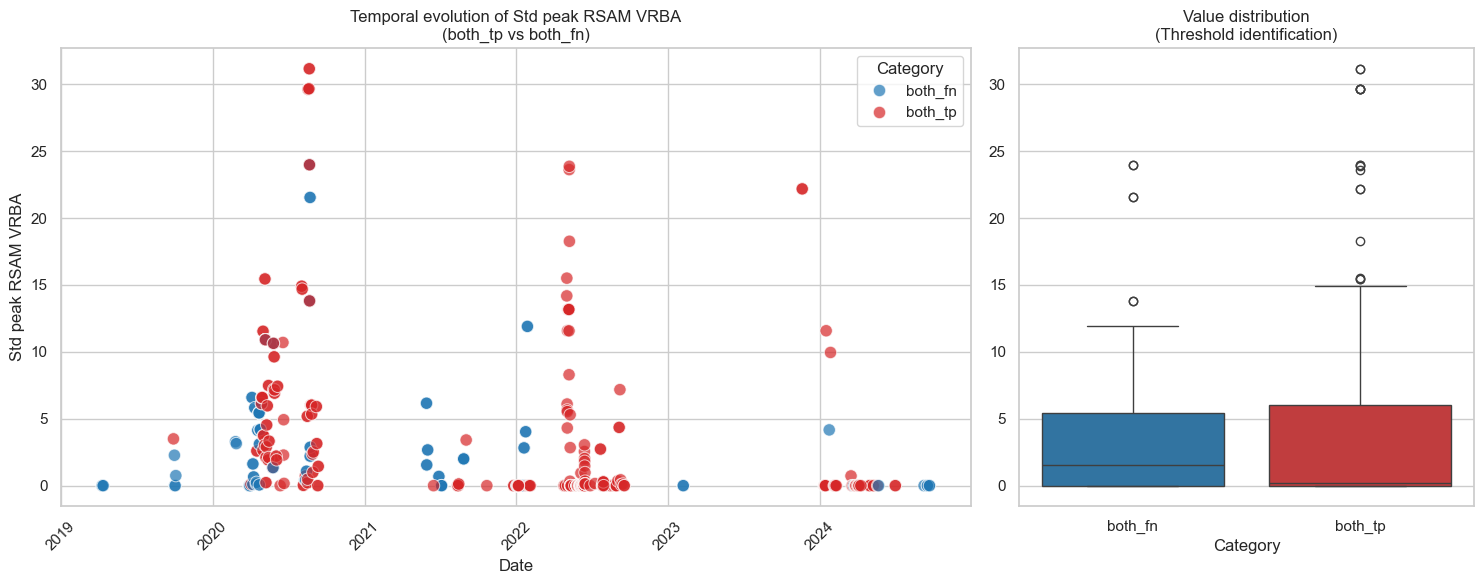

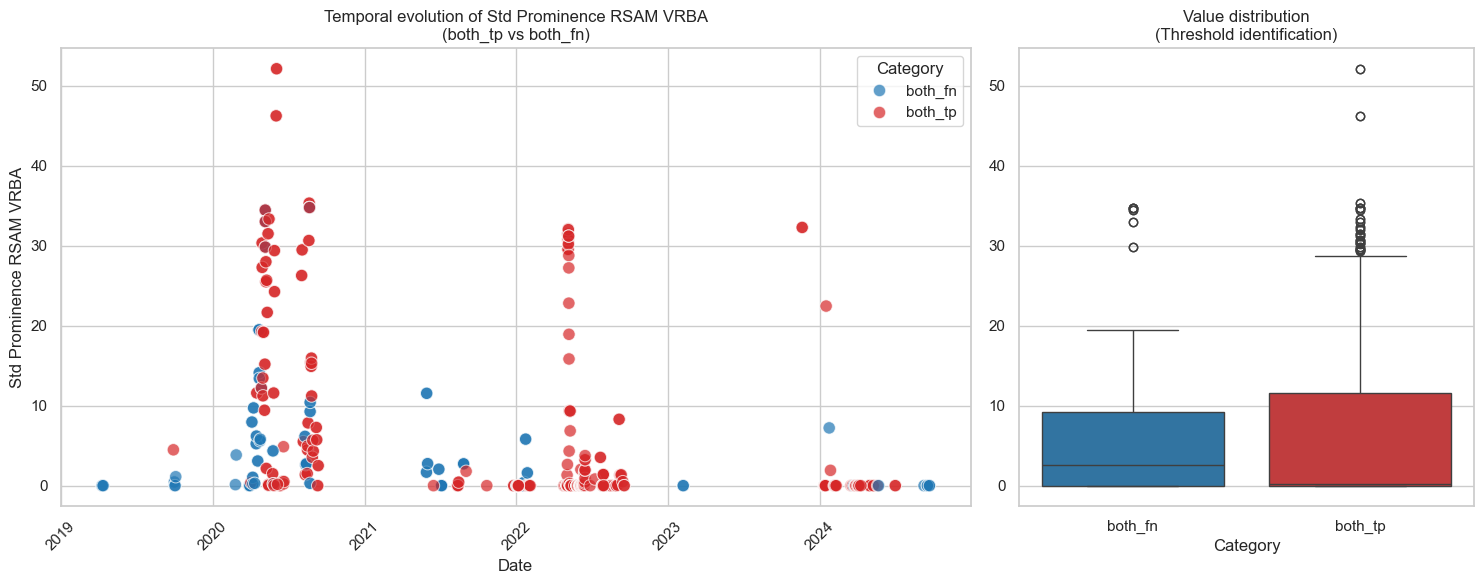

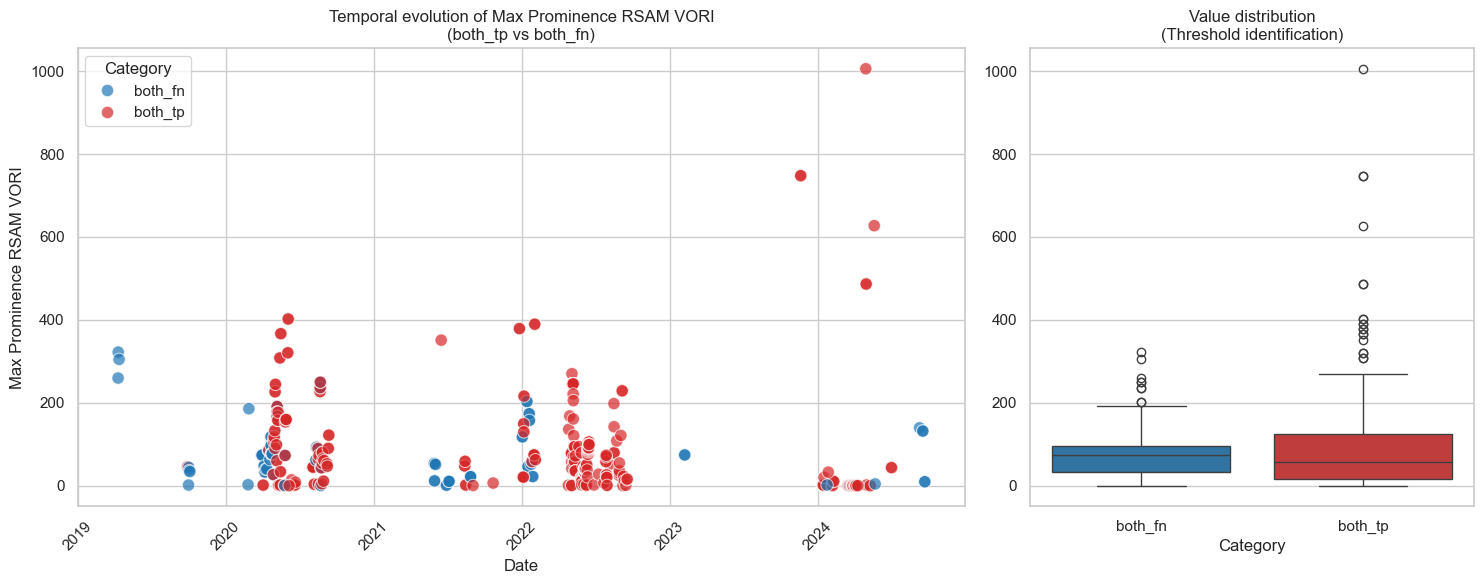

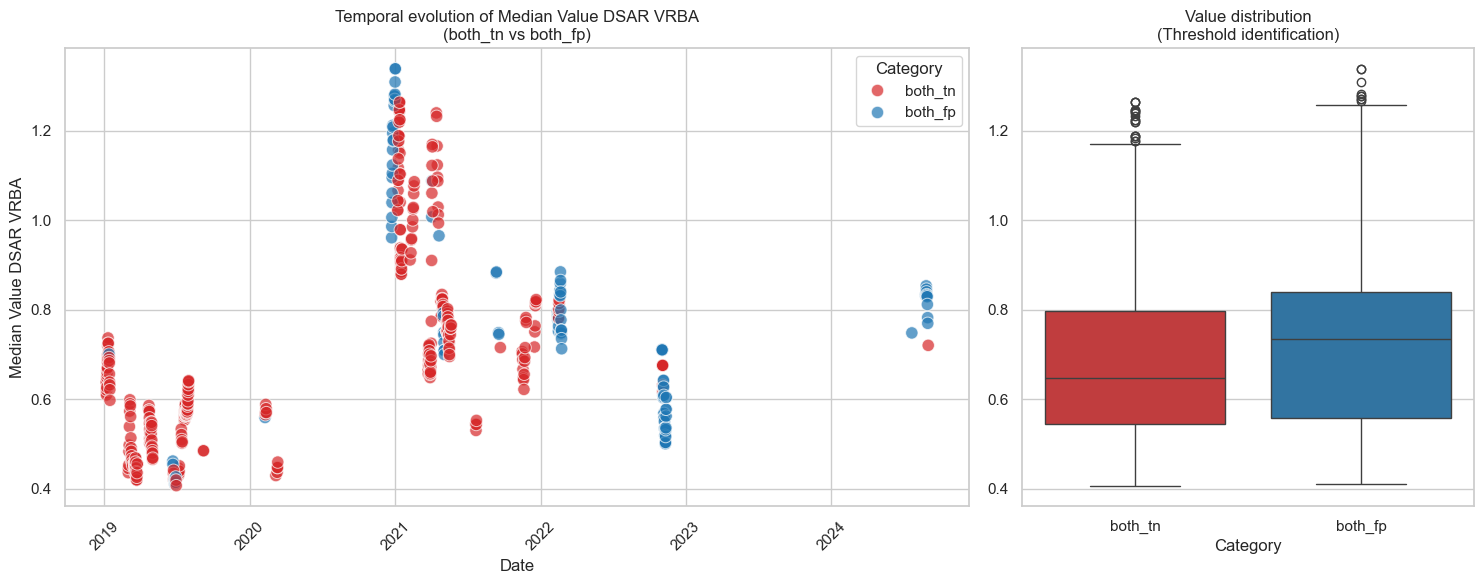

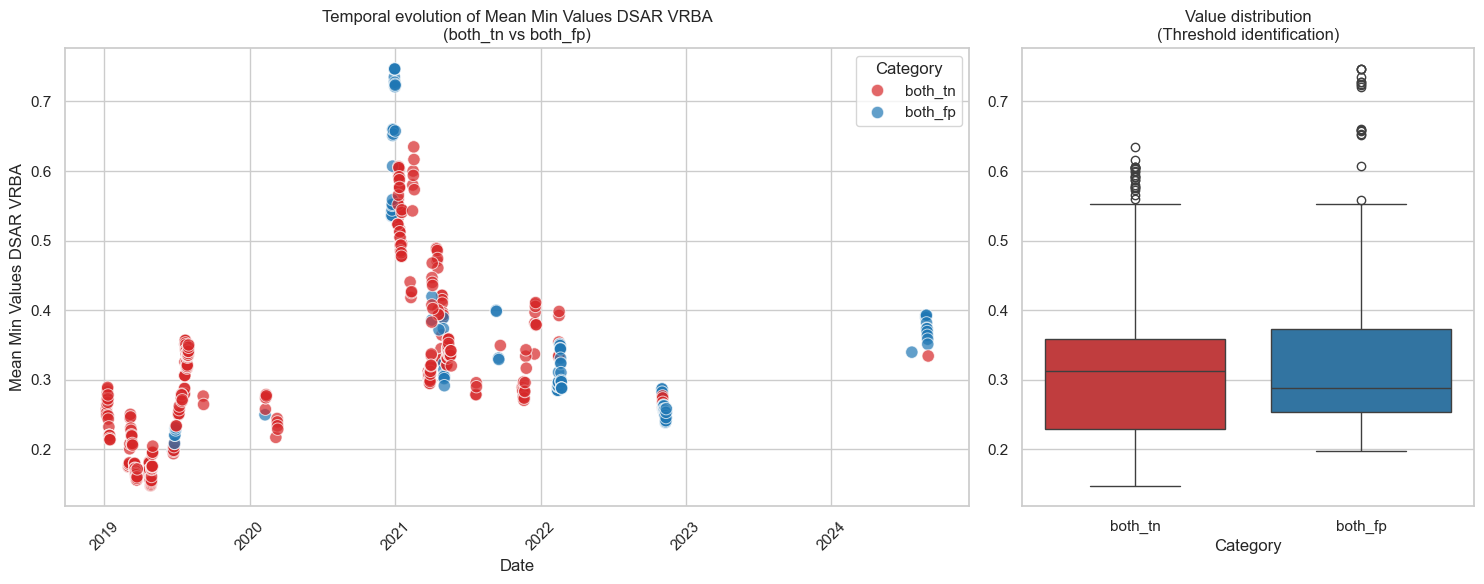

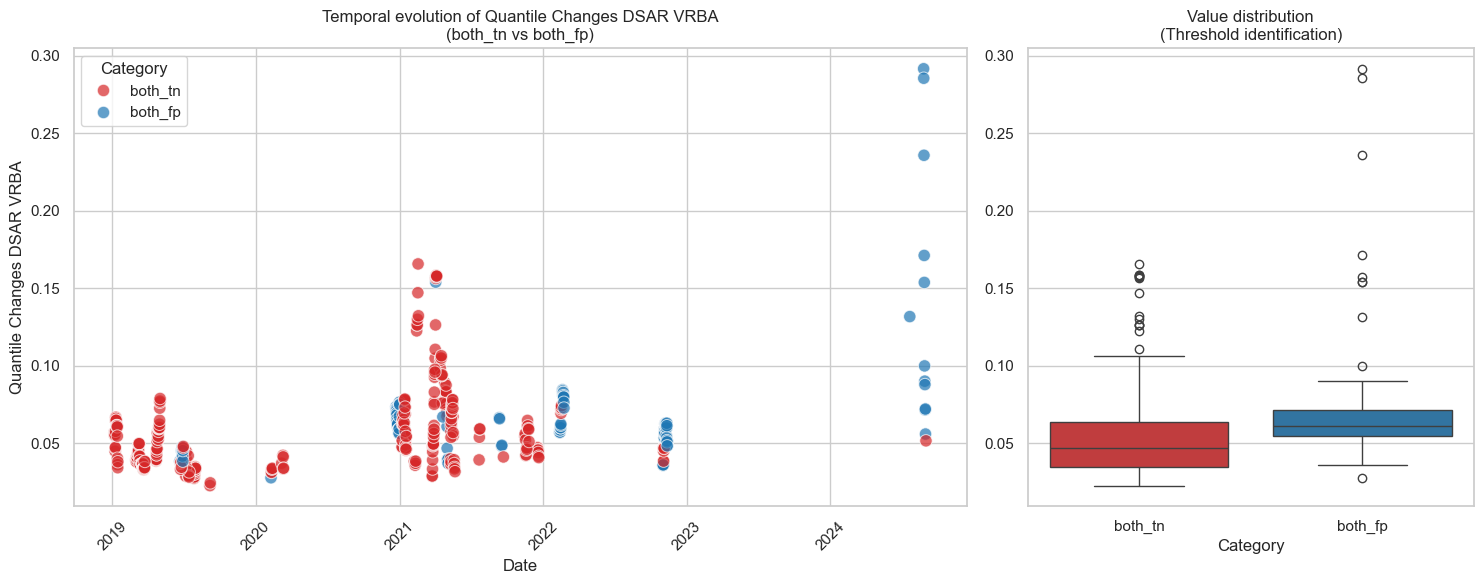

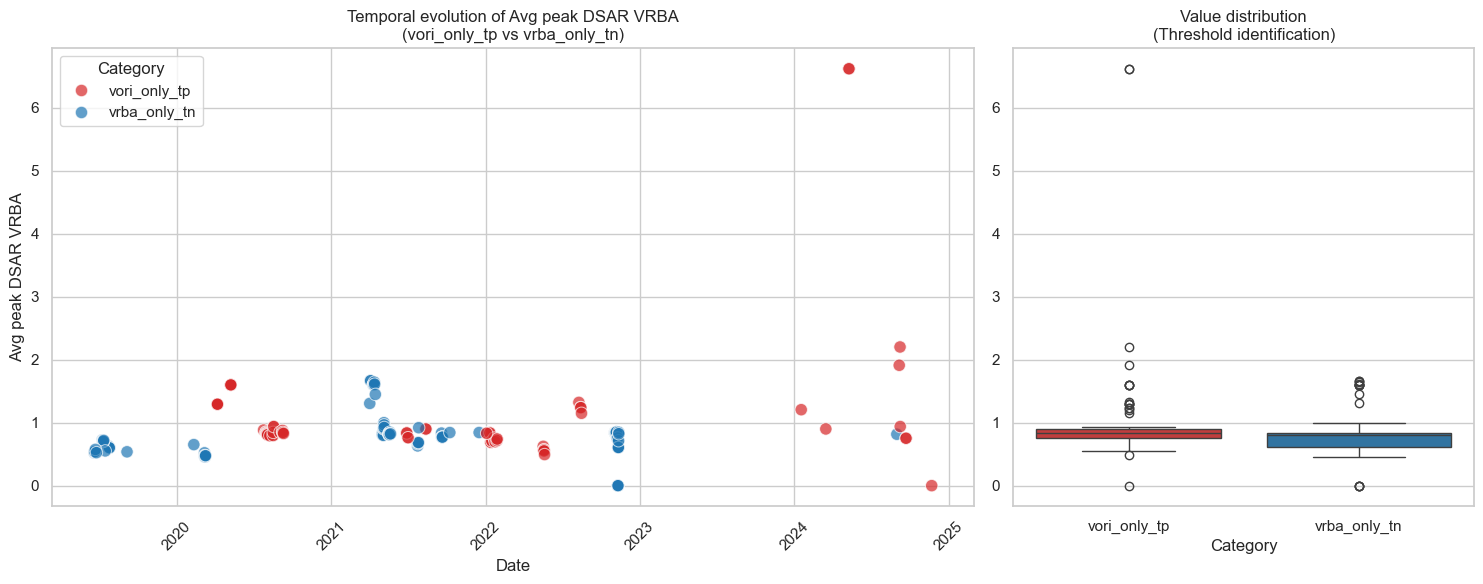

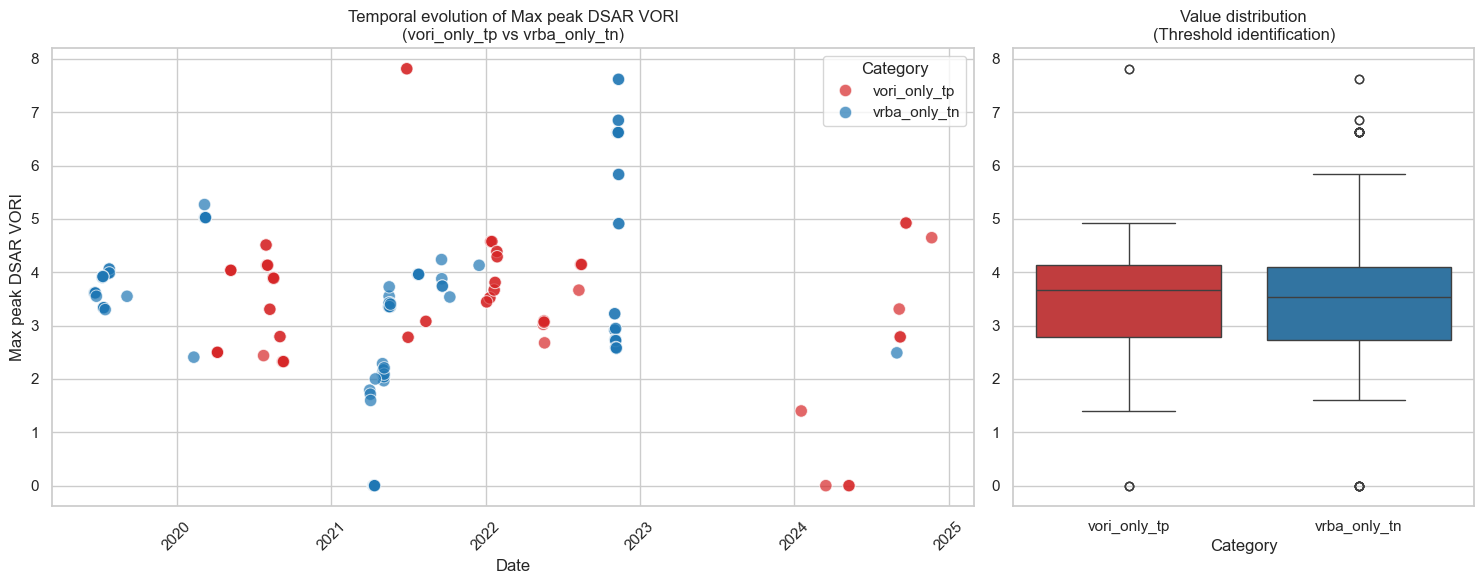

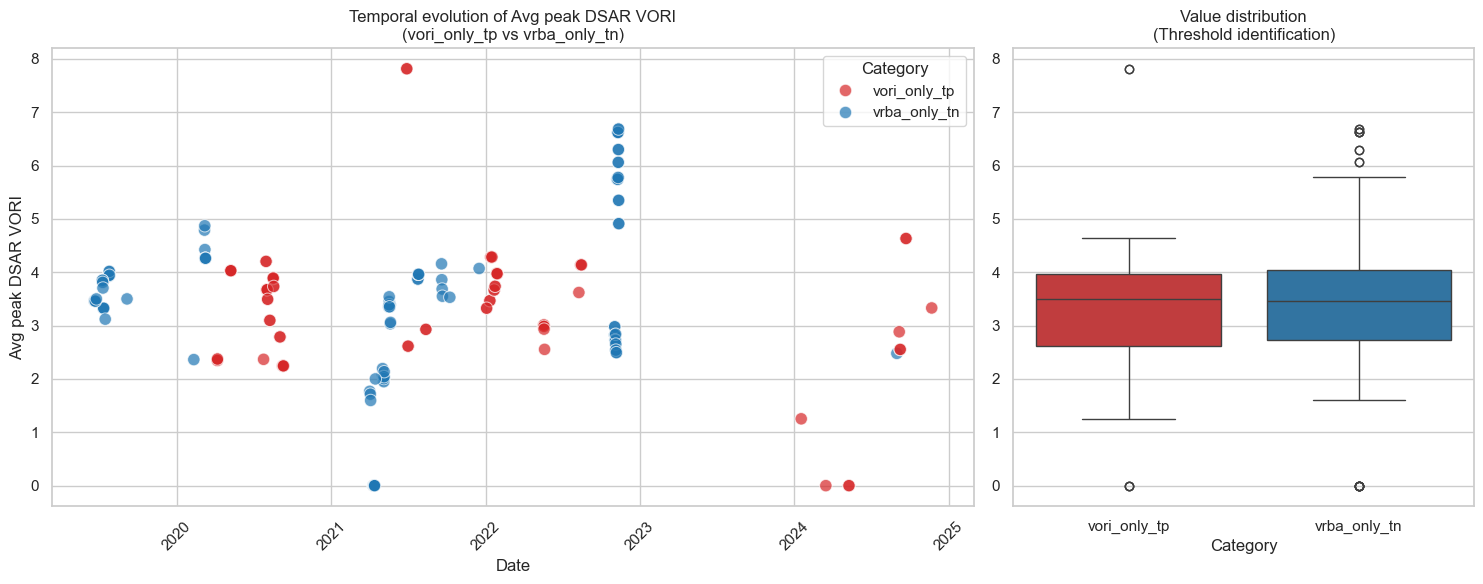

In [ ]:
def plot_top_features_per_cases(summary_df, p_results, target_classes, x_val_VORI, x_val_VRBA, time_val, top_n=3):
    
    # Set visual style for the thesis plots
    sns.set_theme(style="whitegrid")
    
    for target in target_classes:
        category_1, category_2 = target[0], target[1]
        test_name = f"{category_1}_vs_{category_2}"
        
        # Check if the comparison test exists in the statistical results
        if test_name not in p_results:
            raise ValueError(f"Statistical test results for {test_name} not found in p_results.")
            
   
        relevant_features = p_results[test_name].head(top_n).index.to_list()
  
        # Consolidate all validation data into a single DataFrame to facilitate plotting
        all_data = []
        for validation_set in x_val_VORI.keys():
            
            # Extract dates for the current validation set
            dates = time_val[validation_set]

            # Combine VRBA and VORI to have all available columns in one place
            df_combined = pd.concat([x_val_VORI[validation_set], x_val_VRBA[validation_set]], axis=1)

            df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

            df_combined['Date'] = dates
            
            # Keep only the date and the specific relevant features to save memory
            cols_to_keep = ['Date'] + [f for f in relevant_features if f in df_combined.columns]
            df_combined = df_combined[cols_to_keep]
            all_data.append(df_combined)
            
        # Create the global dataset by combining all validation sets
        full_val_df = pd.concat(all_data, ignore_index=True)

        # FIX: Ensure both 'Date' columns are proper datetime64[ns] objects before merging
        full_val_df['Date'] = pd.to_datetime(full_val_df['Date'])
        
        # Isolate the summary dates and safely convert them to avoid SettingWithCopyWarning
        summary_dates = summary_df[['Date', 'Category']].copy()
        summary_dates['Date'] = pd.to_datetime(summary_dates['Date'])
        
        # Merge safely now that both columns share the exact same datatype
        plot_df = pd.merge(full_val_df, summary_dates, on='Date', how='inner')
        
        # Filter the dataset to keep only the two categories currently being compared
        plot_df = plot_df[plot_df['Category'].isin([category_1, category_2])]

        # Generate plots for each relevant feature
        for feature in relevant_features:
            if feature not in plot_df.columns:
                continue
                
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
            
            # Time series scatter plot to visualize chronological distribution
            sns.scatterplot(
                data=plot_df, x='Date', y=feature, hue='Category', 
                palette={category_1: '#d62728', category_2: '#1f77b4'}, 
                s=80, alpha=0.7, ax=ax1
            )
            ax1.set_title(f"Temporal evolution of {feature}\n({category_1} vs {category_2})")
            ax1.tick_params(axis='x', rotation=45)
            
            # Boxplot to identify potential physical thresholds between classes
            sns.boxplot(
                data=plot_df, x='Category', y=feature, hue='Category',
                palette={category_1: '#d62728', category_2: '#1f77b4'},
                ax=ax2, legend=False
            )
            ax2.set_title(f"Value distribution\n(Threshold identification)")
            ax2.set_ylabel("") # Hide the Y-axis label for a cleaner look
            
            plt.tight_layout()
            plt.savefig(f"MSc_Bryan_Rincon/Plot P values/{feature}_{category_1}_vs_{category_2}.png")
            plt.show()

plot_top_features_per_cases(df_grouped_features, p_results, target_classes, x_val_5_VORI, x_val_5_VRBA, time_5days_val, top_n=3)

1. Systemic Detection vs. Systemic Failure (both_tp vs both_fn)

The statistical comparison between eruptions correctly identified by both stations and those completely missed highlights the fundamental baseline required for successful detection. The most highly discriminating features are overwhelmingly linked to the continuous seismic and acoustic energy at the VRBA station, specifically Median Value RSAM VRBA (p = 6.14e-21) and Std Value DSAR VRBA. This indicates that systemic detection relies heavily on a clear, macroscopic elevation in background noise. If VRBA does not register a deviation in its median or average energy levels, the entire monitoring network is likely to miss the event.

Furthermore, pre-eruptive physical precursors are statistically validated by the strong relevance of Max drop RSAM VRBA, suggesting that a sudden decrease in seismic energy prior to an event is a critical signature learned by the models. While VRBA dominates the top indicators, the VORI station provides essential complementary data. The high significance of Std Value RSAM VORI and Var Value RSAM VORI demonstrates that global behavioral shifts (variance and standard deviation) at the VORI site are critical secondary indicators of an impending eruption. Finally, the presence of Sum_Precipitations among the top five features underscores that external environmental factors strongly modulate the signal, and models must account for weather data to accurately classify true positive events.

2. True Quiescence vs. Systemic False Alarms (both_tn vs both_fp)

Analyzing the conditions under which both stations agree to launch a false alarm reveals critical vulnerabilities in the monitoring network, primarily driven by environmental noise. When the network correctly identifies a period of quiescence versus when it falsely flags an eruption, Sum_Precipitations acts as a massive confounding variable (p = 1.56e-15). This provides clear evidence that heavy rainfall likely increases the seismic background noise, imitating the geophysical signatures (such as tremor or lahar initiation) that the models associate with an eruption.

This environmental interference causes a ripple effect across the models' assumptions. During systemic false alarms, we observe significant anomalous shifts in the core metrics of both stations, notably Median Value DSAR VRBA (the most significant feature overall) and Var Value RSAM VORI. Essentially, external noise induces a significant change in signal intensity and variance during a period of true quiescence. The models detect these sudden shifts—including variations in the higher quantiles (Quantile Changes DSAR VRBA) which should theoretically remain stable during quiescence—and are deceived into misclassifying the weather-induced noise as a volcanic event.

3. Arbitrating VORI's Isolated Alerts (vori_only_tp vs vrba_only_tn)
Evaluating isolated alerts from the VORI station reveals how the monitoring network distinguishes a true localized precursor from a localized false alarm. When VORI correctly flags an eruption while VRBA predicts quiescence, the discrimination is heavily driven by transient signal peaks and discrete seismic events rather than continuous energy shifts.

Interestingly, the most statistically significant confirming feature is Max peak DSAR VRBA (p = 5.00e-6). This demonstrates a powerful cross-validation mechanism: even when the VRBA model fails to classify the overall window as an eruption, a localized acoustic peak at the VRBA station physically validates VORI's alert. Furthermore, this scenario is uniquely characterized by the appearance of distinct geological fractures and fluid movements. The sums of Volcano-Tectonic earthquakes (Sum_VT, p = 3.10e-5) and tornillo events (Sum_tornillo, p = 1.12e-4) act as critical geophysical confirmations. If VORI triggers an isolated alert without the presence of these specific discrete seismic events or corresponding acoustic peaks at VRBA, the alert is highly likely to be a false positive.

4. Arbitrating VRBA's Isolated Alerts (vrba_only_tp vs vori_only_tn)
Conversely, when the VRBA station triggers an isolated alert, the arbitration logic shifts from transient peaks to sustained energy baselines and environmental vetoes. The most critical indicators validating a VRBA-only true positive are the continuous energy metrics at the station itself, specifically Avg Value RSAM VRBA (p = 5.17e-10) and Avg drop RSAM VRBA (p = 4.37e-09). A legitimate isolated alert from VRBA requires a fundamental, sustained deviation in its seismic background noise compared to normal quiescence.

However, validating this alert requires analyzing the secondary station and external environmental factors to rule out false positives. The network relies on VORI's signal variance (Std Value RSAM VORI, p = 5.71e-08, and Var Value RSAM VORI) as a secondary confirmation; even if VORI does not detect the eruption outright, its background signal must show heightened agitation. Most importantly, Sum_Precipitations emerges again as a highly significant discriminatory feature (p = 7.20e-06). This serves as a critical meteorological veto: if VRBA registers an isolated increase in RSAM energy during a period of heavy rainfall while VORI remains relatively stable, the meta-model can confidently classify the event as weather-induced noise rather than an impending eruption.

Lahars features analysis

Lets first look to all the lahars that have predicted through the models

In [ ]:
# All the lahares date
Lahares_df['Eruption time']

7    2019-01-20 07:27:00
8    2020-01-30 18:13:00
9    2020-05-25 09:25:00
10   2021-06-28 11:42:00
11   2022-06-01 00:33:00
12   2022-01-23 08:24:00
13   2022-01-30 19:08:00
14   2023-04-14 15:35:00
15   2023-04-21 21:50:00
16   2023-11-05 21:17:00
17   2023-05-14 08:58:00
18   2023-05-25 20:35:00
19   2023-05-28 03:34:00
20   2023-05-29 08:44:00
21   2023-02-06 15:05:00
Name: Eruption time, dtype: datetime64[ns]

In [ ]:
lahares_dates = Lahares_df['Eruption time']

lahares_summary = df_counts[df_counts.index.floor('min').isin(pd.to_datetime(lahares_dates))].copy()

print(lahares_summary)

Category                 both_fn  both_fp  both_tn  both_tp  vori_only_tn  \
Date                                                                        
2020-05-25 09:25:52.157        1        0        0        0             0   
2021-06-28 11:42:04.132        1        0        0        0             0   
2022-01-23 08:24:45.682        1        0        0        0             0   
2022-01-30 19:08:00.000        0        0        0        2             0   
2022-06-01 00:33:00.000        0        0        0        1             0   
2023-02-06 15:05:00.000        2        0        0        0             0   

Category                 vori_only_tp  vrba_only_tn  vrba_only_tp  Total_Votes  
Date                                                                            
2020-05-25 09:25:52.157             0             0             1            2  
2021-06-28 11:42:04.132             1             0             0            2  
2022-01-23 08:24:45.682             1             0        

In [ ]:
lahares_summary_cat = lahares_summary.drop(columns=['Total_Votes']).copy()
lahares_category_columns = lahares_summary_cat.columns[lahares_summary_cat.sum() > 0].tolist()
del(lahares_summary_cat)
print(lahares_category_columns)

['both_fn', 'both_tp', 'vori_only_tp', 'vrba_only_tp']


In [ ]:
# Initialize an empty list to store the temporary dataframes
liste_dfs = []

for cat in lahares_category_columns:
    # Extract the relevant dates for the current category
    cat_dates = lahares_summary[lahares_summary[cat] > 0].index.tolist()
    
    # Filter the features dataframe based on the category and corresponding dates
    df_grouped_features_cat = df_grouped_features[
        (df_grouped_features['Category'] == cat) & 
        (df_grouped_features['Date'].isin(cat_dates))
    ].copy()
    
    # Append the filtered dataframe to the list
    liste_dfs.append(df_grouped_features_cat)

# Concatenate all collected dataframes into a single dataframe
# Using ignore_index=True to ensure a clean, continuous index
df_lahares_final = pd.concat(liste_dfs, ignore_index=True)
df_lahares_final.to_csv('MSc_Bryan_Rincon/Truth_table/lahares_summary_features.csv', index=False)
# Output the final combined dataframe
print(df_lahares_final)

                     Date      Category   Model_Years  Model_Count  \
0 2020-05-25 09:25:52.157       both_fn        [2019]            1   
1 2021-06-28 11:42:04.132       both_fn        [2020]            1   
2 2022-01-23 08:24:45.682       both_fn        [2023]            1   
3 2023-02-06 15:05:00.000       both_fn  [2020, 2022]            2   
4 2022-01-30 19:08:00.000       both_tp  [2020, 2023]            2   
5 2022-06-01 00:33:00.000       both_tp        [2021]            1   
6 2021-06-28 11:42:04.132  vori_only_tp        [2023]            1   
7 2022-01-23 08:24:45.682  vori_only_tp        [2020]            1   
8 2020-05-25 09:25:52.157  vrba_only_tp        [2024]            1   

                                   Top_Features_VORI  \
0  [Sum_LP, Max_LP, Delta_Max_Min_LP, Max_tornill...   
1  [Sum_LP, Avg drop DSAR VORI, Max drop DSAR VOR...   
2  [Max_Precipitations, Sum_Precipitations, Delta...   
3  [Sum_LP, Mean Min Values DSAR VORI, Max drop D...   
4  [Sum_LP, Max_tor

In [ ]:
# df_lahares_final = pd.read_csv('MSc_Bryan_Rincon/Truth_table/lahares_summary_features.csv', index_col=0, parse_dates=True)
# If '#' taken dont forget to parse

lahares_cat_dict = {}
for cat in lahares_category_columns:
    lahares_cat_dict[cat] = df_lahares_final[df_lahares_final['Category'] == cat].copy()
    print(f"Category: {cat}, Number of records: {len(lahares_cat_dict[cat])}")

Category: both_fn, Number of records: 4
Category: both_tp, Number of records: 2
Category: vori_only_tp, Number of records: 2
Category: vrba_only_tp, Number of records: 1


In [ ]:
# Both fn 

for num in range(len(lahares_cat_dict['both_fn'])):
    print(f"Top Feature {num+1}:")
    print("Top Features VORI:", lahares_cat_dict['both_fn']['Dict_VORI'][num])
    print("Top Features VRBA:", lahares_cat_dict['both_fn']['Dict_VRBA'][num])
    print("-" * 50)

Top Feature 1:
Top Features VORI: {'Sum_LP': 0.15973018038864123, 'Max_LP': 0.09908778612134941, 'Delta_Max_Min_LP': 0.06491455533026143, 'Max_tornillo': 0.050676928056766025, 'Delta_Max_Min_tornillo': 0.04991686106401858, 'Mean Min Values DSAR VORI': 0.0403708183236907, 'Quantile Changes RSAM VORI': 0.03839420931347065, 'Last_LP': 0.03446748534959856, 'Mean Min Values RSAM VORI': 0.02901925669417178, 'Avg drop DSAR VORI': 0.02671518100848824, 'Max drop DSAR VORI': 0.026402620034402035, 'Median Value RSAM VORI': 0.025747481948914276, 'Sum_tornillo': 0.02549909024419377, 'Quantile Changes DSAR VORI': 0.024881344459492225, 'Median Value DSAR VORI': 0.02466992613244083, 'Max peak RSAM VORI': 0.022771767801316664, 'Std Value RSAM VORI': 0.022159921970947613, 'Sum_Precipitations': 0.02152260051721244, 'Var Value RSAM VORI': 0.021309023955730123, 'Avg Value RSAM VORI': 0.02089554662776057, 'Max_Precipitations': 0.020725230515080243, 'Max drop RSAM VORI': 0.020602526828375576, 'Max peak DSAR 

In [ ]:
# Classement features for each category
lahares_features_scores = {}

for cat in lahares_category_columns:
    # Initialize a Counter to accumulate feature scores
    combined_counter_VORI = Counter()
    combined_counter_VRBA = Counter()
    
    # Iterate through each record in the category
    for idx, row in lahares_cat_dict[cat].iterrows():
        combined_counter_VORI.update(row['Dict_VORI'])
        combined_counter_VRBA.update(row['Dict_VRBA'])
    
    # Store the combined feature scores specifically FOR THIS CATEGORY
    lahares_features_scores[cat] = {
        'VORI': dict(combined_counter_VORI),
        'VRBA': dict(combined_counter_VRBA)
    }

print("Top 10 Feature scores for each category for each station:") 
for cat in lahares_category_columns:
    print(f"\n--- Category: {cat} ---")
    
    # Access the scores using both the category and the station
    top_vori = dict(Counter(lahares_features_scores[cat]['VORI']).most_common(10))
    top_vrba = dict(Counter(lahares_features_scores[cat]['VRBA']).most_common(10))
    
    print("Top Features VORI:", top_vori)
    print("Top Features VRBA:", top_vrba)

Top 10 Feature scores for each category for each station:

--- Category: both_fn ---
Top Features VORI: {'Sum_LP': 0.47023509761815147, 'Max_LP': 0.28254845532752315, 'Mean Min Values DSAR VORI': 0.2692511321789548, 'Max drop DSAR VORI': 0.2268252119382962, 'Avg drop DSAR VORI': 0.22550010730407866, 'Delta_Max_Min_LP': 0.20574943024306436, 'Max_tornillo': 0.20053242491328413, 'Quantile Changes RSAM VORI': 0.19900672020810856, 'Median Value DSAR VORI': 0.1794554285008981, 'Delta_Max_Min_tornillo': 0.16555898756536258}
Top Features VRBA: {'Sum_LP': 0.7936387061979637, 'Quantile Changes RSAM VRBA': 0.6315544210174371, 'Median Value DSAR VRBA': 0.6228675657034868, 'Quantile Changes DSAR VRBA': 0.33401268358036795, 'Avg peak DSAR VRBA': 0.3026974992419497, 'Std Value DSAR VRBA': 0.299119482834614, 'Mean Min Values RSAM VRBA': 0.22672750176845183, 'Mean Min Values DSAR VRBA': 0.1869840456400696, 'Max_LP': 0.18355747619534535, 'Var Value DSAR VRBA': 0.17713394282249761}

--- Category: both_tp

In [ ]:
lahares_features_scores['both_tp']['VORI']

['Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Max_LP', 'Quantile Changes DSAR VRBA', 'Avg drop DSAR VORI', 'Max_Precipitations', 'Max drop DSAR VORI', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Max_tornillo', 'Median Value DSAR VRBA', 'Avg peak DSAR VRBA', 'Std Value DSAR VORI', 'Max peak DSAR VRBA', 'Delta_Max_Min_LP', 'Mean Min Values DSAR VORI', 'Sum_LP']


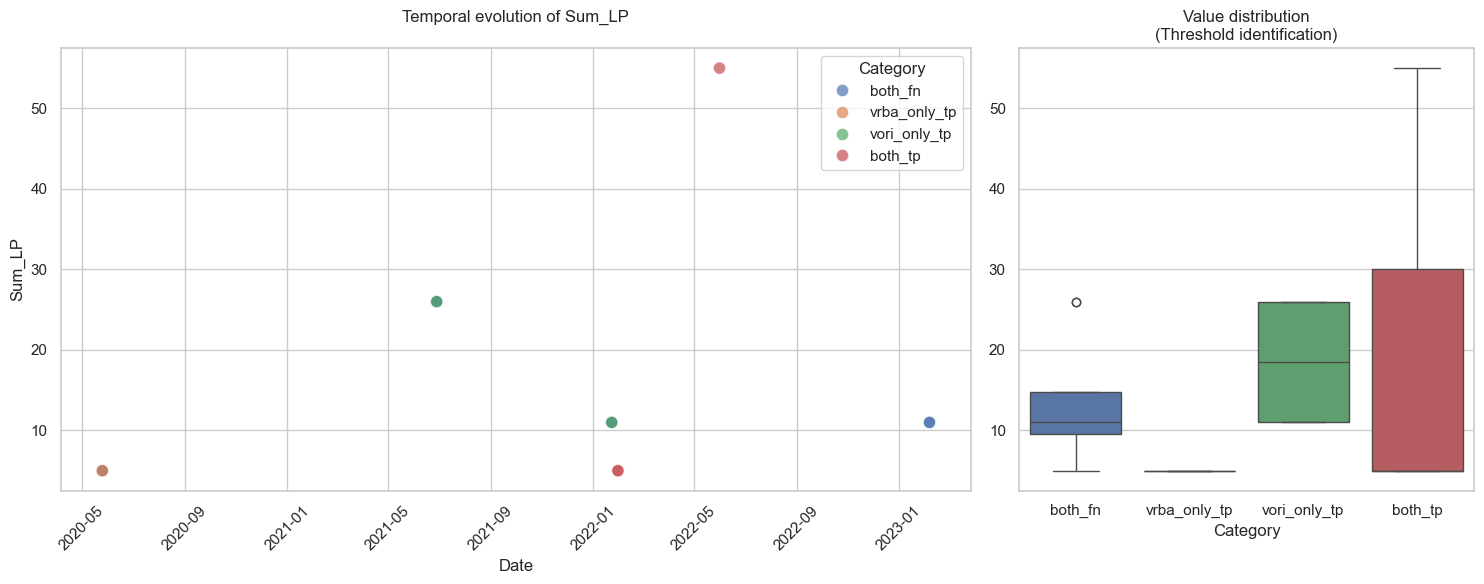

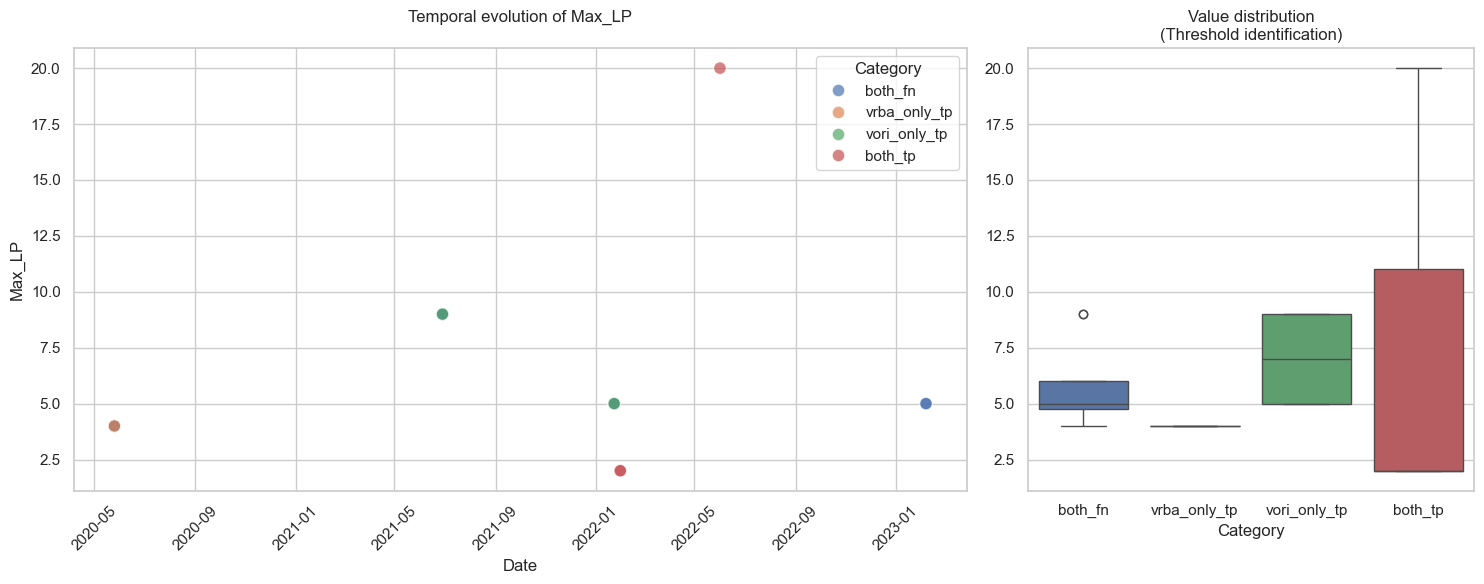

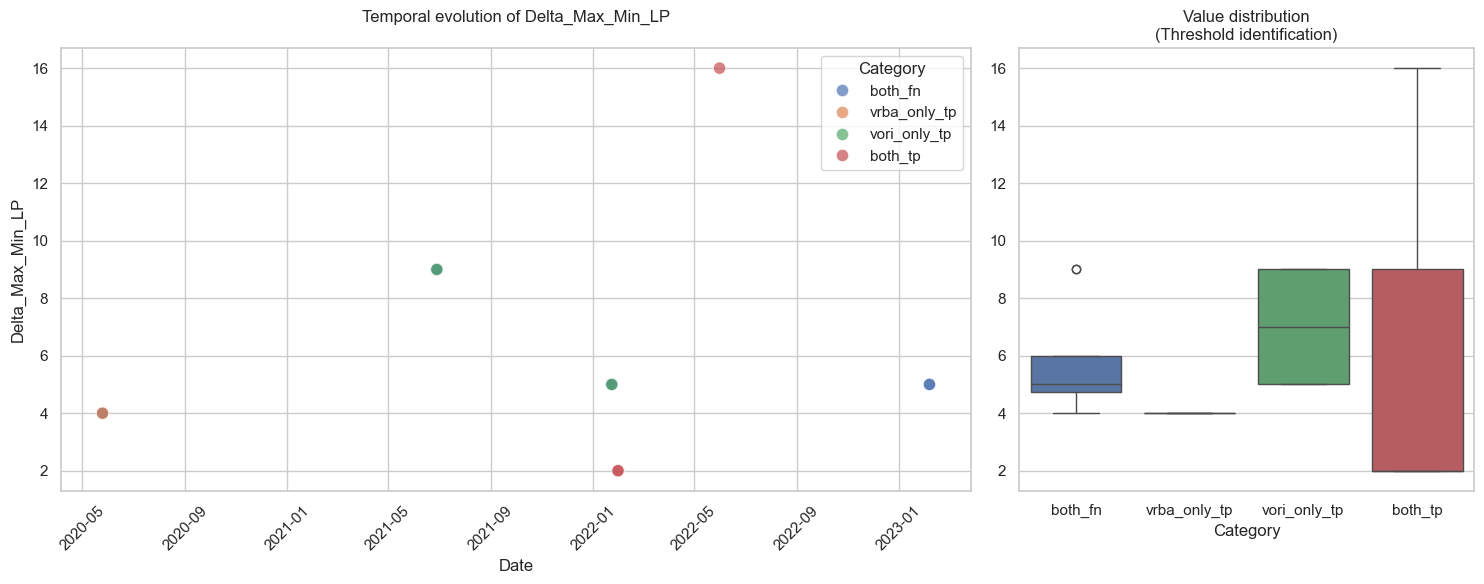

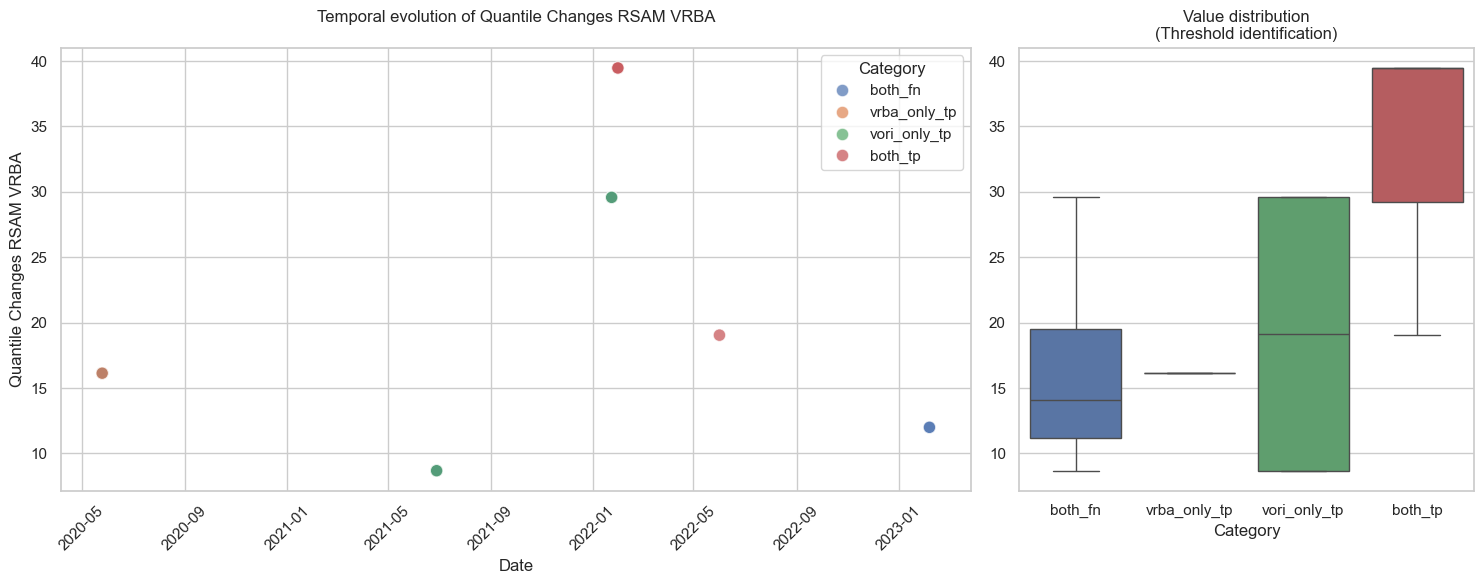

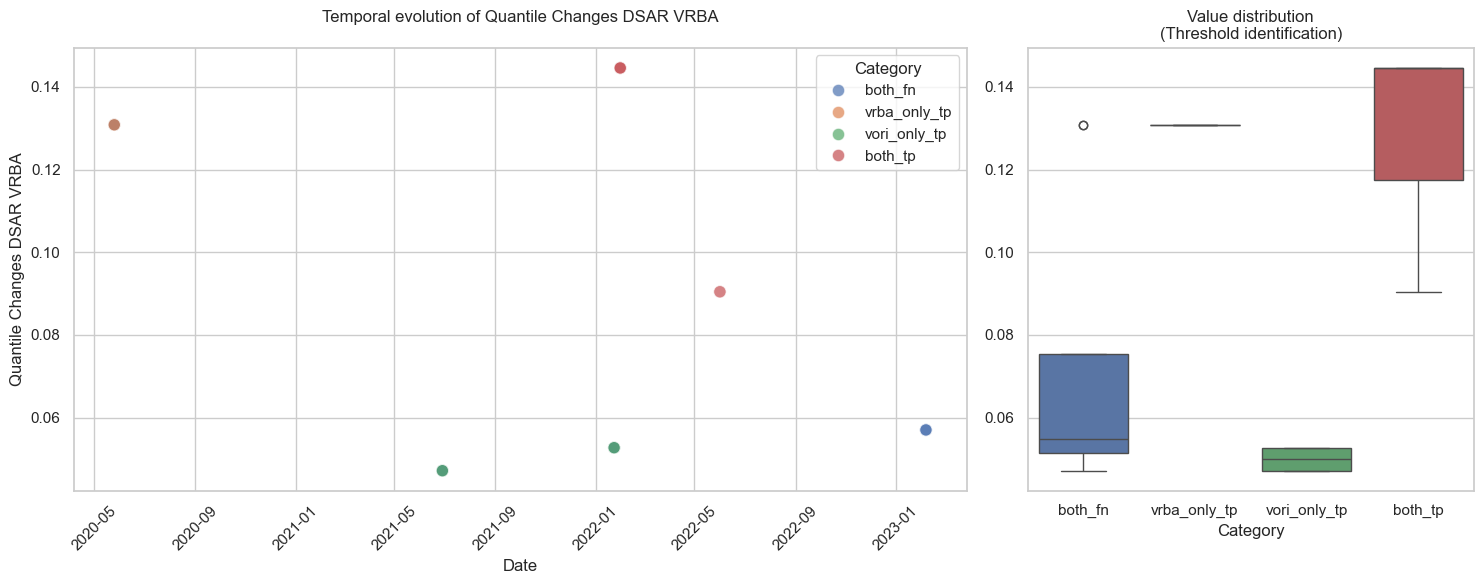

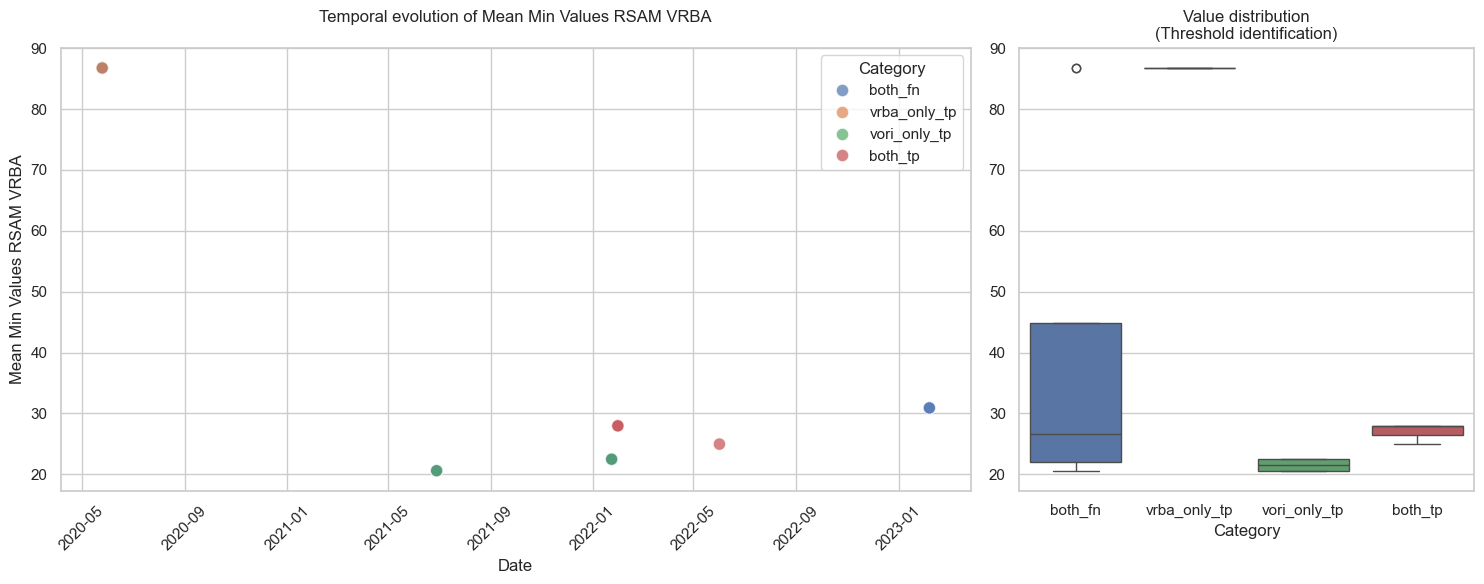

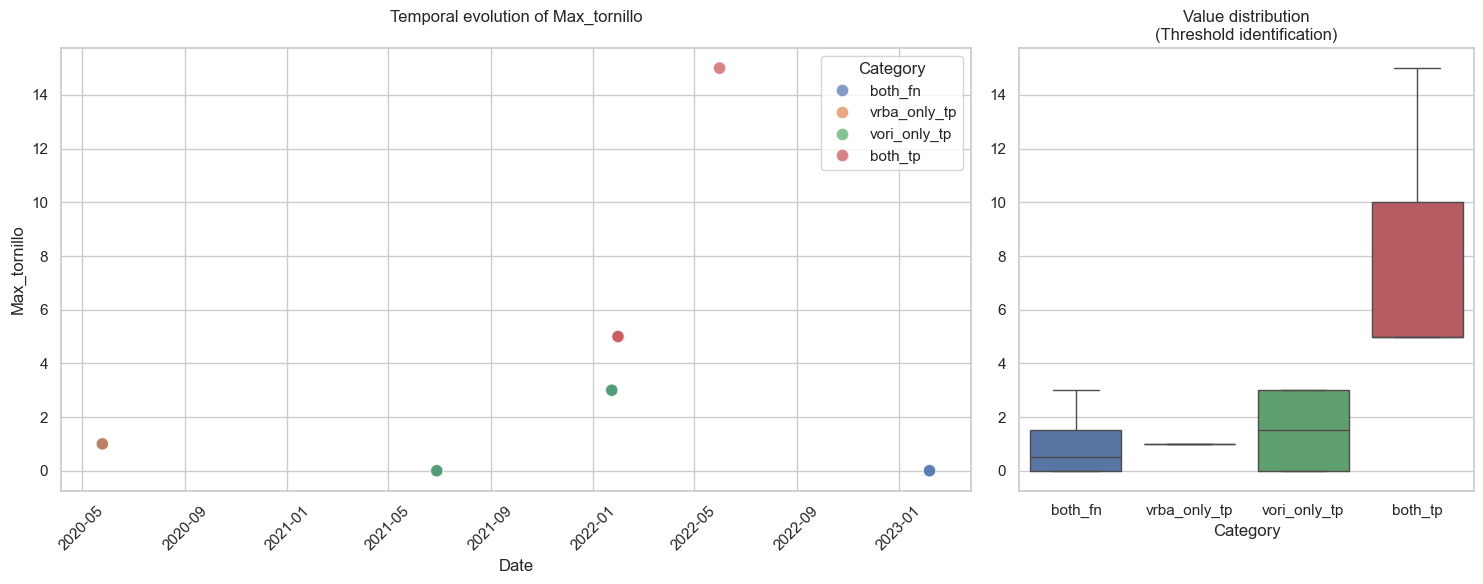

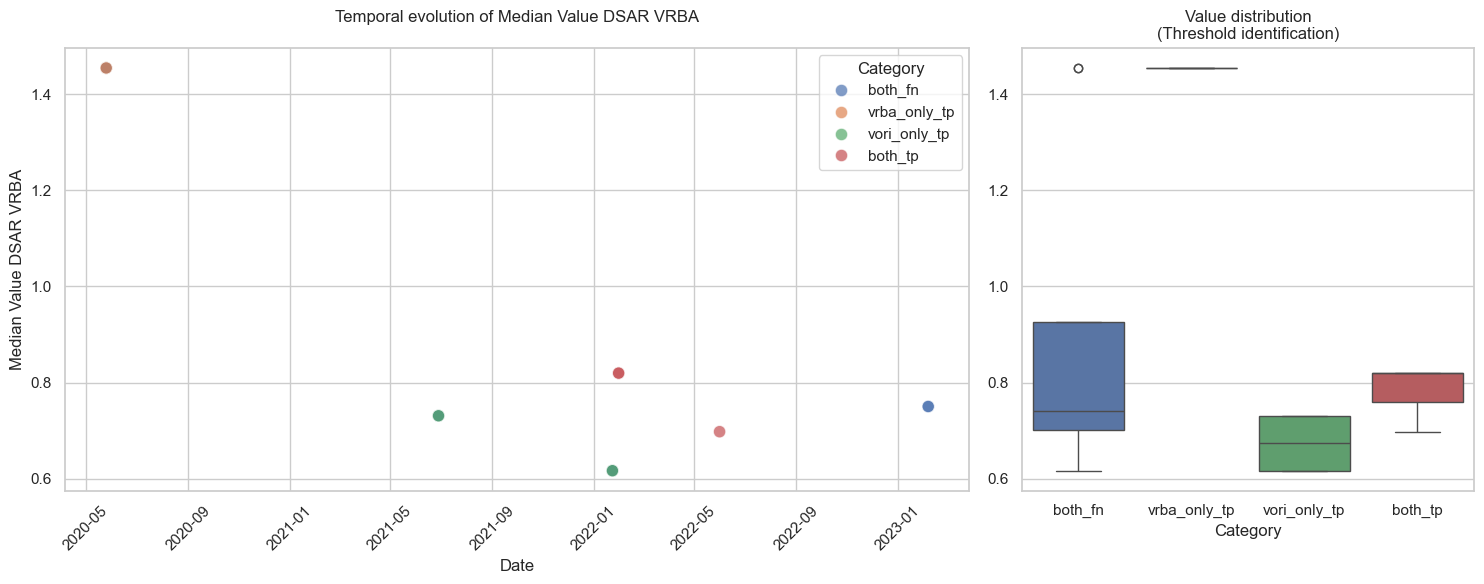

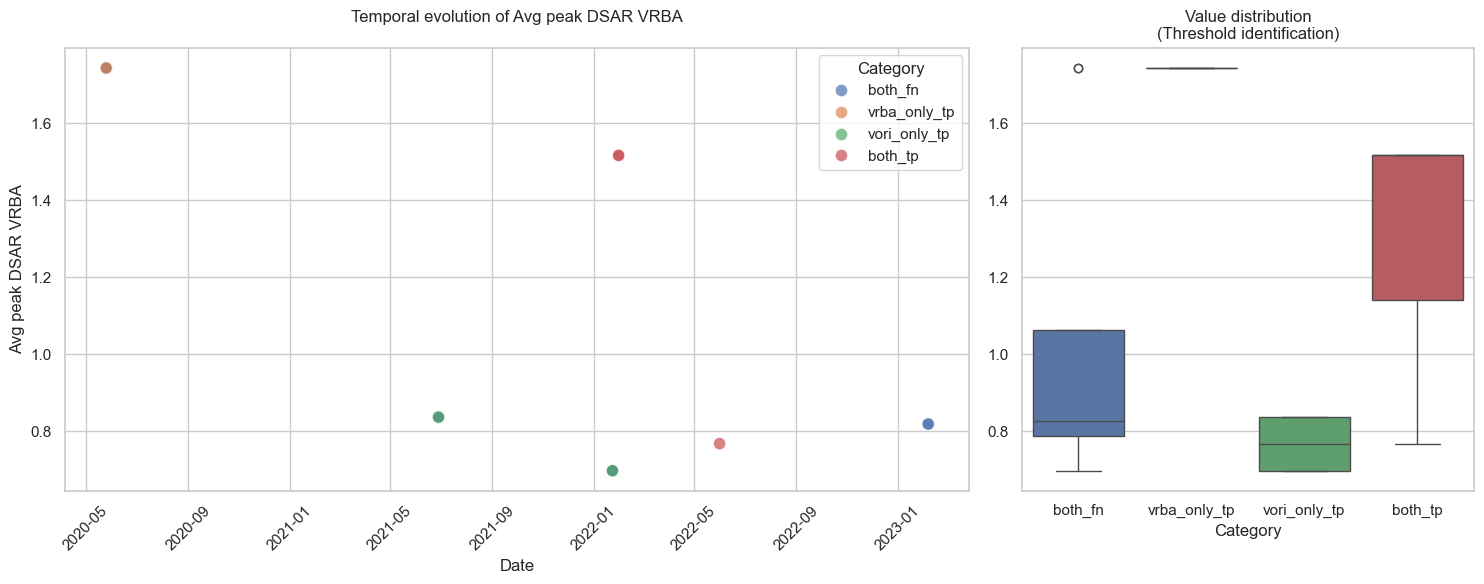

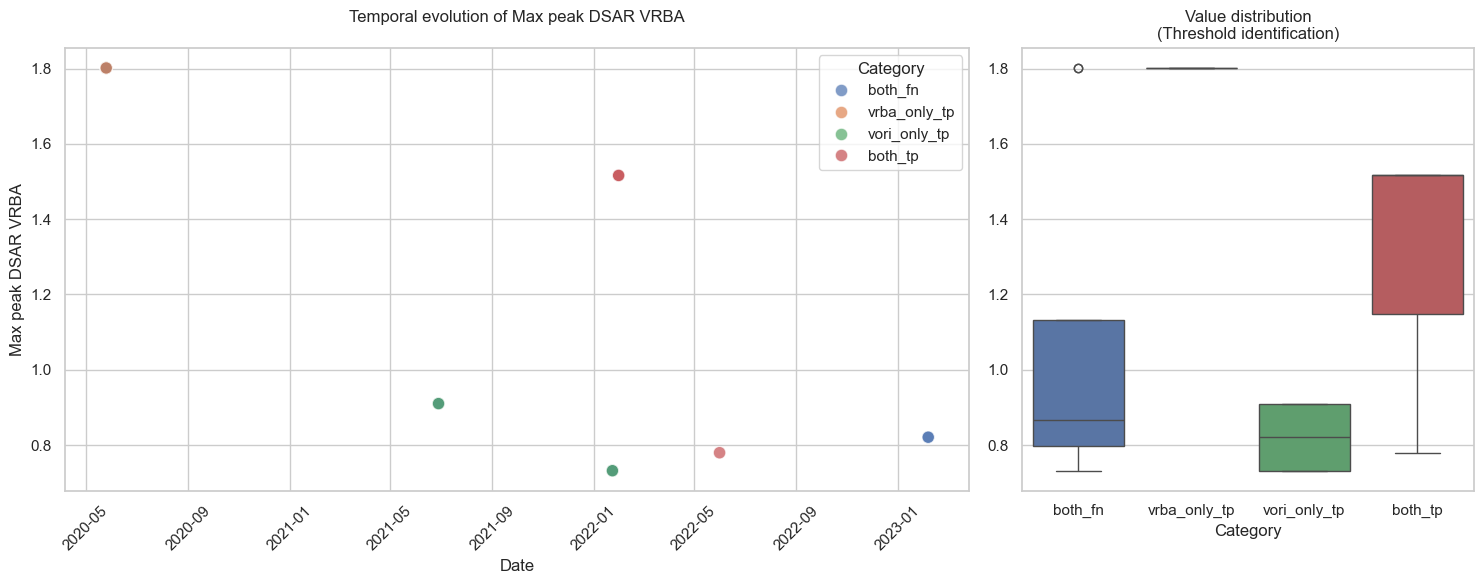

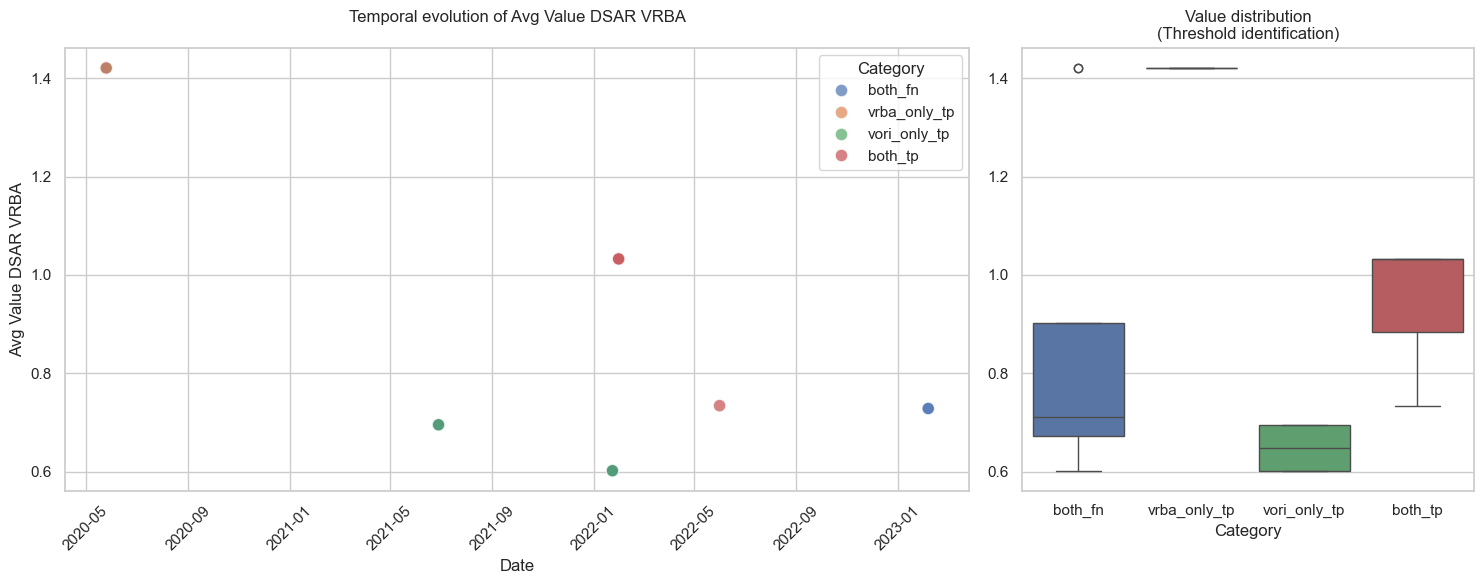

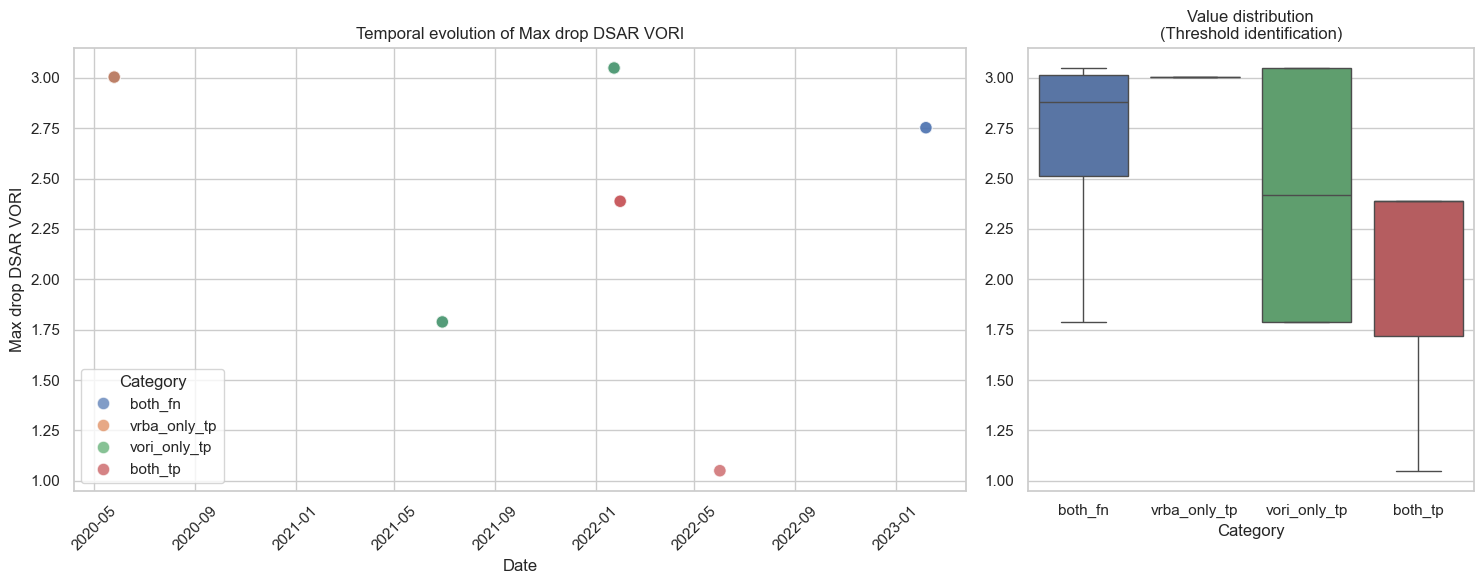

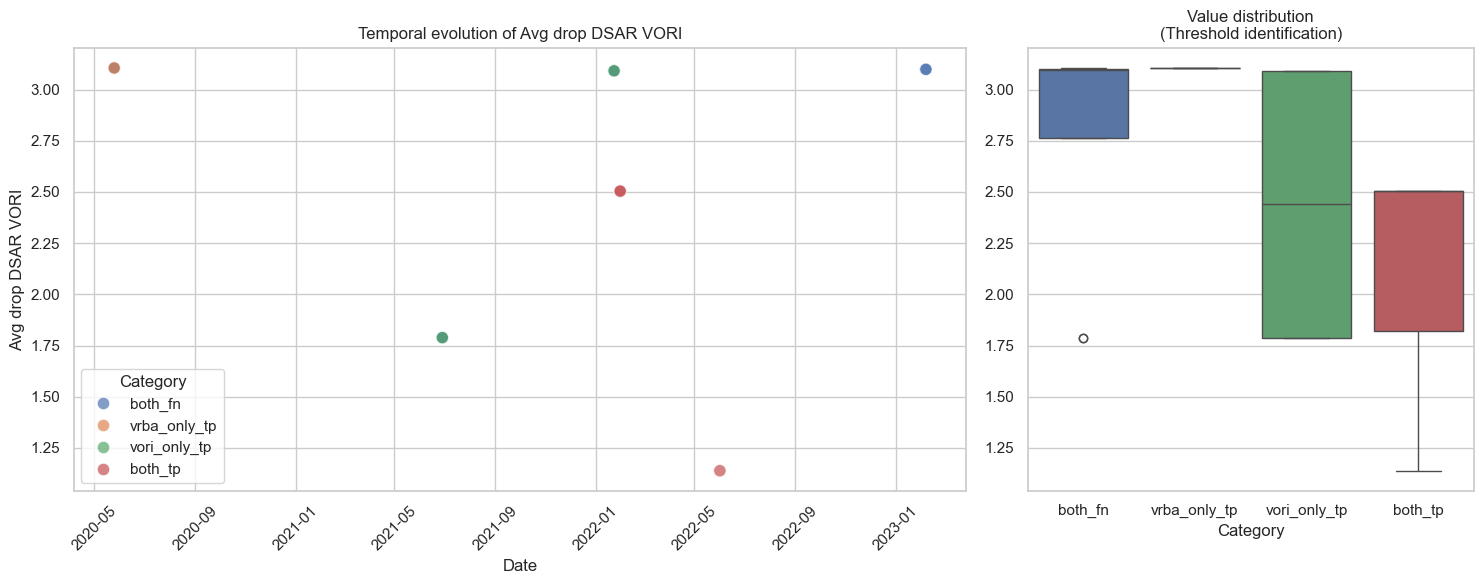

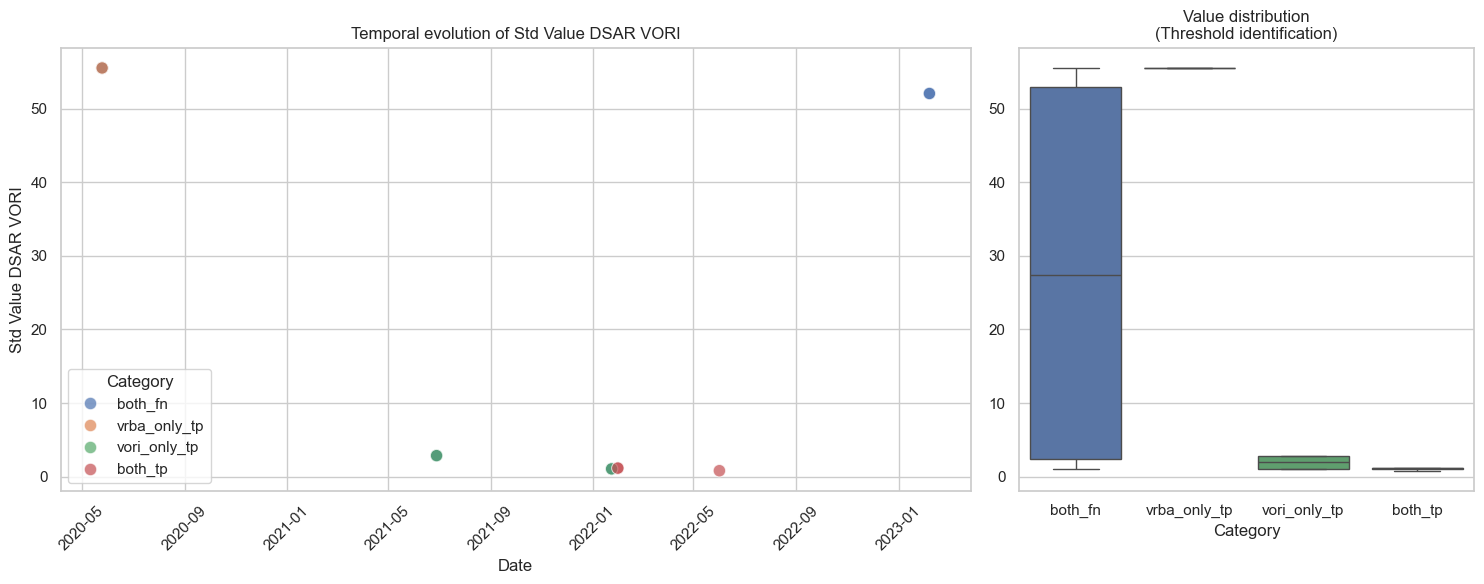

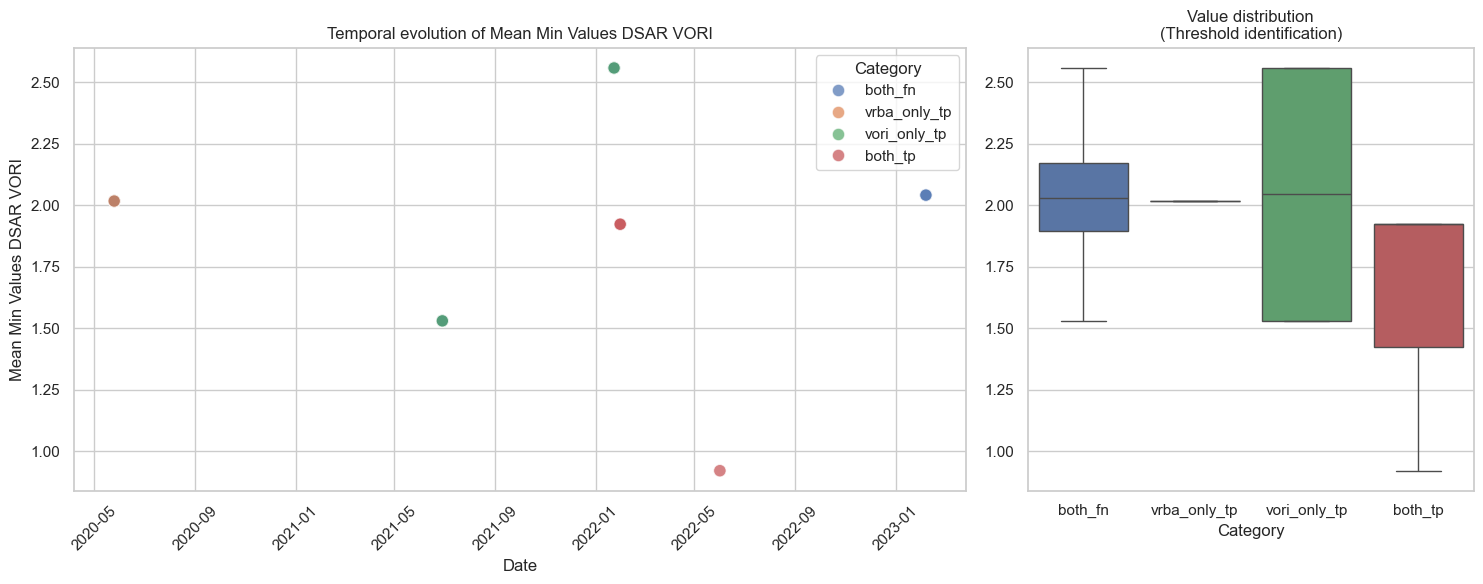

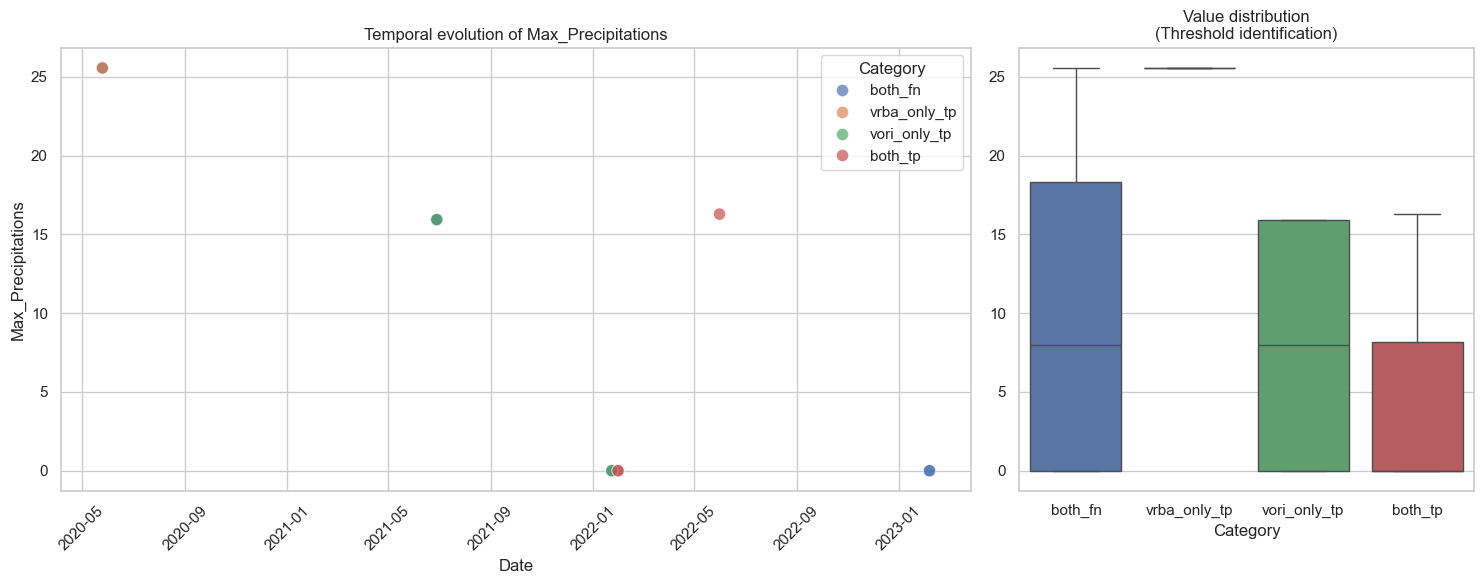

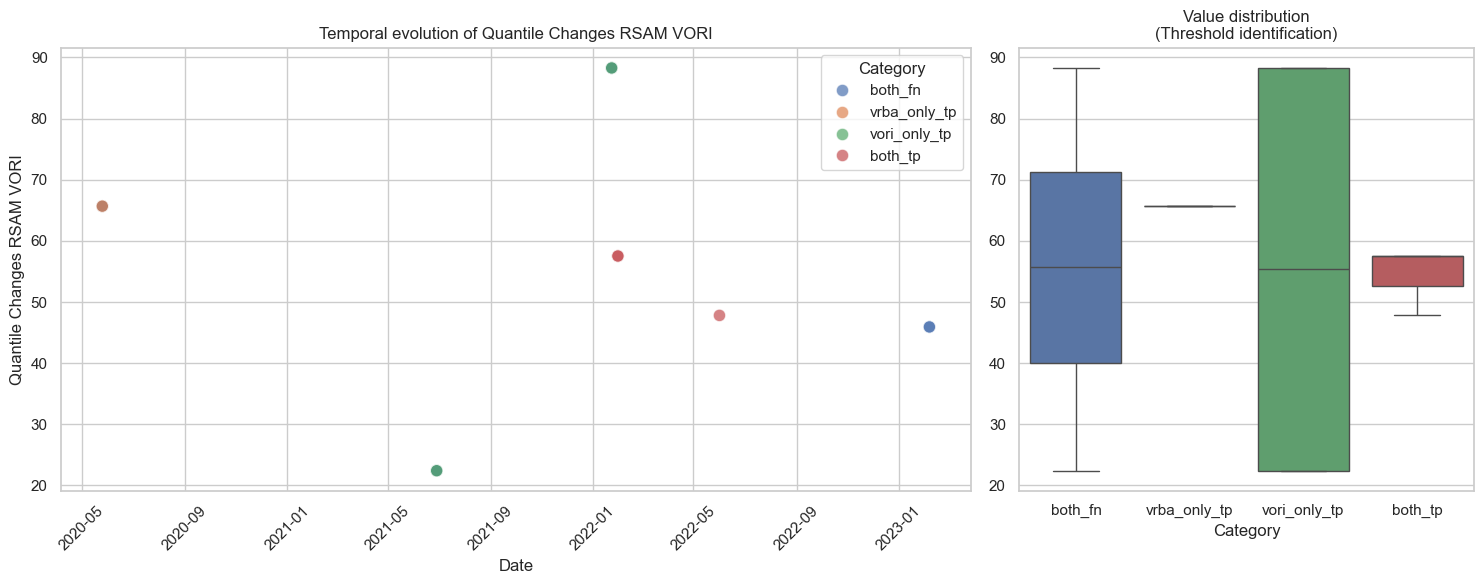

['Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Max_LP', 'Quantile Changes DSAR VRBA', 'Avg drop DSAR VORI', 'Max_Precipitations', 'Max drop DSAR VORI', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Max_tornillo', 'Median Value DSAR VRBA', 'Avg peak DSAR VRBA', 'Std Value DSAR VORI', 'Max peak DSAR VRBA', 'Delta_Max_Min_LP', 'Mean Min Values DSAR VORI', 'Sum_LP']
['Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Max_LP', 'Quantile Changes DSAR VRBA', 'Avg drop DSAR VORI', 'Max_Precipitations', 'Max drop DSAR VORI', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Max_tornillo', 'Median Value DSAR VRBA', 'Avg peak DSAR VRBA', 'Std Value DSAR VORI', 'Max peak DSAR VRBA', 'Delta_Max_Min_LP', 'Mean Min Values DSAR VORI', 'Sum_LP']
['Avg Value DSAR VRBA', 'Quantile Changes RSAM VRBA', 'Max_LP', 'Quantile Changes DSAR VRBA', 'Avg drop DSAR VORI', 'Max_Precipitations', 'Max drop DSAR VORI', 'Quantile Changes RSAM VORI', 'Mean Min Values RSAM VRBA', 'Max_to

In [ ]:
def plot_top_lahares_features_per_cases(summary_df, rf_features_importance, target_classes, x_val_VORI, x_val_VRBA, time_val, top_n=3):

    history = []
    # Set visual style for the thesis plots
    sns.set_theme(style="whitegrid")
    
    for target in target_classes:
        # target est maintenant ta catégorie unique (ex: 'both_tp')
        relevant_features_VORI = ["Sum_LP", "Max_LP", "Delta_Max_Min_LP", "Quantile Changes RSAM VRBA", "Quantile Changes DSAR VRBA", "Mean Min Values RSAM VRBA", "Max_tornillo", "Median Value DSAR VRBA", "Avg peak DSAR VRBA", "Max peak DSAR VRBA", "Avg Value DSAR VRBA"]#list(rf_features_importance[target]['VORI'].keys())[:top_n]+ ['Max_Precipitations']
        relevant_features_VRBA = ["Sum_LP", "Max_LP", "Delta_Max_Min_LP", "Max drop DSAR VORI", "Max_tornillo", "Max drop DSAR VORI", "Avg drop DSAR VORI", "Max drop DSAR VORI", "Std Value DSAR VORI", "Mean Min Values DSAR VORI", "Max_Precipitations", "Quantile Changes RSAM VORI"]#list(rf_features_importance[target]['VRBA'].keys())[:top_n]
        
        relevant_features = relevant_features_VORI + relevant_features_VRBA
        relevant_features = list(set(relevant_features))  # Remove duplicates if any
        print(relevant_features)
        # Consolidate all validation data into a single DataFrame to facilitate plotting
        all_data = []
        for validation_set in x_val_VORI.keys():
            
            # Extract dates for the current validation set
            dates = time_val[validation_set]

            # Combine VRBA and VORI to have all available columns in one place
            df_combined = pd.concat([x_val_VORI[validation_set], x_val_VRBA[validation_set]], axis=1)

            df_combined = df_combined.loc[:, ~df_combined.columns.duplicated()]

            df_combined['Date'] = dates
            
            # Keep only the date and the specific relevant features to save memory
            cols_to_keep = ['Date'] + [f for f in relevant_features if f in df_combined.columns]
            df_combined = df_combined[cols_to_keep]
            all_data.append(df_combined)
            
        # Create the global dataset by combining all validation sets
        full_val_df = pd.concat(all_data, ignore_index=True)

        # Ensure both 'Date' columns are proper datetime64[ns] objects before merging
        full_val_df['Date'] = pd.to_datetime(full_val_df['Date'])
        
        # Isolate the summary dates and safely convert them to avoid SettingWithCopyWarning
        summary_dates = summary_df[['Date', 'Category']].copy()
        summary_dates['Date'] = pd.to_datetime(summary_dates['Date'])
        
        # Merge both columns share the same datatype
        plot_df = pd.merge(full_val_df, summary_dates, on='Date', how='inner')

        # Generate plots for each relevant feature VORI
        for feature in relevant_features_VORI:
            if feature in history:
                #print(f"Feature {feature} already plotted, skipping to avoid duplication.")
                continue
            history.append(feature)

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
            
            # Time series scatter plot to visualize chronological distribution
            sns.scatterplot(
                data=plot_df, x='Date', y=feature, hue='Category', 
                s=80, alpha=0.7, ax=ax1
            )
            ax1.set_title(f"Temporal evolution of {feature}\n")
            ax1.tick_params(axis='x', rotation=45)
            
            # Boxplot to identify potential physical thresholds between classes
            sns.boxplot(
                data=plot_df, x='Category', y=feature, hue='Category',
                ax=ax2, legend=False
            )
            ax2.set_title(f"Value distribution\n(Threshold identification)")
            ax2.set_ylabel("") # Hide the Y-axis label for a cleaner look
            
            plt.tight_layout()
            plt.savefig(f"MSc_Bryan_Rincon/Lahares features/{feature}.png")
            plt.show()
            
        # Generate plots for each relevant feature VRBA
        for feature in relevant_features_VRBA:
            if feature in history:
                #print(f"Feature {feature} already plotted, skipping to avoid duplication.")
                continue
            history.append(feature)
                
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})

            sns.scatterplot(
                data=plot_df, x='Date', y=feature, hue='Category', 
                s=80, alpha=0.7, ax=ax1
            )
            ax1.set_title(f"Temporal evolution of {feature}")
            ax1.tick_params(axis='x', rotation=45)
            
            # Boxplot to identify potential physical thresholds between classes
            sns.boxplot(
                data=plot_df, x='Category', y=feature, hue='Category',
                ax=ax2, legend=False
            )
            ax2.set_title(f"Value distribution\n(Threshold identification)")
            ax2.set_ylabel("") # Hide the Y-axis label for a cleaner look
            
            plt.tight_layout()
            plt.savefig(f"MSc_Bryan_Rincon/Lahares features/{feature}.png")
            plt.show()

plot_top_lahares_features_per_cases(df_lahares_final, lahares_features_scores, lahares_category_columns, x_val_5_VORI, x_val_5_VRBA, time_5days_val, top_n=5)

It is good to notice that the due to lack of sample of lahares in the all dataset thus the analysis on the data cannot be accurate at 100% and could easily change with an higher number of examples. 
First, we see that the majority of the lahars have been detected as eruptions by both stations (9/12) showing that they seems to follow the same pattern as the others eruptions and shows strong indicators at both stations for the rf model 2019, 2020,2021, 2024. However one of these lharars,the 30-01-2022 was also detected by the model_rf 2023 as a vori_only_tp. Showing that the feautres were not exaclty look the samewith model 2023 and model 2020 and the features were reliable enough to not change decisionbetween the two.

Secondly, here the lahars 23-01-2022 was detected twice and only as false negative. It could mean these lahars have some strong caracteristics different from the others lahars and eruption in general.

Thirdly, we have 4 lahars detected only by the vori station that could signify that vori is better suited to detect the lahars in general. In the 4 find the 30-01-2022 mentioned earlier. the 23-01-2022 seems more interessting as it was detetecd two times by different model as only detected by VORI.

Two explantations could stands for this errors lahars predictions. First we could think that the models 2020 - 2022 2023 being trained on all the data from the other years of their names lack crucial information in the year not present that could have helped model to sharpen its predictions and detect the lahars easely. Thus maybe 2020 - 2022 and 2023 are crucial year and effectively their are the years with the more eruptions of all the catalogue.
The seconde explanations is maybe that the year missing is not really the problem and the explanations can be found in the features of the wrongly predict. that could explain their clear differences with the others. Why was he only detected by vori and why were they not detect by the VRBA stations.



The first explanations is actually hard to verify now has the year missing is the test set and we want no data leakage. Following the second explanations, we're going to look the the features importance of the models and try to see if could find any clear differences between the lahars that were categorised diferently. To do that, we are going to compare the lahars event on the top 3 features of all the mode to see if important features the models differentiate the lahars.

First, with Quantile Changes RSAM VORI we can for the two lahares detected both_fn have a value between 0.6 and 0.8 thus below the mean value of the feature where all the others are above.

Secondly we see that the vori_only_tp seems to tends to be below th the mean of sum_lp. Maybe saying the lack of LP has wrongly influenced VRBA not trusting them to eruptions. We even wreguaring that that two events were still found both TP with other models even if their sum_lp is low.

Thirdly, looking at the mean of the lowest value of the VORI DSAR we that the vori_only_tp have the higher values than all the others lahars . The both_fn events on the other are realy close to mean the feature where both_tp tend to be below the average. The same applies for Max drop DSAR VORI

Fourthly, the Quantiles Changes RSAM VRBA show a clear difference between both_fn and the rest. Both_fn have a value lower than the mean and the lowest when compare to the others. Same for quantile changes DSAR VRBA 

Finally in the Max_precipitations the Both Tn are really close meaning thy were not highly different for the rest Where on the onter hand Vori_only tp has all its events below the mean with a tiny box range around -0.8 and both TP that a  bit spread around.



Lahars represent only a small proportion of the dataset , which limits the robustness of any statistical interpretation. Only twelve out of the fifteen have fallen in the different validation sets of the differents models. Consequently, the observations presented below should be considered exploratory, as their are few lahar events available.

First, the majority of the lahars (9 out of 12) were classified as eruptions by both stations by the different models. This suggests that, for most events, the lahars share characteristics that are sufficiently similar to those of eruptive events for Random Forest models to identify them as positive cases. These detections were obtained by the models trained without the year 2019, 2020, 2021, and 2024 (For simplicity, Lets call the model by their missing year test set). Interestingly, the lahar that occurred on 30-01-2022 was also classified by the 2023 model as a VORI-only true positive. Although the prediction differs from the previous models, the event was still identified as an eruption by one station. This observation suggests that the feature representation learned by the 2023 model differs slightly from that of the earlier models while still capturing information associated with this lahar.

A second interesting observation concerns the lahar of 23-01-2022, which appears twice in the dataset and is classified as a false negative in both cases. Compared with the other lahars, this event seems to exhibit characteristics that make it more difficult for the models to recognize. Whether these differences originate from the recorded signals themselves or from the model training cannot be determined from the present analysis.

Another notable result is that four lahars were detected only by the VORI station. This includes the 30-01-2022 event mentioned previously, as well as the repeated detections of 23-01-2022 by different models. Although the number of examples is limited, this recurring pattern suggests that some lahars may produce signal characteristics that are more readily captured by VORI than by VRBA. However, the current dataset is too small to conclude that VORI is generally better suited for lahar detection.

Several hypotheses may explain these differences in prediction. One possibility is related to the leave-one-year-out training strategy. Since each model is trained without data from its corresponding test year, important information specific to 2020, 2022, or 2023 may be absent during training. These years also correspond to periods with relatively high eruptive activity in the catalogue, which may contain signal patterns that would otherwise improve the models' ability to recognize lahars.

An alternative explanation is that the differences arise from the intrinsic characteristics of the lahars themselves rather than from the missing training year. In this case, some lahars may simply exhibit feature values that differ from those typically associated with eruptions, leading to different predictions between the two stations. This hypothesis could also explain why certain lahars are detected only by VORI while remaining undetected by VRBA.

The first hypothesis is difficult to verify within the current evaluation framework because the excluded year constitutes the test set, and including it during training would introduce data leakage. Consequently, the following analysis focuses on the second hypothesis by examining the feature values of the differently classified lahars. More specifically, the lahars will be compared using the three most important features identified for each model to determine whether consistent differences can explain why some lahars are detected by both stations, only by VORI, or missed entirely.

It reveals several noticeable differences between the four prediction categories. One of the clearest examples is the Quantile Changes RSAM VORI feature. The two lahar events that were completely missed (both_fn) consistently exhibit the lowest values, ranging approximately between -0.6 and -0.8, whereas the events that triggered at least one positive prediction generally remain above this range. This suggests that changes in the RSAM distribution at the VORI station differ between completely missed events and the other prediction categories.

Another interesting observation concerns the Sum_LP feature. The events detected only by VORI (vori_only_tp) generally present lower values than the rest of the dataset. This indicates that these lahars are associated with reduced accumulated low-frequency activity compared with the other events. Interestingly, two of these same lahars were classified as both_tp by other yearly models, showing that a relatively low Sum_LP value does not systematically prevent successful detection. This suggests that other features may compensate for this lower LP activity depending on the model and the training year.

The DSAR-related features at the VORI station also exhibit distinct patterns. Both the Mean Minimum Values DSAR VORI and the Maximum Drop DSAR VORI reach their highest values for the vori_only_tp events. In contrast, the two both_fn events remain close to the overall average, while the both_tp events generally display lower values. Although the limited number of lahars prevents drawing firm conclusions, these observations suggest that variations in the DSAR signal at VORI differ depending on the prediction category and may contribute to the distinction between isolated detections and completely missed events.

A similar pattern can be observed at the VRBA station. The Quantile Changes of both the RSAM and DSAR signals show that the both_fn events consistently occupy the lowest part of the feature distributions, separating them from the remaining lahars. This recurring behavior indicates that these two missed events share signal characteristics that differ from the other prediction categories for these particular features.

Finally, the Maximum Precipitations feature does not appear to define a clear separation between all categories. The both_fn events remain grouped within a relatively narrow range, while the vori_only_tp events are also concentrated around similar negative values. In contrast, the both_tp events are distributed over a much broader range of precipitation values. These observations suggest that precipitation alone is unlikely to explain the different prediction outcomes for the lahars and that its influence should be interpreted together with the seismic and acoustic features rather than as an isolated indicator.

An additional observation is that the two both_fn events remain remarkably close to each other across nearly all of the analyzed features. While the other lahar categories generally spread at minimum once in feature values, these two missed events consistently cluster together. This suggests that they share a similar feature profile, which may explain why they were classified identically by the models.